# Final Experiment Analysis — Structured by Policy Narrative

Analysis structure:

1. **Baseline (No Policy)** — infrastructure built without restrictions
2. **Individual Policy** — protected area buffers, then carbon pricing in isolation
3. **Combined Policy** — additive vs. non-linear interaction effects
4. **Project-Level Hotspots** — which mines and commodities are most affected

**Data**: 80 scenarios (2 mining scopes × 8 friction levels × 5 PA masks)

> Note: BII shadow price scenarios are excluded from this final experiment; the dataset covers construction-cost routing and carbon shadow prices ($5–$1,400/tCO₂e) only.

In [5]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
from IPython.display import display

RESULTS_DIR    = Path('../model/results/impact-assessment/impact_assessment_final')
PER_MINE_DIR   = Path('../model/results/per-mine-summary')
MINES_FP       = Path('../data/output/cmr-mine-locations/all_mines_with_id.csv')
ADM2_FP        = Path('../data/output/forest-patch-detection/no_action__fp__t10__mp1ha__a2__r_paved.gpkg')
FIGURES_DIR    = RESULTS_DIR / 'figures_guide'
PM_FIGURES_DIR = PER_MINE_DIR / 'figures_guide'
FIGURES_DIR.mkdir(exist_ok=True)
PM_FIGURES_DIR.mkdir(exist_ok=True)

FRICTION_ORDER = [
    'construction_only', 'carbon_low', 'carbon_central', 'carbon_high',
    'carbon_300', 'carbon_930', 'carbon_1200', 'carbon_1400',
]
FRICTION_LABELS = {
    'construction_only': 'Constr.\nonly',
    'carbon_low':        '$5',
    'carbon_central':    '$40',
    'carbon_high':       '$90',
    'carbon_300':        '$300',
    'carbon_930':        '$930',
    'carbon_1200':       '$1,200',
    'carbon_1400':       '$1,400',
}
FRICTION_COLORS = {
    'construction_only': '#636363',
    'carbon_low':        '#c7e9c0',
    'carbon_central':    '#74c476',
    'carbon_high':       '#41ab5d',
    'carbon_300':        '#238b45',
    'carbon_930':        '#005a32',
    'carbon_1200':       '#762a83',
    'carbon_1400':       '#40004b',
}
FX = list(range(len(FRICTION_ORDER)))
FX_LABELS = [FRICTION_LABELS[f] for f in FRICTION_ORDER]

MASK_ORDER = [
    'no_mask', 'protected_areas',
    'protected_areas_buf3km', 'protected_areas_buf5km', 'protected_areas_buf10km',
]
MASK_LABELS = {
    'no_mask':                 'No mask',
    'protected_areas':         'PA boundary',
    'protected_areas_buf3km':  'PA + 3 km',
    'protected_areas_buf5km':  'PA + 5 km',
    'protected_areas_buf10km': 'PA + 10 km',
}
MASK_COLORS = {
    'no_mask':                 '#bdbdbd',
    'protected_areas':         '#fdd0a2',
    'protected_areas_buf3km':  '#fdae6b',
    'protected_areas_buf5km':  '#e6550d',
    'protected_areas_buf10km': '#a63603',
}
MASK_MARKERS = {'no_mask': 'o', 'protected_areas': 's',
                'protected_areas_buf3km': '^', 'protected_areas_buf5km': 'D',
                'protected_areas_buf10km': 'P'}
MASK_BUFFER_KM = {'no_mask': -1, 'protected_areas': 0,
                  'protected_areas_buf3km': 3, 'protected_areas_buf5km': 5,
                  'protected_areas_buf10km': 10}

MINING_ORDER  = ['late_stage', 'late_and_early_stage']
MINING_LABELS = {
    'late_stage':           'Most-likely scope (12 mines)',
    'late_and_early_stage': 'More-ambitious scope (29 mines)',
}

COMMODITY_ORDER  = ['iron ore', 'gold', 'bauxite', 'uranium', 'diamond',
                     'heavy mineral sands', 'cobalt']
COMMODITY_COLORS = {
    'bauxite':              '#4472C4',
    'cobalt':               '#ED7D31',
    'diamond':              '#C00000',
    'gold':                 '#7F3F00',
    'heavy mineral sands':  '#FF99CC',
    'iron ore':             '#BFBF00',
    'uranium':              '#00B0F0',
}

# ── Load combined assessment summary ──────────────────────────────────────────
# Generated by: model/05_impact-assessment-result-summary.py
COMBINED_FP = Path('../model/results/impact-assessment-summary/impact_assessment_combined.csv')

data = pd.read_csv(COMBINED_FP)
data['friction'] = pd.Categorical(data['friction'], FRICTION_ORDER, ordered=True)
data['mask']     = pd.Categorical(data['mask'],     MASK_ORDER,     ordered=True)
data['mining']   = pd.Categorical(data['mining'],   MINING_ORDER,   ordered=True)
data = data.sort_values(['mining', 'friction', 'mask']).reset_index(drop=True)

data['construction_cost_musd'] = data['construction_cost_usd'] / 1e6
data['shadow_cost_musd']       = data['shadow_cost_usd']       / 1e6
data['total_cost_musd']        = data['construction_cost_musd'] + data['shadow_cost_musd']
data['defor_action_kha']       = data['defor_action_ha']       / 1e3
data['defor_direct_kha']       = data['defor_direct_ha']       / 1e3
data['defor_indirect_kha']     = data['defor_indirect_ha']     / 1e3
data['delta_fi_e6']            = data['frag_delta_frag_index'] * 1e6
data['defor_inside_pa_kha']    = data['defor_inside_pa_ha']  / 1e3
data['defor_outside_pa_kha']   = data['defor_outside_pa_ha'] / 1e3
data['mask_x']                 = data['mask'].map(MASK_BUFFER_KM)
data['friction_x']             = data['friction'].apply(lambda f: FRICTION_ORDER.index(f))

print(f'Loaded {len(data)} rows x {data.shape[1]} columns from combined CSV')
print('Mining:', data['mining'].nunique(), '| Friction:', data['friction'].nunique(),
      '| Mask:', data['mask'].nunique())

Loaded 80 rows x 100 columns from combined CSV
Mining: 2 | Friction: 8 | Mask: 5


In [6]:
# ── Verify PA deforestation columns loaded correctly ─────────────────────────
print(f'defor_inside_pa_ha range: {data["defor_inside_pa_ha"].min():.0f} – {data["defor_inside_pa_ha"].max():.0f} ha')
print(data[['mining', 'friction', 'mask',
            'defor_action_kha', 'defor_inside_pa_kha', 'defor_outside_pa_kha']].head(6).to_string())


defor_inside_pa_ha range: 0 – 3889 ha
       mining           friction                     mask  defor_action_kha  defor_inside_pa_kha  defor_outside_pa_kha
0  late_stage  construction_only                  no_mask          45.92031             1.795115             44.258772
1  late_stage  construction_only          protected_areas          50.20246             2.967990             47.380472
2  late_stage  construction_only   protected_areas_buf3km          51.24997             0.845458             50.568480
3  late_stage  construction_only   protected_areas_buf5km          54.60591             0.462577             54.320719
4  late_stage  construction_only  protected_areas_buf10km          50.90143             0.000000             51.054486
5  late_stage         carbon_low                  no_mask          45.92031             1.795115             44.258772


In [7]:
data

,scenario,mining,friction,mask,n_mines_total,n_mines_accessible,n_mines_no_path,n_mines_skipped,paved_km,unpaved_km,...,shadow_cost_musd,total_cost_musd,defor_action_kha,defor_direct_kha,defor_indirect_kha,delta_fi_e6,defor_inside_pa_kha,defor_outside_pa_kha,mask_x,friction_x
0,late_stage__kribi__construction_only__no_mask_...,late_stage,construction_only,no_mask,12,12,0,0,2782.43,253.51,...,0.000000,110.444852,45.92031,0.92882,44.99149,0.83,1.795115,44.258772,-1,0
1,late_stage__kribi__construction_only__protecte...,late_stage,construction_only,protected_areas,12,12,0,0,2757.75,328.69,...,0.000000,147.757480,50.20246,1.05275,49.14971,3.16,2.967990,47.380472,0,0
2,late_stage__kribi__construction_only__protecte...,late_stage,construction_only,protected_areas_buf3km,11,11,0,0,2980.51,400.18,...,0.000000,196.060872,51.24997,1.24400,50.00597,4.93,0.845458,50.568480,3,0
3,late_stage__kribi__construction_only__protecte...,late_stage,construction_only,protected_areas_buf5km,11,11,0,0,2990.60,382.39,...,0.000000,215.798600,54.60591,1.31060,53.29531,4.89,0.462577,54.320719,5,0
4,late_stage__kribi__construction_only__protecte...,late_stage,construction_only,protected_areas_buf10km,10,10,0,0,2325.59,490.53,...,0.000000,218.242704,50.90143,1.26223,49.63920,5.76,0.000000,51.054486,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,late_and_early_stage__kribi__carbon_1400__no_m...,late_and_early_stage,carbon_1400,no_mask,29,29,0,0,3874.59,432.24,...,266.293808,468.708736,76.04872,1.47151,74.57721,3.12,2.378954,73.866935,-1,7
76,late_and_early_stage__kribi__carbon_1400__prot...,late_and_early_stage,carbon_1400,protected_areas,29,29,0,0,3979.46,517.92,...,286.404724,527.934656,81.98827,1.65269,80.33558,6.07,3.889147,78.311633,0,7
77,late_and_early_stage__kribi__carbon_1400__prot...,late_and_early_stage,carbon_1400,protected_areas_buf3km,28,28,0,0,3641.01,832.83,...,323.912096,663.788864,94.82706,2.20590,92.62116,9.53,0.828258,94.262002,3,7
78,late_and_early_stage__kribi__carbon_1400__prot...,late_and_early_stage,carbon_1400,protected_areas_buf5km,27,27,0,0,3264.52,874.89,...,327.957792,689.385312,98.62300,2.30460,96.31840,10.39,0.241230,98.655659,5,7


---
## Section 1 — The Baseline: Infrastructure Without Policy Restrictions

The baseline represents what happens when least-cost paths are generated using **construction cost only** and **no spatial mask** (roads are free to traverse any area, including protected areas).
This sets the cost and environmental floor against which all policy interventions are measured.

In [8]:
base = data[(data['friction'] == 'construction_only') & (data['mask'] == 'no_mask')].copy()

row_defs = [
    ('Accessible mines',          'n_mines_accessible',       '{:.0f}'),
    ('Upgrade length (km)',        'unpaved_km',               '{:.0f}'),
    ('New build length (km)',      'to_be_built_km',           '{:.0f}'),
    ('Construction cost (M USD)',  'construction_cost_musd',   '${:.1f}M'),
    ('Direct deforestation (ha)',  'defor_direct_ha',          '{:.1f}'),
    ('Total deforestation (kha)',  'defor_action_kha',         '{:.1f}'),
    ('Defor. inside PA (ha)',      'defor_inside_pa_ha',       '{:.1f}'),
    ('Direct defor. inside PA (ha)','defor_direct_inside_pa_ha','{:.1f}'),
    ('Delta frag. index (x10-6)', 'delta_fi_e6',              '{:+.3f}'),
    ('Delta n patches (increase)', 'frag_delta_n_patches',    '{:+.0f}'),
]

col_data = {}
for mining in MINING_ORDER:
    r = base[base['mining'] == mining].iloc[0]
    col_data[MINING_LABELS[mining]] = {
        label: (fmt.format(r[col]) if col in r.index and not pd.isna(r[col]) else 'N/A')
        for label, col, fmt in row_defs
    }

table_df = pd.DataFrame(col_data, index=[label for label, *_ in row_defs])

display(
    table_df.style
    .set_caption('1. Baseline Summary — Construction Cost Only, No Spatial Mask')
    .set_properties(**{'text-align': 'right', 'padding': '3px 12px'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'),
                                           ('padding', '8px 0'), ('text-align', 'left')]},
        {'selector': 'th',      'props': [('font-weight', 'bold'), ('text-align', 'center'),
                                           ('padding', '4px 12px')]},
        {'selector': 'td',      'props': [('font-family', 'monospace')]},
        {'selector': 'tr:nth-child(odd)',  'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#ffffff')]},
    ])
)


,Most-likely scope (12 mines),More-ambitious scope (29 mines)
Accessible mines,12,29
Upgrade length (km),254,353
New build length (km),17,54
Construction cost (M USD),$110.4M,$181.9M
Direct deforestation (ha),928.8,1357.3
Total deforestation (kha),45.9,69.8
Defor. inside PA (ha),1795.1,2386.8
Direct defor. inside PA (ha),2.5,2.5
Delta frag. index (x10-6),+0.830,+2.940
Delta n patches (increase),+22,+86


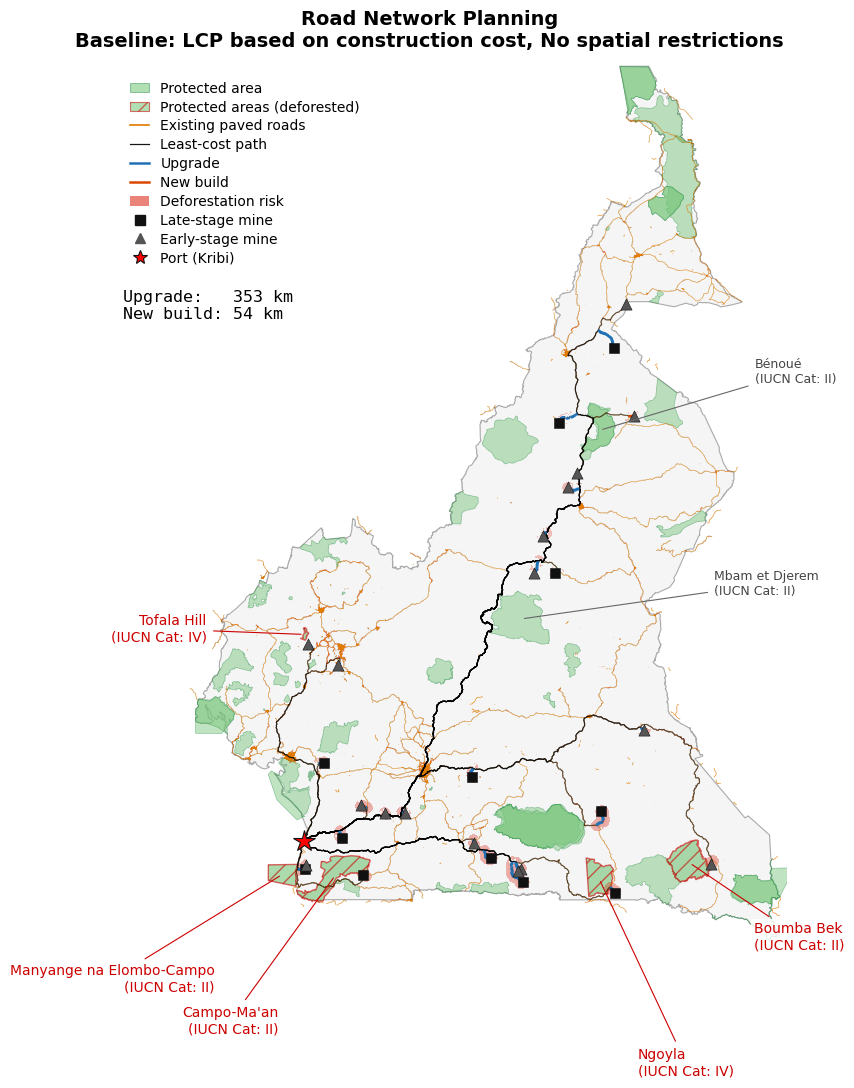

In [9]:
# ── Baseline scenario map — late+early stage, construction only, no mask ───────
import rasterio
from rasterio.enums import Resampling as RioResampling
from rasterio.features import rasterize as rio_rasterize
from rasterio.transform import from_bounds as tfm_from_bounds

PATHS_FINAL_DIR = Path('../model/results/least-cost-paths/paths_final')
ROADS_FP_MAP    = Path('../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg')
ADM0_FP         = Path('../data/input/cmr_admin_boundaries_humdata/cmr_admin0.shp')
PA_CORE_FP_MAP  = Path('../data/output/processed-protected-areas/with-buffer/cmr-protected-areas__buffer0km.gpkg')

adm0      = gpd.read_file(ADM0_FP).to_crs('EPSG:4326')
paved_rds = gpd.read_file(ROADS_FP_MAP).query("liu_surface == 'paved'").to_crs('EPSG:4326')
pa_core   = gpd.read_file(PA_CORE_FP_MAP).to_crs('EPSG:4326')
mines_all = pd.read_csv(MINES_FP)

FOCAL_MINING = 'late_and_early_stage'
stem         = f'{FOCAL_MINING}__kribi__construction_only__no_mask__ds1'
path_fp      = PATHS_FINAL_DIR / f'{stem}.gpkg'
action_fp    = RESULTS_DIR     / f'{stem}__action_roads.gpkg'
tif_fp       = RESULTS_DIR     / f'{stem}__defor_loss_pct.tif'

path_gdf   = gpd.read_file(path_fp)
action_gdf = gpd.read_file(action_fp)

bounds_arr = adm0.total_bounds
minx = bounds_arr[0] - 0.1
miny = bounds_arr[1] - 0.1
maxx = bounds_arr[2] + 0.1
maxy = bounds_arr[3] + 0.1

# Deforestation colormap: transparent at low values → red at high values
defor_cmap = mcolors.LinearSegmentedColormap.from_list(
    'defor_overlay',
    [(0,    (0.85, 0.12, 0.05, 0.0)),
     (0.05, (0.85, 0.12, 0.05, 0.25)),
     (1,    (0.85, 0.12, 0.05, 0.75))],
    N=256,
)

# Classify PAs by deforestation overlap (any pixel with defor_loss_pct > 0.5)
# Read raster at 4x downsample — same array reused for the map overlay below.
if tif_fp.exists():
    with rasterio.open(tif_fp) as src:
        ds_h = src.height // 4
        ds_w = src.width  // 4
        arr  = src.read(1, out_shape=(ds_h, ds_w),
                        resampling=RioResampling.average).astype(np.float32)
        bnds     = src.bounds
        crs_epsg = src.crs.to_epsg()
    ds_xform  = tfm_from_bounds(bnds.left, bnds.bottom, bnds.right, bnds.top, ds_w, ds_h)
    defor_bin = np.nan_to_num(arr, nan=0.0) > 0.5

    pa_reset  = pa_core.reset_index(drop=True)
    pa_reproj = pa_reset.to_crs(crs_epsg)
    pa_id_ras = rio_rasterize(
        [(geom, i + 1) for i, geom in enumerate(pa_reproj.geometry) if geom is not None],
        out_shape=(ds_h, ds_w), transform=ds_xform, fill=0, dtype=np.int32,
    )
    ids_with_defor = set(pa_id_ras[defor_bin].tolist()) - {0}
    flag = np.array([(i + 1) in ids_with_defor for i in range(len(pa_reset))])
    pa_with_defor = pa_reset[flag].copy()
    pa_no_defor   = pa_reset[~flag].copy()
else:
    arr, bnds = None, None
    pa_with_defor, pa_no_defor = gpd.GeoDataFrame(), pa_core.copy()

fig, ax = plt.subplots(figsize=(9, 11))
fig.suptitle(
    'Road Network Planning\n'
    'Baseline: LCP based on construction cost, No spatial restrictions',
    fontsize=14, fontweight='bold',
)

# Admin 0 background
adm0.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.8, zorder=0)

# PA polygons: green base; hatched red border where deforestation occurs inside
if not pa_no_defor.empty:
    pa_no_defor.plot(ax=ax, color='#74c476', alpha=0.45,
                     edgecolor='#238b45', linewidth=0.5, zorder=1)
if not pa_with_defor.empty:
    pa_with_defor.plot(ax=ax, color='#74c476', alpha=0.6,
                       edgecolor='#cc0000', hatch='//', linewidth=1, zorder=1)

# Annotate deforested PAs — labels pushed outward from country centre,
# with minimum vertical separation to avoid overlap.
if not pa_with_defor.empty:
    _name_col  = 'NAME' if 'NAME' in pa_with_defor.columns else pa_with_defor.columns[0]
    _cmr_cx, _cmr_cy = 12.5, 5.5
    _push = 1.3
    _min_sep = 0.55   # minimum degrees between label centres

    # Build (centroid_x, centroid_y, label_x, label_y, label, ha) list
    _ann_items = []
    for _, _pa_row in pa_with_defor.iterrows():
        _cx  = _pa_row.geometry.centroid.x
        _cy  = _pa_row.geometry.centroid.y
        _dx  = _cx - _cmr_cx
        _dy  = _cy - _cmr_cy
        _mag = (_dx**2 + _dy**2) ** 0.5 or 1
        _tx  = _cx + (_dx / _mag) * _push
        _ty  = _cy + (_dy / _mag) * _push
        _iucn  = _pa_row.get('IUCN_CAT', 'N/A')
        if _iucn in ('Not Applicable', 'Not Application'):
            continue
        _label = f"{_pa_row[_name_col]}\n(IUCN Cat: {_iucn})"
        _ha    = 'right' if _dx < 0 else 'left'
        _ann_items.append([_cx, _cy, _tx, _ty, _label, _ha])

    # Sort by label y, then enforce min separation (push down)
    _ann_items.sort(key=lambda r: r[3], reverse=True)
    for _i in range(1, len(_ann_items)):
        _prev_ty = _ann_items[_i - 1][3]
        if _prev_ty - _ann_items[_i][3] < _min_sep:
            _ann_items[_i][3] = _prev_ty - _min_sep

    for _cx, _cy, _tx, _ty, _label, _ha in _ann_items:
        ax.annotate(
            _label, xy=(_cx, _cy), xytext=(_tx, _ty),
            fontsize=10, color='#cc0000', ha=_ha, va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.85, edgecolor='none'),
            arrowprops=dict(arrowstyle='-', color='#cc0000',
                            lw=0.8, shrinkA=3, shrinkB=3),
            zorder=9,
        )

# Additional grey annotations for selected PAs (supporting labels)
_GREY_PA_NAMES = ['Bénoué', 'Mbam et Djerem']
_grey_pas = pa_reset[pa_reset.get('NAME_ENG', pa_reset.get('NAME', '')).isin(_GREY_PA_NAMES)]
for _, _gpa in _grey_pas.iterrows():
    _gcx = _gpa.geometry.centroid.x
    _gcy = _gpa.geometry.centroid.y
    _gdx = _gcx - _cmr_cx; _gdy = _gcy - _cmr_cy
    _gmag = (_gdx**2 + _gdy**2)**0.5 or 1
    _gtx  = _gcx + (_gdx / _gmag) * 2.5 + 1.0
    _gty  = _gcy + (_gdy / _gmag) * 2.5 - 1.5
    _glbl = _gpa.get('NAME_ENG', _gpa.get('NAME', ''))
    _giucn = _gpa.get('IUCN_CAT', 'N/A')
    _glbl = f"{_glbl}\n(IUCN Cat: {_giucn})"
    _gha  = 'right' if _gdx < 0 else 'left'
    ax.annotate(
        _glbl, xy=(_gcx, _gcy), xytext=(_gtx, _gty),
        fontsize=9, color='#444444', ha=_gha, va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  alpha=0.85, edgecolor='none'),
        arrowprops=dict(arrowstyle='-', color='#666666',
                        lw=0.8, shrinkA=3, shrinkB=3),
        zorder=8,
    )

# defor_loss_pct raster overlay — drawn after PA, under roads/paths
if arr is not None:
    arr_m = np.ma.masked_where(arr < 0.5, arr)
    ax.imshow(
        arr_m, origin='upper',
        extent=[bnds.left, bnds.right, bnds.bottom, bnds.top],
        cmap=defor_cmap, vmin=0, vmax=35,
        interpolation='bilinear', zorder=1.5, aspect='auto',
    )

# Paved roads
paved_rds.plot(ax=ax, color='#e07b00', linewidth=0.4, zorder=2)

# Full generated path (black)
path_gdf.plot(ax=ax, color='#000000', linewidth=0.8, alpha=0.55, zorder=4)

# Action roads: upgrade (blue), new build (orange)
upgrades   = action_gdf[action_gdf['action_needed'] == 'upgrade']
new_builds = action_gdf[action_gdf['action_needed'] == 'build']
if not upgrades.empty:
    upgrades.plot(ax=ax,   color='#2171b5', linewidth=2.0, zorder=5)
if not new_builds.empty:
    new_builds.plot(ax=ax, color='#d94801', linewidth=2.0, zorder=5)

# Mines: square = late-stage, triangle = early-stage
late_mines  = mines_all[mines_all['DEV_STAGE_AGGREGATED_SNL'] == 'Late-stage']
early_mines = mines_all[mines_all['DEV_STAGE_AGGREGATED_SNL'] == 'Early-stage']
ax.scatter(late_mines['LONGITUDE'],  late_mines['LATITUDE'],
           marker='s', s=55, color='#111111',
           edgecolors='#111111', linewidths=0.4, zorder=6)
ax.scatter(early_mines['LONGITUDE'], early_mines['LATITUDE'],
           marker='^', s=65, color='#555555',
           edgecolors='#111111', linewidths=0.4, zorder=6)

# Kribi port
ax.plot(9.9278, 2.9408, marker='*', color='#ff0000',
        markersize=16, zorder=7,
        markeredgecolor='#111111', markeredgewidth=0.8)

ax.set_xlim(minx, maxx)  # full country extent
ax.set_ylim(miny, maxy)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#238b45',
                   linewidth=0.6, label='Protected area'),
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#cc0000',
                   linewidth=0.8, hatch='//', label='Protected areas (deforested)'),
    mlines.Line2D([], [], color='#e07b00', linewidth=1.2,  label='Existing paved roads'),
    mlines.Line2D([], [], color='#000000', linewidth=0.9, alpha=0.9, label='Least-cost path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=1.8,  label='Upgrade'),
    mlines.Line2D([], [], color='#d94801', linewidth=1.8,  label='New build'),
    mpatches.Patch(facecolor=(0.85, 0.12, 0.05, 0.55), edgecolor='none',
                   label='Deforestation risk'),
    mlines.Line2D([], [], color='#111111', marker='s', markersize=7,
                  linestyle='None', label='Late-stage mine'),
    mlines.Line2D([], [], color='#555555', marker='^', markersize=7,
                  linestyle='None', label='Early-stage mine'),
    mlines.Line2D([], [], color='#ff0000', marker='*', markersize=10,
                  linestyle='None', markeredgecolor='#111111',
                  markeredgewidth=0.8, label='Port (Kribi)'),
]
legend = ax.legend(handles=legend_handles, loc='upper left', fontsize=10,
                   framealpha=0, handlelength=1.4,
                   borderpad=0.5, labelspacing=0.35,
                   bbox_to_anchor=(-0.12, 0.99))

# Road km text placed just below the legend box
fig.canvas.draw()
leg_bbox    = legend.get_window_extent(renderer=fig.canvas.get_renderer())
leg_bbox_ax = leg_bbox.transformed(ax.transAxes.inverted())
row_s = data[
    (data['mining']   == FOCAL_MINING) &
    (data['friction'] == 'construction_only') &
    (data['mask']     == 'no_mask')
]
if not row_s.empty:
    r = row_s.iloc[0]
    ax.text(
        leg_bbox_ax.x0, leg_bbox_ax.y0 - 0.008,
        f'Upgrade:   {r["unpaved_km"]:.0f} km\nNew build: {r["to_be_built_km"]:.0f} km',
        transform=ax.transAxes, fontsize=12, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  alpha=0.88, edgecolor='none'),
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1b_baseline_map.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 2 — Individual Policy: Protected Area Spatial Mask

Here we ask: *what happens if we impose an exclusion zone around protected areas?*

The core dilemma is a spatial rerouting trade-off:
- **Direct protection ↑**: roads are forced away from PAs → deforestation *inside* PAs falls
- **Total impact ↑ or →**: rerouted roads may traverse more (or more biodiverse) forest outside PAs
- **Cost ↑**: longer routes mean higher construction expenditure

All plots in this section use **construction_only friction** to isolate the PA-buffer effect.

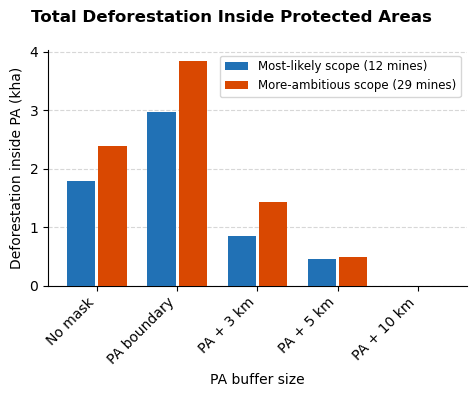

In [10]:
# ── 2a. Total deforestation inside PA by buffer size ──────────────────────────
pa_sub = data[data['friction'] == 'construction_only'].copy()

n_masks   = len(MASK_ORDER)
bar_width = 0.35
x_pos     = np.arange(n_masks)
offsets   = [-bar_width / 2 - 0.02, bar_width / 2 + 0.02]
colors    = ['#2171b5', '#d94801']
x_labels  = [MASK_LABELS[m] for m in MASK_ORDER]

fig, ax = plt.subplots(figsize=(5, 4))
fig.suptitle('Total Deforestation Inside Protected Areas',
             fontsize=12, fontweight='bold')

for mining, color, offset in zip(MINING_ORDER, colors, offsets):
    sub  = pa_sub[pa_sub['mining'] == mining].sort_values('mask_x')
    vals = [sub[sub['mask'] == m]['defor_inside_pa_kha'].values[0] for m in MASK_ORDER]
    bars = ax.bar(x_pos + offset, vals, width=bar_width, color=color,
                  label=MINING_LABELS[mining], zorder=3)
    # for bar, v in zip(bars, vals):
    #     ax.text(bar.get_x() + bar.get_width() / 2,
    #             v + ax.get_ylim()[1] * 0.01,
    #             f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=10, rotation=45, ha='right')
ax.set_xlabel('PA buffer size', fontsize=10)
ax.set_ylabel('Deforestation inside PA (kha)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=8.5, frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2a_pa_defor_inside.png', dpi=150, bbox_inches='tight')
plt.show()


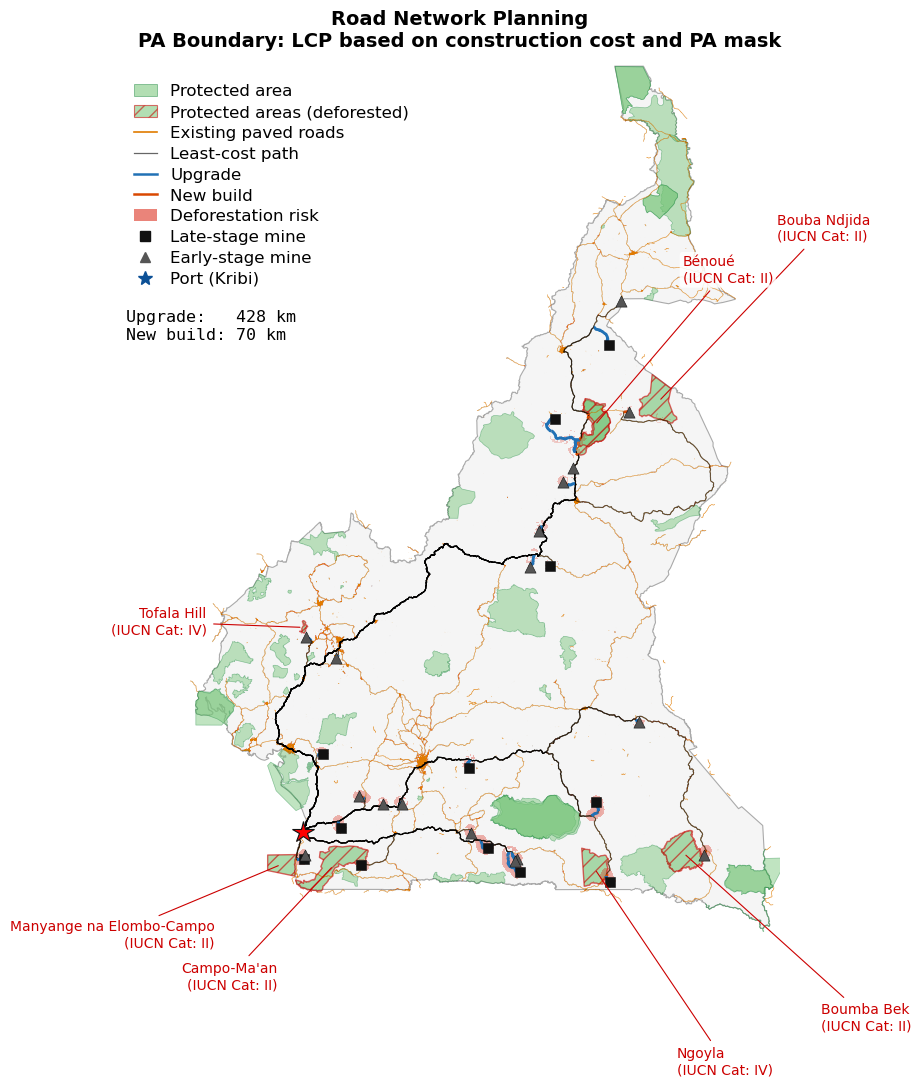

In [11]:
# ── Section 2 map — late+early stage, construction only, PA mask ───────────────
# rio_rasterize / tfm_from_bounds imported in s1-map cell above

FOCAL_MINING_PA = 'late_and_early_stage'
stem_pa         = f'{FOCAL_MINING_PA}__kribi__construction_only__protected_areas__ds1'
path_fp_pa      = PATHS_FINAL_DIR / f'{stem_pa}.gpkg'
action_fp_pa    = RESULTS_DIR     / f'{stem_pa}__action_roads.gpkg'
tif_fp_pa       = RESULTS_DIR     / f'{stem_pa}__defor_loss_pct.tif'

path_gdf_pa   = gpd.read_file(path_fp_pa)
action_gdf_pa = gpd.read_file(action_fp_pa)

# Classify PAs by deforestation overlap
if tif_fp_pa.exists():
    with rasterio.open(tif_fp_pa) as src:
        ds_h_pa = src.height // 4
        ds_w_pa = src.width  // 4
        arr_pa  = src.read(1, out_shape=(ds_h_pa, ds_w_pa),
                           resampling=RioResampling.average).astype(np.float32)
        bnds_pa     = src.bounds
        crs_epsg_pa = src.crs.to_epsg()
    ds_xform_pa  = tfm_from_bounds(bnds_pa.left, bnds_pa.bottom,
                                    bnds_pa.right, bnds_pa.top, ds_w_pa, ds_h_pa)
    defor_bin_pa = np.nan_to_num(arr_pa, nan=0.0) > 0.5

    pa_reset_pa  = pa_core.reset_index(drop=True)
    pa_reproj_pa = pa_reset_pa.to_crs(crs_epsg_pa)
    pa_id_ras_pa = rio_rasterize(
        [(geom, i + 1) for i, geom in enumerate(pa_reproj_pa.geometry) if geom is not None],
        out_shape=(ds_h_pa, ds_w_pa), transform=ds_xform_pa, fill=0, dtype=np.int32,
    )
    ids_defor_pa = set(pa_id_ras_pa[defor_bin_pa].tolist()) - {0}
    flag_pa = np.array([(i + 1) in ids_defor_pa for i in range(len(pa_reset_pa))])
    pa_with_defor_pa = pa_reset_pa[flag_pa].copy()
    pa_no_defor_pa   = pa_reset_pa[~flag_pa].copy()
else:
    arr_pa, bnds_pa = None, None
    pa_with_defor_pa, pa_no_defor_pa = gpd.GeoDataFrame(), pa_core.copy()

fig, ax = plt.subplots(figsize=(9, 11))
fig.suptitle(
    'Road Network Planning\n'
    'PA Boundary: LCP based on construction cost and PA mask',
    fontsize=14, fontweight='bold',
)

# Admin 0 background
adm0.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.8, zorder=0)

# PA polygons
if not pa_no_defor_pa.empty:
    pa_no_defor_pa.plot(ax=ax, color='#74c476', alpha=0.45,
                        edgecolor='#238b45', linewidth=0.5, zorder=1)
if not pa_with_defor_pa.empty:
    pa_with_defor_pa.plot(ax=ax, color='#74c476', alpha=0.6,
                          edgecolor='#cc0000', hatch='//', linewidth=1, zorder=1)

# Annotate deforested PAs — outward push with min separation
if not pa_with_defor_pa.empty:
    _name_col_pa = 'NAME' if 'NAME' in pa_with_defor_pa.columns else pa_with_defor_pa.columns[0]
    _cmr_cx, _cmr_cy = 12.5, 5.5
    _push_left  = 1.3   # left-side PAs (western Cameroon)
    _push_right = 2.8   # right-side PAs — push further to clear the map body
    _min_sep_pa = 0.55
    _ann_pa = []
    for _, _r in pa_with_defor_pa.iterrows():
        _cx = _r.geometry.centroid.x
        _cy = _r.geometry.centroid.y
        _dx = _cx - _cmr_cx; _dy = _cy - _cmr_cy
        _mag = (_dx**2 + _dy**2)**0.5 or 1
        _push_pa = _push_right if _dx >= 0 else _push_left
        _tx = _cx + (_dx/_mag)*_push_pa
        _ty = _cy + (_dy/_mag)*_push_pa
        _iucn = _r.get('IUCN_CAT', 'N/A')
        if _iucn in ('Not Applicable', 'Not Application'):
            continue
        _lbl = f"{_r[_name_col_pa]}\n(IUCN Cat: {_iucn})"
        _ha  = 'right' if _dx < 0 else 'left'
        _ann_pa.append([_cx, _cy, _tx, _ty, _lbl, _ha])
    _ann_pa.sort(key=lambda r: r[3], reverse=True)
    for _i in range(1, len(_ann_pa)):
        if _ann_pa[_i-1][3] - _ann_pa[_i][3] < _min_sep_pa:
            _ann_pa[_i][3] = _ann_pa[_i-1][3] - _min_sep_pa
    for _cx, _cy, _tx, _ty, _lbl, _ha in _ann_pa:
        ax.annotate(
            _lbl, xy=(_cx, _cy), xytext=(_tx, _ty),
            fontsize=10, color='#cc0000', ha=_ha, va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.85, edgecolor='none'),
            arrowprops=dict(arrowstyle='-', color='#cc0000',
                            lw=0.8, shrinkA=3, shrinkB=3),
            zorder=9,
        )

# defor_loss_pct raster overlay — drawn after PA, under roads/paths
if arr_pa is not None:
    arr_m_pa = np.ma.masked_where(arr_pa < 0.5, arr_pa)
    ax.imshow(
        arr_m_pa, origin='upper',
        extent=[bnds_pa.left, bnds_pa.right, bnds_pa.bottom, bnds_pa.top],
        cmap=defor_cmap, vmin=0, vmax=35,
        interpolation='bilinear', zorder=1.5, aspect='auto',
    )

# Paved roads
paved_rds.plot(ax=ax, color='#e07b00', linewidth=0.4, zorder=2)

# Full generated path (black)
path_gdf_pa.plot(ax=ax, color='#000000', linewidth=0.8, alpha=0.55, zorder=4)

# Action roads: upgrade (blue), new build (orange)
upgrades_pa   = action_gdf_pa[action_gdf_pa['action_needed'] == 'upgrade']
new_builds_pa = action_gdf_pa[action_gdf_pa['action_needed'] == 'build']
if not upgrades_pa.empty:
    upgrades_pa.plot(ax=ax,   color='#2171b5', linewidth=2.0, zorder=5)
if not new_builds_pa.empty:
    new_builds_pa.plot(ax=ax, color='#d94801', linewidth=2.0, zorder=5)

# Mines
ax.scatter(late_mines['LONGITUDE'],  late_mines['LATITUDE'],
           marker='s', s=55, color='#111111',
           edgecolors='#111111', linewidths=0.4, zorder=6)
ax.scatter(early_mines['LONGITUDE'], early_mines['LATITUDE'],
           marker='^', s=65, color='#555555',
           edgecolors='#111111', linewidths=0.4, zorder=6)

# Kribi port
ax.plot(9.9278, 2.9408, marker='*', color="#ff0000",
        markersize=16, zorder=7,
        markeredgecolor='#111111', markeredgewidth=0.8)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#238b45',
                   linewidth=0.6, label='Protected area'),
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#cc0000',
                   linewidth=0.8, hatch='//', label='Protected areas (deforested)'),
    mlines.Line2D([], [], color='#e07b00', linewidth=1.2,  label='Existing paved roads'),
    mlines.Line2D([], [], color='#000000', linewidth=0.9, alpha=0.6, label='Least-cost path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=1.8,  label='Upgrade'),
    mlines.Line2D([], [], color='#d94801', linewidth=1.8,  label='New build'),
    mpatches.Patch(facecolor=(0.85, 0.12, 0.05, 0.55), edgecolor='none',
                   label='Deforestation risk'),
    mlines.Line2D([], [], color='#111111', marker='s', markersize=7,
                  linestyle='None', label='Late-stage mine'),
    mlines.Line2D([], [], color='#555555', marker='^', markersize=7,
                  linestyle='None', label='Early-stage mine'),
    mlines.Line2D([], [], color='#0c5096', marker='*', markersize=10,
                  linestyle='None', label='Port (Kribi)'),
]
legend = ax.legend(handles=legend_handles, loc='upper left', fontsize=12,
                   framealpha=0, handlelength=1.4, 
                   borderpad=0.5, labelspacing=0.35,
                   bbox_to_anchor=(-0.12, 0.99))

fig.canvas.draw()
leg_bbox    = legend.get_window_extent(renderer=fig.canvas.get_renderer())
leg_bbox_ax = leg_bbox.transformed(ax.transAxes.inverted())
row_pa = data[
    (data['mining']   == FOCAL_MINING_PA) &
    (data['friction'] == 'construction_only') &
    (data['mask']     == 'protected_areas')
]
if not row_pa.empty:
    r = row_pa.iloc[0]
    ax.text(
        leg_bbox_ax.x0, leg_bbox_ax.y0 - 0.008,
        f'Upgrade:   {r["unpaved_km"]:.0f} km\nNew build: {r["to_be_built_km"]:.0f} km',
        transform=ax.transAxes, fontsize=12, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  alpha=0.88, edgecolor='none'),
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2c_pa_map.png', dpi=150, bbox_inches='tight')
plt.show()


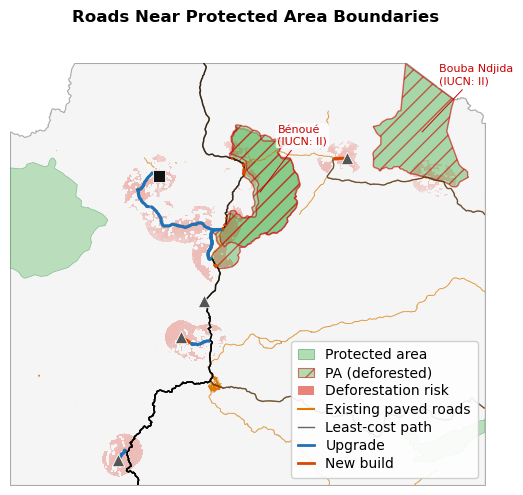

In [12]:
# ── PA perimeter road effect — single panel (PA boundary mask only) ────────

ZOOM_X0, ZOOM_X1 = 12.5, 15   # longitude range
ZOOM_Y0, ZOOM_Y1 = 6.8,  9   # latitude range

_stem_pa_zoom = f'{FOCAL_MINING_PA}__kribi__construction_only__protected_areas__ds1'
_tif_z = RESULTS_DIR / f'{_stem_pa_zoom}__defor_loss_pct.tif'
_act_z = RESULTS_DIR / f'{_stem_pa_zoom}__action_roads.gpkg'
_pth_z = PATHS_FINAL_DIR / f'{_stem_pa_zoom}.gpkg'

if _tif_z.exists():
    with rasterio.open(_tif_z) as _s:
        _dh = _s.height // 2; _dw = _s.width // 2
        _arr_z = _s.read(1, out_shape=(_dh, _dw),
                         resampling=RioResampling.average).astype(np.float32)
        _bnds_z = _s.bounds
else:
    _arr_z, _bnds_z = None, None
_act_gdf_z  = gpd.read_file(_act_z)
_path_gdf_z = gpd.read_file(_pth_z)

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle(
    'Roads Near Protected Area Boundaries\n',
    fontsize=12, fontweight='bold',
)

# Clip background layers
_adm_c = adm0.clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)
_pa_nd = pa_no_defor_pa.clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)
_pa_wd = pa_with_defor_pa.clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)
_rds_c = paved_rds.clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)

if not _adm_c.empty:
    _adm_c.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa',
                linewidth=0.8, zorder=0)
if not _pa_nd.empty:
    _pa_nd.plot(ax=ax, color='#74c476', alpha=0.45,
                edgecolor='#238b45', linewidth=0.5, zorder=1)
if not _pa_wd.empty:
    _pa_wd.plot(ax=ax, color='#74c476', alpha=0.6,
                edgecolor='#cc0000', hatch='//', linewidth=1, zorder=1)

if _arr_z is not None:
    _arr_m = np.ma.masked_where(_arr_z < 0.05, _arr_z)
    ax.imshow(
        _arr_m, origin='upper',
        extent=[_bnds_z.left, _bnds_z.right, _bnds_z.bottom, _bnds_z.top],
        cmap=defor_cmap, vmin=0, vmax=35,
        interpolation='bilinear', zorder=1.5, aspect='auto',
    )

if not _rds_c.empty:
    _rds_c.plot(ax=ax, color='#e07b00', linewidth=0.6, zorder=2)

_path_gdf_z.clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)\
           .plot(ax=ax, color='#000000', linewidth=1.0, alpha=0.5, zorder=4)

_upg_z = _act_gdf_z[_act_gdf_z['action_needed'] == 'upgrade']\
             .clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)
_bld_z = _act_gdf_z[_act_gdf_z['action_needed'] == 'build']\
             .clip_by_rect(ZOOM_X0, ZOOM_Y0, ZOOM_X1, ZOOM_Y1)
if not _upg_z.empty:
    _upg_z.plot(ax=ax, color='#2171b5', linewidth=2.2, zorder=5)
if not _bld_z.empty:
    _bld_z.plot(ax=ax, color='#d94801', linewidth=2.2, zorder=5)

for _mdf, _mk, _mc, _ms in [
    (late_mines,  's', '#111111', 70),
    (early_mines, '^', '#555555', 80),
]:
    _in_z = _mdf[
        _mdf['LONGITUDE'].between(ZOOM_X0, ZOOM_X1) &
        _mdf['LATITUDE'].between(ZOOM_Y0, ZOOM_Y1)
    ]
    if not _in_z.empty:
        ax.scatter(_in_z['LONGITUDE'], _in_z['LATITUDE'],
                   marker=_mk, s=_ms, color=_mc,
                   edgecolors='#ffffff', linewidths=0.6, zorder=6)

# PA name annotations
if not pa_with_defor_pa.empty:
    _nm_col = 'NAME' if 'NAME' in pa_with_defor_pa.columns else pa_with_defor_pa.columns[0]
    for _, _r in pa_with_defor_pa.iterrows():
        _cx = _r.geometry.centroid.x
        _cy = _r.geometry.centroid.y
        if not (ZOOM_X0 < _cx < ZOOM_X1 and ZOOM_Y0 < _cy < ZOOM_Y1):
            continue
        _iucn = _r.get('IUCN_CAT', 'N/A')
        if _iucn in ('Not Applicable', 'Not Application'):
            continue
        ax.annotate(
            f"{_r[_nm_col]}\n(IUCN: {_iucn})",
            xy=(_cx, _cy), xytext=(_cx + 0.1, _cy + 0.25),
            fontsize=8, color='#cc0000', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      alpha=0.8, edgecolor='none'),
            arrowprops=dict(arrowstyle='-', color='#cc0000',
                            lw=0.7, shrinkA=2, shrinkB=2),
            zorder=9,
        )

ax.set_xlim(ZOOM_X0, ZOOM_X1)
ax.set_ylim(ZOOM_Y0, ZOOM_Y1)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

_leg_h = [
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#238b45',
                   linewidth=0.6, label='Protected area'),
    mpatches.Patch(facecolor='#74c476', alpha=0.55, edgecolor='#cc0000',
                   linewidth=0.8, hatch='//', label='PA (deforested)'),
    mpatches.Patch(facecolor=(0.85, 0.12, 0.05, 0.55), edgecolor='none',
                   label='Deforestation risk'),
    mlines.Line2D([], [], color='#e07b00', linewidth=1.5,
                  label='Existing paved roads'),
    mlines.Line2D([], [], color='#000000', linewidth=1.0, alpha=0.6,
                  label='Least-cost path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=2.0, label='Upgrade'),
    mlines.Line2D([], [], color='#d94801', linewidth=2.0, label='New build'),
]
ax.legend(handles=_leg_h, loc='lower right', fontsize=10,
          framealpha=0.9, handlelength=1.2, borderpad=0.5,
          labelspacing=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_pa_edge_effect_zoom.png', dpi=150, bbox_inches='tight')
plt.show()


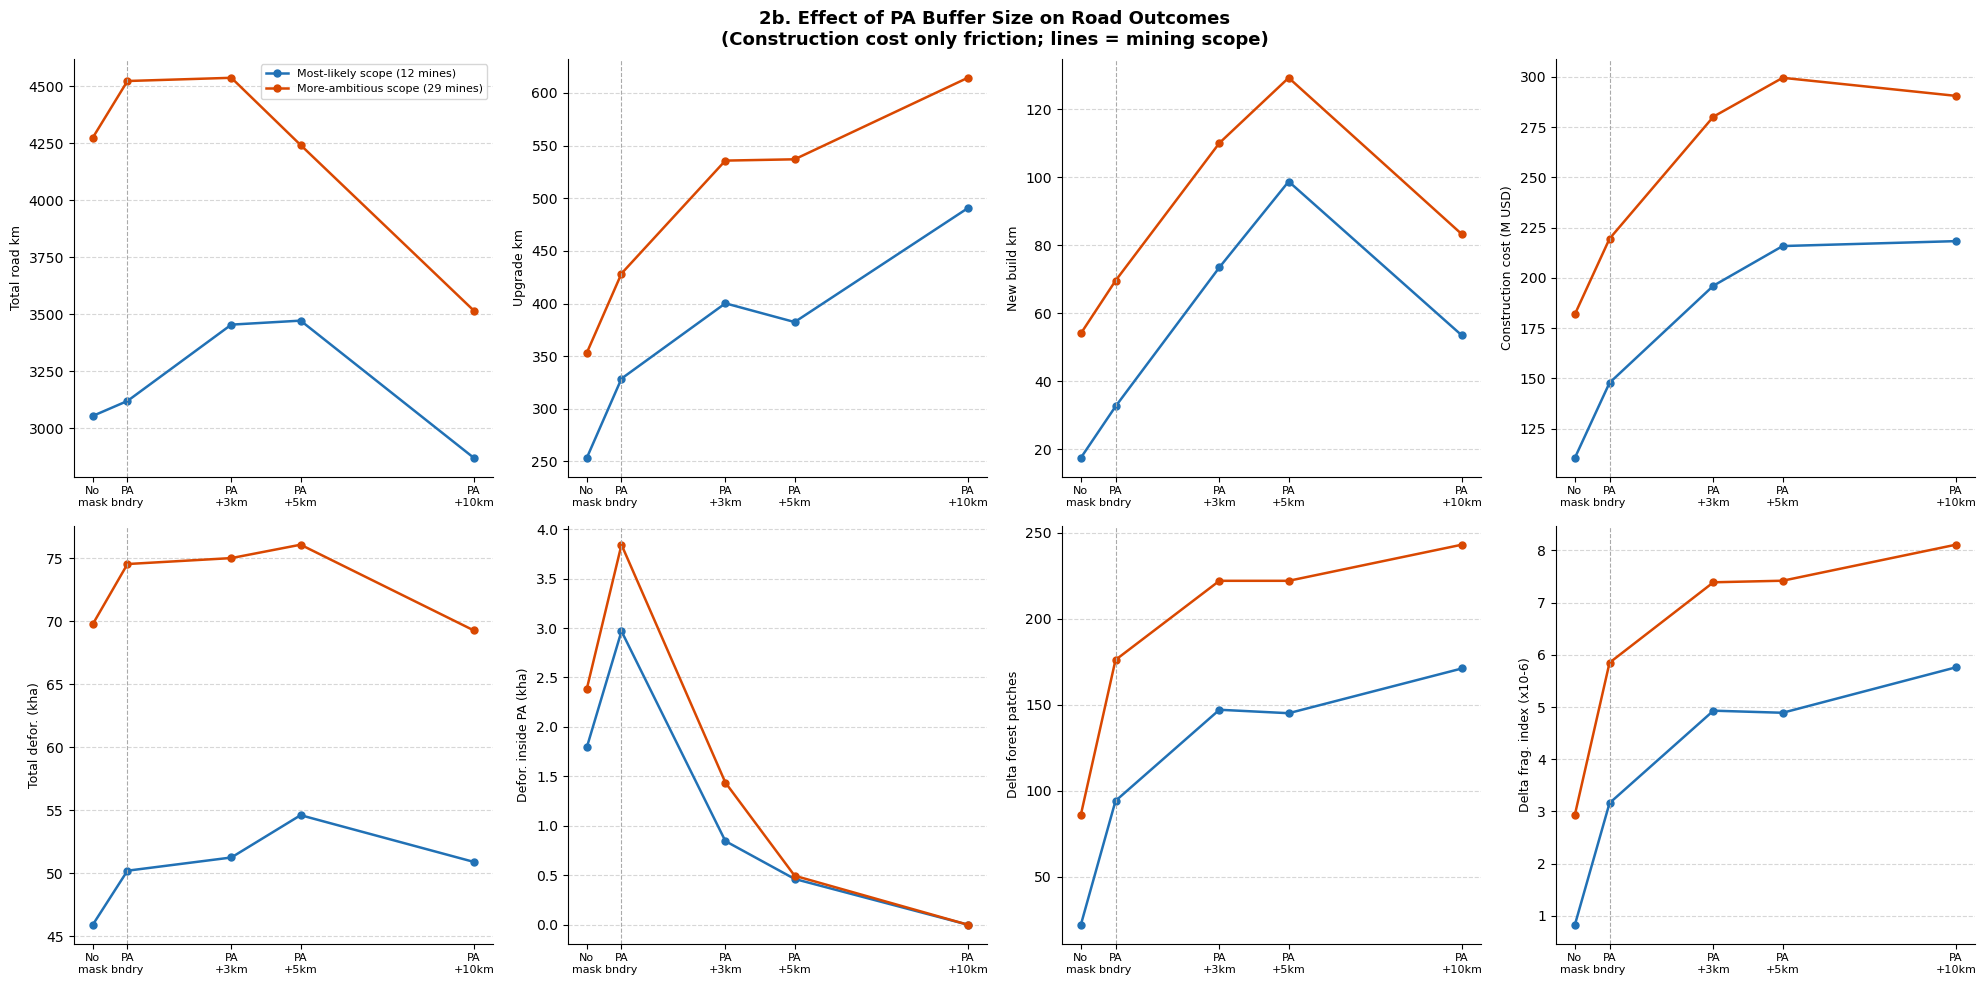

In [13]:
# ── Line plots: PA buffer effect on all key metrics ──────────────────────────
# x-axis = PA buffer size (km), using MASK_BUFFER_KM positions
# Focus: construction_only friction

PA_METRICS = [
    ('total_km',              'Total road km'),
    ('unpaved_km',            'Upgrade km'),
    ('to_be_built_km',        'New build km'),
    ('construction_cost_musd','Construction cost (M USD)'),
    ('defor_action_kha',      'Total defor. (kha)'),
    ('defor_inside_pa_kha',   'Defor. inside PA (kha)'),
    ('frag_delta_n_patches',  'Delta forest patches'),
    ('delta_fi_e6',           'Delta frag. index (x10-6)'),
]

x_ticks  = [-1, 0, 3, 5, 10]
x_labels = ['No\nmask', 'PA\nbndry', 'PA\n+3km', 'PA\n+5km', 'PA\n+10km']

n_rows = math.ceil(len(PA_METRICS) / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))
fig.suptitle('2b. Effect of PA Buffer Size on Road Outcomes\n(Construction cost only friction; lines = mining scope)',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, (col, ylabel) in enumerate(PA_METRICS):
    ax = axes_flat[i]
    for mining, color in zip(MINING_ORDER, ['#2171b5', '#d94801']):
        sub = pa_sub[pa_sub['mining'] == mining].sort_values('mask_x')
        ax.plot(sub['mask_x'], sub[col], color=color, marker='o', markersize=5,
                linewidth=1.8, label=MINING_LABELS[mining])
    ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        ax.legend(fontsize=8, frameon=True)

for j in range(len(PA_METRICS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2b_pa_buffer_lines.png', dpi=150, bbox_inches='tight')
plt.show()

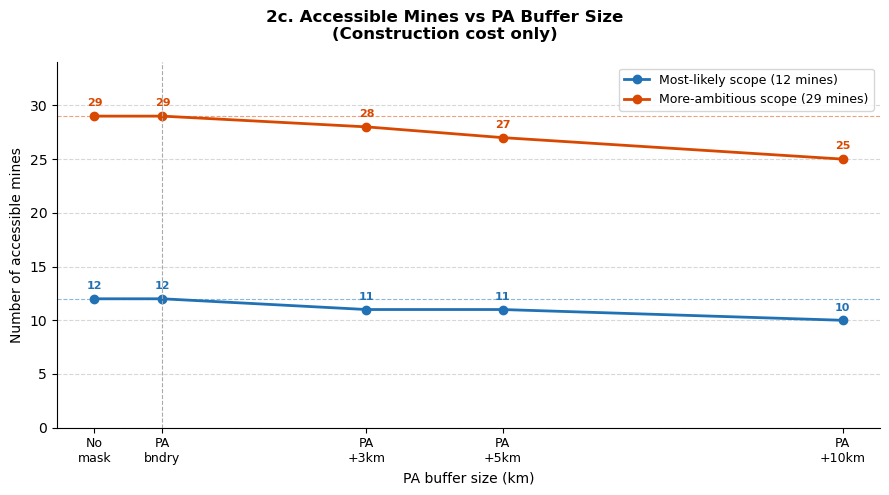

In [14]:
# ── Mine accessibility by buffer size ─────────────────────────────────────────
# How many mines lose access as the PA buffer grows?

acc = (
    pa_sub.groupby(['mining', 'mask'], observed=True)['n_mines_accessible']
    .mean().reset_index()
)
acc['mask_x'] = acc['mask'].map(MASK_BUFFER_KM)
acc = acc.sort_values(['mining', 'mask_x'])

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('2c. Accessible Mines vs PA Buffer Size\n(Construction cost only)',
             fontsize=12, fontweight='bold')

totals = {'late_stage': 12, 'late_and_early_stage': 29}
for mining, color in zip(MINING_ORDER, ['#2171b5', '#d94801']):
    sub_a = acc[acc['mining'] == mining].sort_values('mask_x')
    ax.plot(sub_a['mask_x'], sub_a['n_mines_accessible'],
            color=color, marker='o', markersize=6, linewidth=2.0,
            label=MINING_LABELS[mining])
    ax.axhline(totals[mining], color=color, linewidth=0.8,
               linestyle='--', alpha=0.5)
    for _, row in sub_a.iterrows():
        n = int(row['n_mines_accessible'])
        ax.annotate(str(n), (row['mask_x'], n),
                    textcoords='offset points', xytext=(0, 7),
                    ha='center', fontsize=8, color=color, fontweight='bold')

ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_xlabel('PA buffer size (km)', fontsize=10)
ax.set_ylabel('Number of accessible mines', fontsize=10)
ax.set_ylim(0, 34)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2c_accessibility_by_buffer.png', dpi=150, bbox_inches='tight')
plt.show()

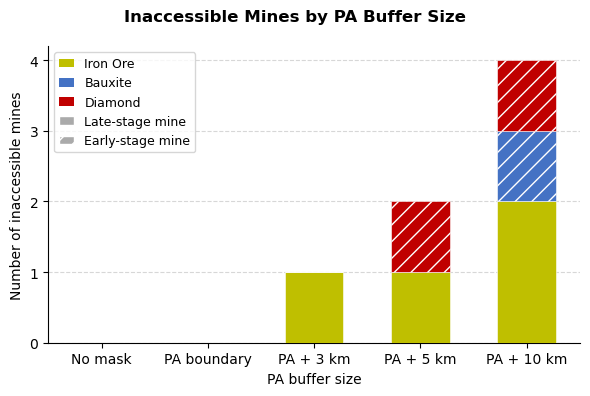

In [15]:
# ── 2d. Inaccessible mines by buffer size — stacked by commodity ───────────────
# One bar per buffer size.  Within each commodity segment:
#   solid fill  = late-stage mine inaccessible
#   hatch //    = early-stage mine inaccessible

mines_ref2 = pd.read_csv(MINES_FP)
mine_comm2 = mines_ref2.set_index('ID')['PRIMARY_COMMODITY'].to_dict()
mine_stage = mines_ref2.set_index('ID')['DEV_STAGE_AGGREGATED_SNL'].to_dict()

# Reference set: all in-scope mines from late_and_early_stage no_mask scenario
base_fp = PATHS_FINAL_DIR / 'late_and_early_stage__kribi__construction_only__no_mask__ds1.gpkg'
base_ids = set(gpd.read_file(base_fp)['mine_id']) if base_fp.exists() else set()

records = []
for mask in MASK_ORDER:
    stem    = f'late_and_early_stage__kribi__construction_only__{mask}__ds1'
    gpkg_fp = PATHS_FINAL_DIR / f'{stem}.gpkg'
    if not gpkg_fp.exists():
        continue
    present = set(gpd.read_file(gpkg_fp)['mine_id'])
    for mid in base_ids - present:
        stage = mine_stage.get(mid, '')
        records.append({
            'mask':      mask,
            'commodity': mine_comm2.get(mid, 'Unknown'),
            'stage':     'early' if 'Early' in stage else 'late',
        })

inac_df = pd.DataFrame(records) if records else pd.DataFrame(
    columns=['mask', 'commodity', 'stage'])

# ── Single stacked bar per buffer ─────────────────────────────────────────────
n_masks  = len(MASK_ORDER)
bar_width = 0.55
x_pos    = np.arange(n_masks)

fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle('Inaccessible Mines by PA Buffer Size',
             fontsize=12, fontweight='bold')

legend_handles = []
bottoms = np.zeros(n_masks)
for comm in COMMODITY_ORDER:
    color    = COMMODITY_COLORS.get(comm, '#aaaaaa')
    added_to_legend = False
    for stage, hatch in [('late', ''), ('early', '//')]:
        vals = []
        for mask in MASK_ORDER:
            sub = inac_df[(inac_df['mask'] == mask) &
                          (inac_df['commodity'] == comm) &
                          (inac_df['stage'] == stage)]
            vals.append(len(sub))
        vals = np.array(vals, dtype=float)
        if vals.sum() == 0:
            bottoms += vals
            continue
        ax.bar(x_pos, vals, width=bar_width, bottom=bottoms,
               color=color, hatch=hatch,
               edgecolor='white', linewidth=0.4, zorder=3)
        bottoms += vals
        if not added_to_legend:
            legend_handles.append(mpatches.Patch(facecolor=color, label=comm.title()))
            added_to_legend = True

stage_handles = [
    mpatches.Patch(facecolor='#aaaaaa', hatch='',   edgecolor='white', label='Late-stage mine'),
    mpatches.Patch(facecolor='#aaaaaa', hatch='//', edgecolor='white', label='Early-stage mine'),
]

ax.set_xticks(x_pos)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=10)
ax.set_xlabel('PA buffer size', fontsize=10)
ax.set_ylabel('Number of inaccessible mines', fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

ax.legend(handles=legend_handles + stage_handles, fontsize=9, frameon=True,
          loc='upper left', ncol=1, handlelength=1.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2d_inaccessible_by_commodity.png', dpi=150, bbox_inches='tight')
plt.show()


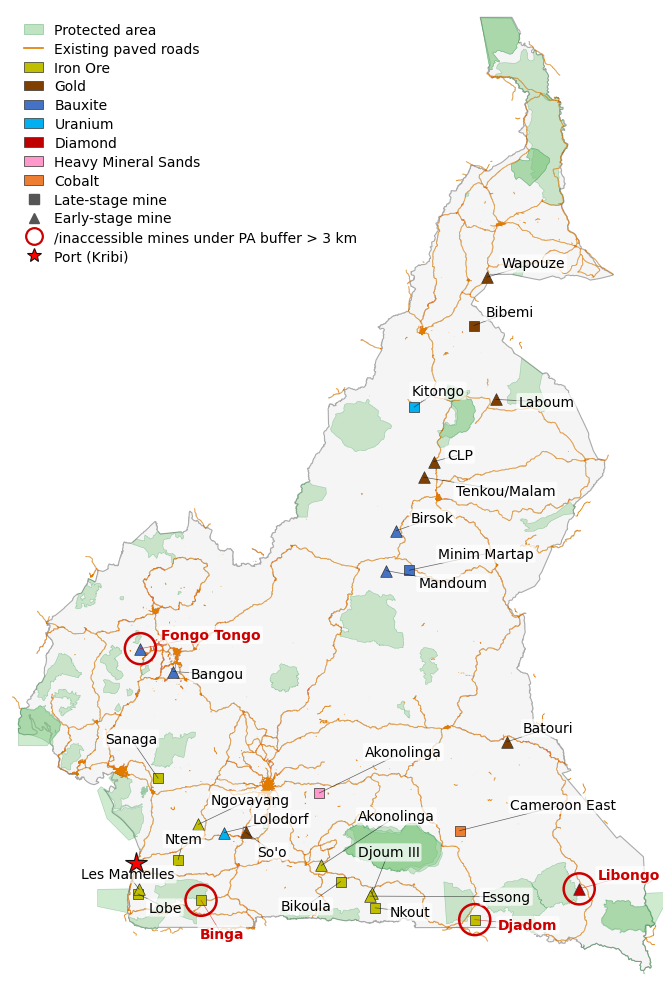

Inaccessible under protected_areas_buf10km: ['cmr_008', 'cmr_011', 'cmr_021', 'cmr_023']


In [16]:
# ── Mine access map — PA+10km scenario, circled mines lose access ─────────────
# Mines colored by commodity; shape = stage; red circle = inaccessible under PA+10km.

FOCAL_MASK = 'protected_areas_buf10km'

ref_fp   = PATHS_FINAL_DIR / 'late_and_early_stage__kribi__construction_only__no_mask__ds1.gpkg'
con_fp   = PATHS_FINAL_DIR / f'late_and_early_stage__kribi__construction_only__{FOCAL_MASK}__ds1.gpkg'
ref_ids  = set(gpd.read_file(ref_fp)['mine_id'])  if ref_fp.exists() else set()
con_ids  = set(gpd.read_file(con_fp)['mine_id'])  if con_fp.exists() else set()
inac_ids = ref_ids - con_ids

mines_all2 = pd.read_csv(MINES_FP)
inac_m     = mines_all2[mines_all2['ID'].isin(inac_ids)]

fig, ax = plt.subplots(figsize=(8, 10))
# fig.suptitle(
#     'Inacessible Mines under PA Buffer > 3 km\n',
#     fontsize=14, fontweight='bold',
# )

adm0.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.8, zorder=0)
pa_core.plot(ax=ax, color='#74c476', alpha=0.35, edgecolor='#238b45',
             linewidth=0.4, zorder=1)
paved_rds.plot(ax=ax, color='#e07b00', linewidth=0.6, zorder=2)

# Mines colored by commodity, shaped by stage
for stage, marker, sz in [('Late-stage', 's', 60), ('Early-stage', '^', 70)]:
    stage_m = mines_all2[mines_all2['DEV_STAGE_AGGREGATED_SNL'] == stage]
    for comm in COMMODITY_ORDER:
        sub = stage_m[stage_m['PRIMARY_COMMODITY'] == comm]
        if sub.empty:
            continue
        color = COMMODITY_COLORS.get(comm, '#aaaaaa')
        ax.scatter(sub['LONGITUDE'], sub['LATITUDE'],
                   marker=marker, s=sz, color=color,
                   edgecolors='#333333', linewidths=0.5, zorder=4)

# Inaccessible mines — red hollow circle overlay
ax.scatter(inac_m['LONGITUDE'], inac_m['LATITUDE'],
           marker='o', s=500, facecolors='none',
           edgecolors='#cc0000', linewidths=1.8, zorder=5)

# Labels for all in-scope mines (adjustText to avoid overlap)
from adjustText import adjust_text
_label_texts, _label_pts = [], []
for _, row in mines_all2[mines_all2['ID'].isin(ref_ids)].iterrows():
    _is_inac = row['ID'] in inac_ids
    _col = '#cc0000' if _is_inac else "#000000"
    _fw  = 'bold' if _is_inac else 'normal'
    _t = ax.text(
        row['LONGITUDE'], row['LATITUDE'], row['PROP_NAME'],
        fontsize=10, color=_col, fontweight=_fw,
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  alpha=0.70, edgecolor='none'),
        zorder=7,
    )
    _label_texts.append(_t)
    _label_pts.append((row['LONGITUDE'], row['LATITUDE']))
adjust_text(
    _label_texts, ax=ax,
    expand=(1.2, 1.4),
    force_text=(0.4, 0.6),
    force_points=(0.2, 0.4),
    autoalign=True,
)
for _t, (_px, _py) in zip(_label_texts, _label_pts):
    _tx, _ty = _t.get_position()
    if abs(_tx - _px) > 0.05 or abs(_ty - _py) > 0.05:
        ax.plot([_px, _tx], [_py, _ty],
                color=_t.get_color(), linewidth=0.5, alpha=0.6, zorder=6)

# Kribi port
ax.plot(9.9278, 2.9408, marker='*', color='#ff0000',
        markersize=16, zorder=7,
        markeredgecolor='#111111', markeredgewidth=0.8)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend: PA + roads, then commodity colors, then stage shapes, then inaccessible
base_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.45, edgecolor='#238b45',
                   linewidth=0.5, label='Protected area'),
    mlines.Line2D([], [], color='#e07b00', linewidth=1.2, label='Existing paved roads'),
]
comm_handles = [
    mpatches.Patch(facecolor=COMMODITY_COLORS.get(c, '#aaaaaa'),
                   edgecolor='#333333', linewidth=0.5, label=c.title())
    for c in COMMODITY_ORDER if not mines_all2[mines_all2['PRIMARY_COMMODITY'] == c].empty
]
stage_handles = [
    mlines.Line2D([], [], color='#555555', marker='s', markersize=7,
                  linestyle='None', label='Late-stage mine'),
    mlines.Line2D([], [], color='#555555', marker='^', markersize=7,
                  linestyle='None', label='Early-stage mine'),
    mlines.Line2D([], [], color='#cc0000', marker='o', markersize=12,
                  markerfacecolor='none', markeredgewidth=1.6,
                  linestyle='None', label='/inaccessible mines under PA buffer > 3 km'),
    mlines.Line2D([], [], color='#ff0000', marker='*', markersize=10,
                  linestyle='None', markeredgecolor='#111111',
                  markeredgewidth=0.8, label='Port (Kribi)'),
]
ax.legend(handles=base_handles + comm_handles + stage_handles,
          loc='upper left', fontsize=10,
          framealpha=0.0, handlelength=1.4, borderpad=0.5, labelspacing=0.35)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2f_mine_access_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Inaccessible under {FOCAL_MASK}: {sorted(inac_ids)}')


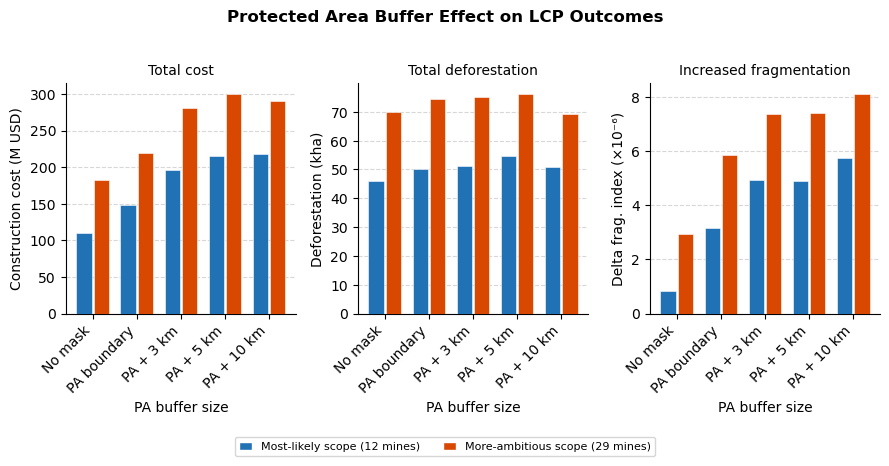

In [17]:
# ── 2e. PA buffer effect — cost, deforestation, fragmentation ─────────────────
# Construction cost only friction; 2 bars per buffer (late / late+early).

co_sub    = data[data['friction'] == 'construction_only'].copy()
n_masks   = len(MASK_ORDER)
bar_width = 0.35
x_pos     = np.arange(n_masks)
offsets   = [-bar_width / 2 - 0.02, bar_width / 2 + 0.02]
colors    = ['#2171b5', '#d94801']
hatch_map = {MINING_ORDER[0]: '', MINING_ORDER[1]: ''}

METRICS = [
    ('construction_cost_musd', 'Construction cost (M USD)', 'Total cost'),
    ('defor_action_kha',       'Deforestation (kha)',       'Total deforestation'),
    ('delta_fi_e6',            'Delta frag. index (\u00d710\u207b\u2076)',
                                'Increased fragmentation'),
]

fig, axes = plt.subplots(1, 3, figsize=(9, 4))
fig.suptitle('Protected Area Buffer Effect on LCP Outcomes\n',
             fontsize=12, fontweight='bold')

for ax, (col, ylabel, title) in zip(axes, METRICS):
    for mining, color, offset in zip(MINING_ORDER, colors, offsets):
        sub  = co_sub[co_sub['mining'] == mining].sort_values('mask_x')
        vals = np.array([sub[sub['mask'] == m][col].values[0] for m in MASK_ORDER])
        hatch = hatch_map[mining]
        bars = ax.bar(x_pos + offset, vals, width=bar_width,
                      color=color, hatch=hatch,
                      edgecolor='white', linewidth=0.4, zorder=3,
                      label=MINING_LABELS[mining])

    ax.set_title(title, fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=10,
                         rotation=45, ha='right')
    ax.set_xlabel('PA buffer size', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

scope_handles = [
    mpatches.Patch(facecolor='#2171b5', hatch='',   edgecolor='white',
                   label=f'{MINING_LABELS[MINING_ORDER[0]]}'),
    mpatches.Patch(facecolor='#d94801', hatch='',   edgecolor='white',
                   label=f'{MINING_LABELS[MINING_ORDER[1]]}'),
]
fig.legend(handles=scope_handles, fontsize=8, frameon=True,
           loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, handlelength=1.2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig(FIGURES_DIR / 'fig2e_pa_buffer_summary.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3 — Individual Policy: Carbon Shadow Pricing

Here we ask: *what happens if the social cost of carbon is internalised into routing decisions?*

Carbon pricing works differently from spatial masks — it does not hard-block any corridor, but raises the effective cost of routes that cross high-biomass forest, nudging least-cost paths toward already-degraded or lower-carbon corridors.

All plots in this section use **no_mask** to isolate the pricing effect from spatial restrictions.

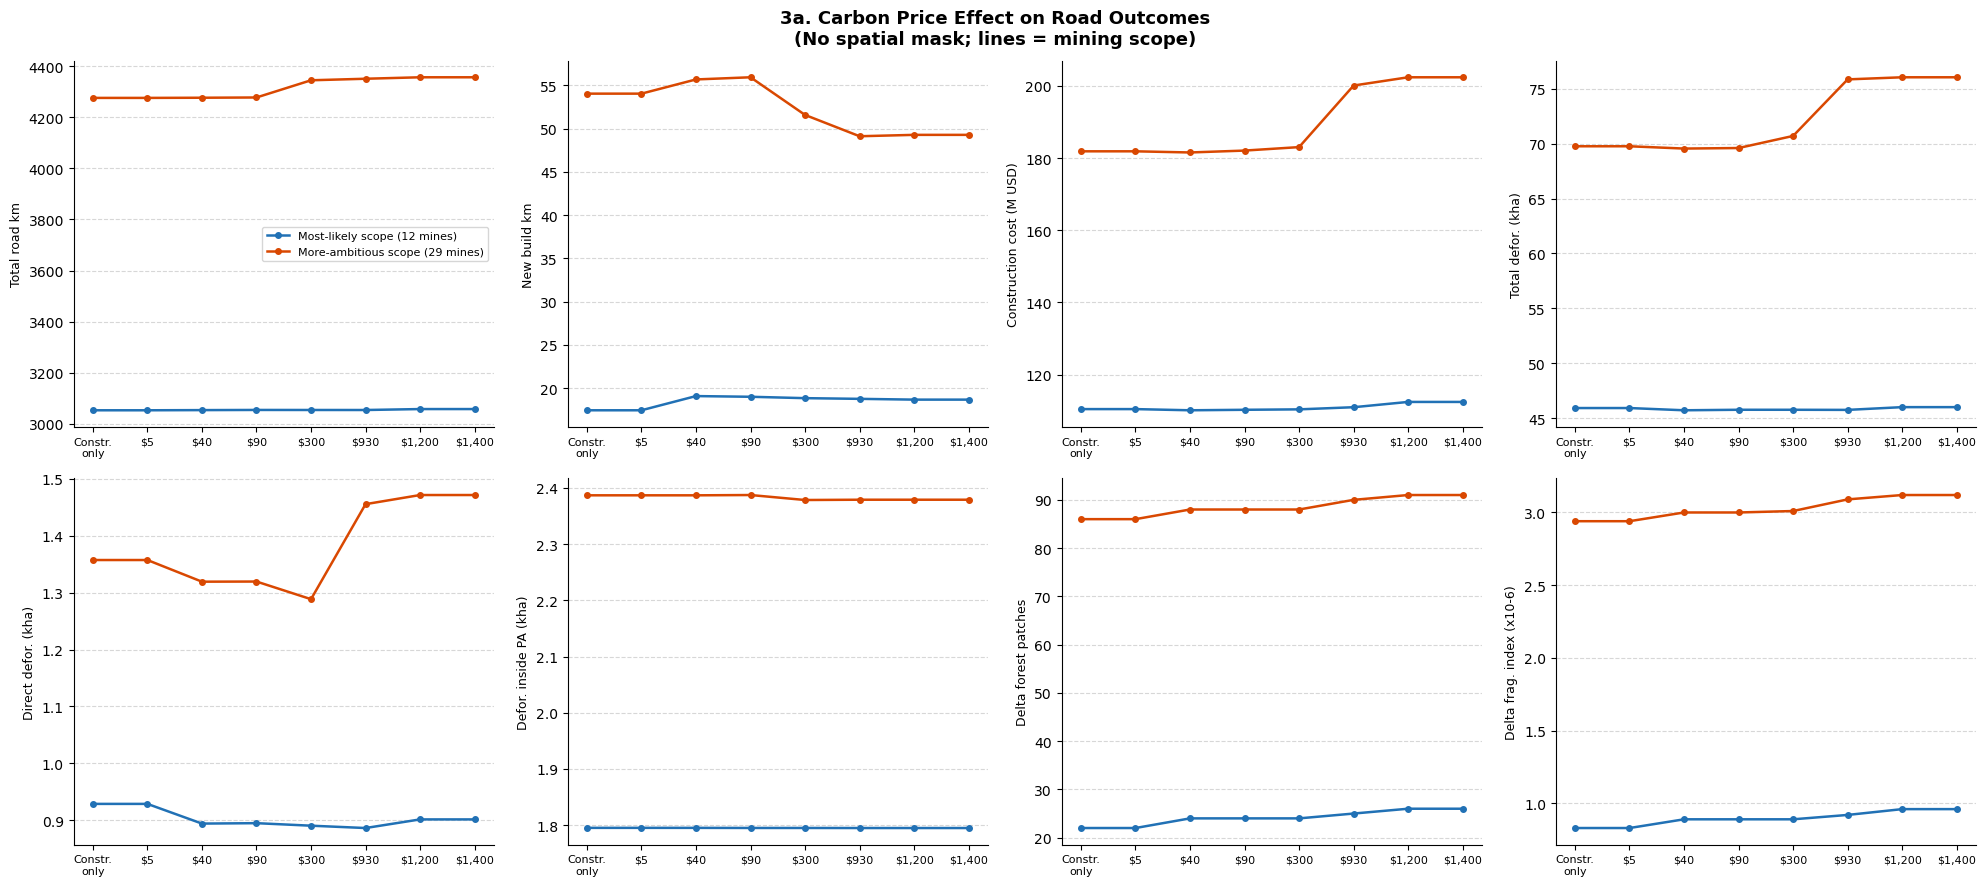

In [18]:
# ── Line plots: carbon price effect on all key metrics ───────────────────────
# x-axis = friction level, lines = mining scope

carbon_sub = data[data['mask'] == 'no_mask'].copy()

CARBON_METRICS = [
    ('total_km',              'Total road km'),
    ('to_be_built_km',        'New build km'),
    ('construction_cost_musd','Construction cost (M USD)'),
    ('defor_action_kha',      'Total defor. (kha)'),
    ('defor_direct_kha',      'Direct defor. (kha)'),
    ('defor_inside_pa_kha',   'Defor. inside PA (kha)'),
    ('frag_delta_n_patches',  'Delta forest patches'),
    ('delta_fi_e6',           'Delta frag. index (x10-6)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('3a. Carbon Price Effect on Road Outcomes\n(No spatial mask; lines = mining scope)',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, (col, ylabel) in enumerate(CARBON_METRICS):
    ax = axes_flat[i]
    for mining, color in zip(MINING_ORDER, ['#2171b5', '#d94801']):
        sub = carbon_sub[carbon_sub['mining'] == mining].sort_values('friction_x')
        ax.plot(sub['friction_x'], sub[col], color=color, marker='o', markersize=4,
                linewidth=1.8, label=MINING_LABELS[mining])
    ax.set_xticks(FX)
    ax.set_xticklabels(FX_LABELS, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        ax.legend(fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3a_carbon_effect_lines.png', dpi=150, bbox_inches='tight')
plt.show()

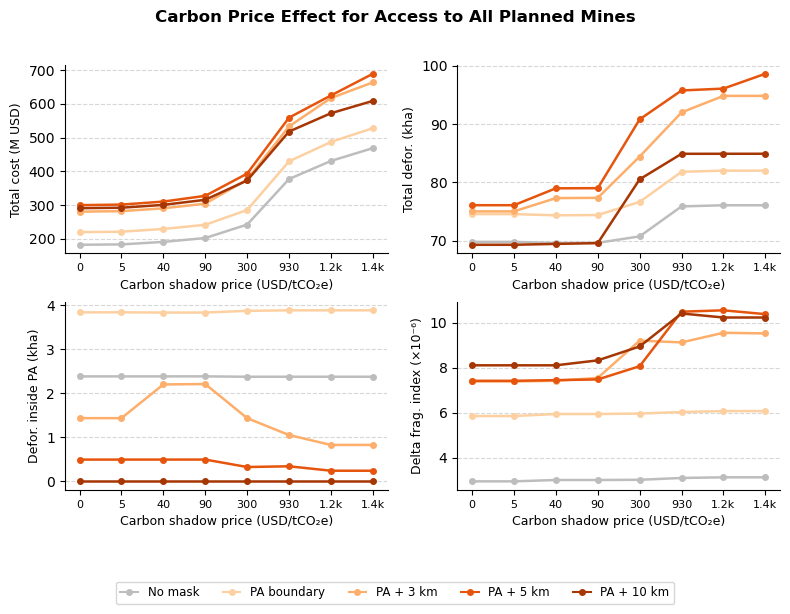

In [19]:
# ── Carbon price effect for each PA mask level ────────────────────────────────
# Shows whether carbon pricing works differently under different spatial constraints.
# Focus: late_and_early_stage (main scope), key metrics.

mining = 'late_and_early_stage'
focal_sub = data[data['mining'] == mining]

METRICS_CMASK = [
    ('total_cost_musd',         'Total cost (M USD)'),
    ('defor_action_kha',       'Total defor. (kha)'),
    ('defor_inside_pa_kha',    'Defor. inside PA (kha)'),
    ('delta_fi_e6',             'Delta frag. index (×10⁻⁶)'),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle(f'Carbon Price Effect for Access to All Planned Mines\n',
             fontsize=12, fontweight='bold')

for ax, (col, ylabel) in zip(axes.flatten(), METRICS_CMASK):
    for mask in MASK_ORDER:
        sub = focal_sub[focal_sub['mask'] == mask].sort_values('friction_x')
        ax.plot(sub['friction_x'], sub[col],
                color=MASK_COLORS[mask], marker='o', markersize=4,
                linewidth=1.8, label=MASK_LABELS[mask])
    ax.set_xticks(FX)
    ax.set_xticklabels(['0', '5', '40', '90', '300', '930', '1.2k', '1.4k'], fontsize=8)
    ax.set_xlabel('Carbon shadow price (USD/tCO₂e)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

handles = [mlines.Line2D([], [], color=MASK_COLORS[m], marker='o', markersize=4,
                          label=MASK_LABELS[m]) for m in MASK_ORDER]
fig.legend(handles=handles, fontsize=8.5, frameon=True,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=5, handlelength=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(FIGURES_DIR / 'fig3b_carbon_by_mask.png', dpi=150, bbox_inches='tight')
plt.show()

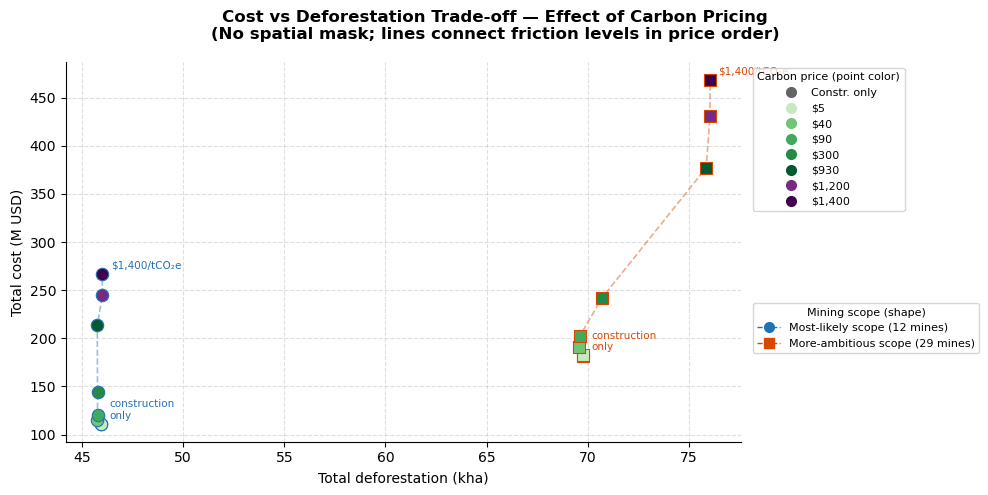

In [20]:
# ── Trade-off: total cost vs total deforestation — carbon pricing trajectory ──
# No-mask scenarios only.  Each point = one friction level.
# Lines connect points in carbon-price order, showing how pricing shifts the frontier.

nm_sub = data[data['mask'] == 'no_mask'].copy()

marker_map = {MINING_ORDER[0]: 'o', MINING_ORDER[1]: 's'}
line_colors = {MINING_ORDER[0]: '#2171b5', MINING_ORDER[1]: '#d94801'}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Cost vs Deforestation Trade-off — Effect of Carbon Pricing\n'
             '(No spatial mask; lines connect friction levels in price order)',
             fontsize=12, fontweight='bold')

for mining in MINING_ORDER:
    sub  = nm_sub[nm_sub['mining'] == mining].sort_values('friction')
    xs   = sub['defor_action_kha'].values
    ys   = sub['total_cost_musd'].values
    lc   = line_colors[mining]
    mk   = marker_map[mining]

    # Connecting line (dashed, low alpha)
    ax.plot(xs, ys, color=lc, linewidth=1.2, linestyle='--', alpha=0.45, zorder=2)

    # Points colored by friction level
    for _, row in sub.iterrows():
        ax.scatter(row['defor_action_kha'], row['total_cost_musd'],
                   color=FRICTION_COLORS[row['friction']],
                   marker=mk, s=80,
                   edgecolors=lc, linewidths=0.8, zorder=3)

    # Label construction_only and highest carbon price
    for label_fx in ['construction_only', 'carbon_1400']:
        row = sub[sub['friction'] == label_fx]
        if row.empty:
            continue
        row = row.iloc[0]
        xylabel = ('construction\nonly' if label_fx == 'construction_only'
                   else '$1,400/tCO\u2082e')
        ax.annotate(xylabel,
                    (row['defor_action_kha'], row['total_cost_musd']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color=lc)

# Friction color legend
fric_handles = [
    mlines.Line2D([], [], color=FRICTION_COLORS[f], marker='o', markersize=7,
                  linestyle='None',
                  label=FRICTION_LABELS[f].replace('\n', ' '))
    for f in FRICTION_ORDER
]
mining_handles = [
    mlines.Line2D([], [], color=line_colors[m], marker=marker_map[m],
                  markersize=7, linestyle='--', linewidth=1.0,
                  label=MINING_LABELS[m])
    for m in MINING_ORDER
]

ax.set_xlabel('Total deforestation (kha)', fontsize=10)
ax.set_ylabel('Total cost (M USD)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.4)

leg1 = ax.legend(handles=fric_handles, title='Carbon price (point color)',
                 title_fontsize=8, fontsize=8, frameon=True,
                 loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.add_artist(leg1)
ax.legend(handles=mining_handles, title='Mining scope (shape)',
          title_fontsize=8, fontsize=8, frameon=True,
          loc='upper left', bbox_to_anchor=(1.01, 0.38))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3x_tradeoff_carbon.png', dpi=150, bbox_inches='tight')
plt.show()


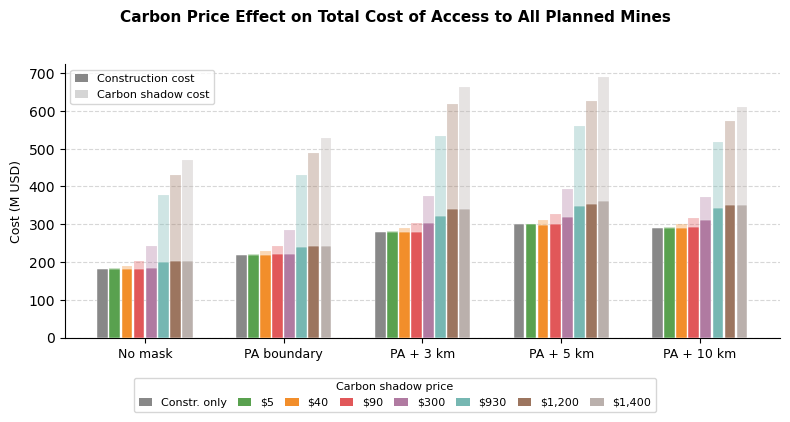

In [21]:
# ── Carbon policy effect: cost breakdown by carbon price & spatial mask ──────
# Stacked bar: construction cost (solid) + shadow cost (light tint) on top.
# Late+early stage. Bars colored by friction/carbon price level.

MASK_SHOW   = MASK_ORDER  # all 5 spatial masks
MASK_SHOW_L = [MASK_LABELS[m] for m in MASK_SHOW]
MINING_SHOW = 'late_and_early_stage'

_C_COLORS = {
    'construction_only': '#888888',
    'carbon_low':        '#59a14f',
    'carbon_central':    '#f28e2b',
    'carbon_high':       '#e15759',
    'carbon_300':        '#b07aa1',
    'carbon_930':        '#76b7b2',
    'carbon_1200':       '#9c755f',
    'carbon_1400':       '#bab0ac',
}

sub = data[data['mining'] == MINING_SHOW].copy()
if 'shadow_cost_musd' not in sub.columns:
    sub['shadow_cost_musd'] = sub['shadow_cost_usd'] / 1e6
if 'construction_cost_musd' not in sub.columns:
    sub['construction_cost_musd'] = sub['construction_cost_usd'] / 1e6

n_masks = len(MASK_SHOW)
n_fric  = len(FRICTION_ORDER)
bar_w   = 0.10
group_gap = 0.35
group_w = n_fric * bar_w
x_centers = np.arange(n_masks) * (group_w + group_gap)

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Carbon Price Effect on Total Cost of Access to All Planned Mines\n',
             fontsize=11, fontweight='bold')

for fi, fric in enumerate(FRICTION_ORDER):
    offsets = x_centers + (fi - (n_fric - 1) / 2) * bar_w
    constr_vals, shadow_vals = [], []
    for mask in MASK_SHOW:
        row = sub[(sub['mask'] == mask) & (sub['friction'] == fric)]
        constr_vals.append(row['construction_cost_musd'].values[0] if not row.empty else np.nan)
        shadow_vals.append(row['shadow_cost_musd'].values[0] if not row.empty else np.nan)
    constr_vals = np.array(constr_vals, dtype=float)
    shadow_vals = np.array(shadow_vals, dtype=float)
    col = _C_COLORS[fric]
    ax.bar(offsets, constr_vals, width=bar_w * 0.9,
           color=col, alpha=1.0, edgecolor='white', linewidth=0.3, zorder=3)
    ax.bar(offsets, shadow_vals, width=bar_w * 0.9,
           bottom=constr_vals, color=col, alpha=0.35,
           edgecolor='white', linewidth=0.3, zorder=3)

ax.set_xticks(x_centers)
ax.set_xticklabels(MASK_SHOW_L, fontsize=9)
ax.set_ylabel('Cost (M USD)', fontsize=9)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Stack layer legend (upper left)
_patch_constr = mpatches.Patch(facecolor='#888888', alpha=1.0, label='Construction cost')
_patch_shadow = mpatches.Patch(facecolor='#888888', alpha=0.35, label='Carbon shadow cost')
ax.legend(handles=[_patch_constr, _patch_shadow], fontsize=8, frameon=True,
          loc='upper left', handlelength=1.2)

# Bottom legend for carbon price colors
handles = [mpatches.Patch(facecolor=_C_COLORS[f],
                          label=FRICTION_LABELS[f].replace('\n', ' '))
           for f in FRICTION_ORDER]
fig.legend(handles=handles, title='Carbon shadow price', title_fontsize=8,
           fontsize=8, frameon=True, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=8,
           handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.savefig(FIGURES_DIR / 'fig3b_carbon_effect_bars.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 4 — Combined Policy: Additive or Non-Linear Interaction?

With both policies active simultaneously, the key analytical question is whether their effects are **additive** (independent) or **non-linear** (amplifying or dampening each other).

**Test method** for each metric *M*:
- Baseline: B = M(construction\_only, no\_mask)
- Effect of PA buffer alone: ΔPA(mask) = M(construction\_only, mask) − B
- Effect of carbon price alone: ΔC(friction) = M(friction, no\_mask) − B
- Additive prediction: B + ΔPA + ΔC
- Actual combined outcome: M(friction, mask)
- Interaction = actual − additive prediction (normalized by |B| × 100%)

C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index='friction', columns='mask', values=col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index='friction', columns='mask', values=col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_t

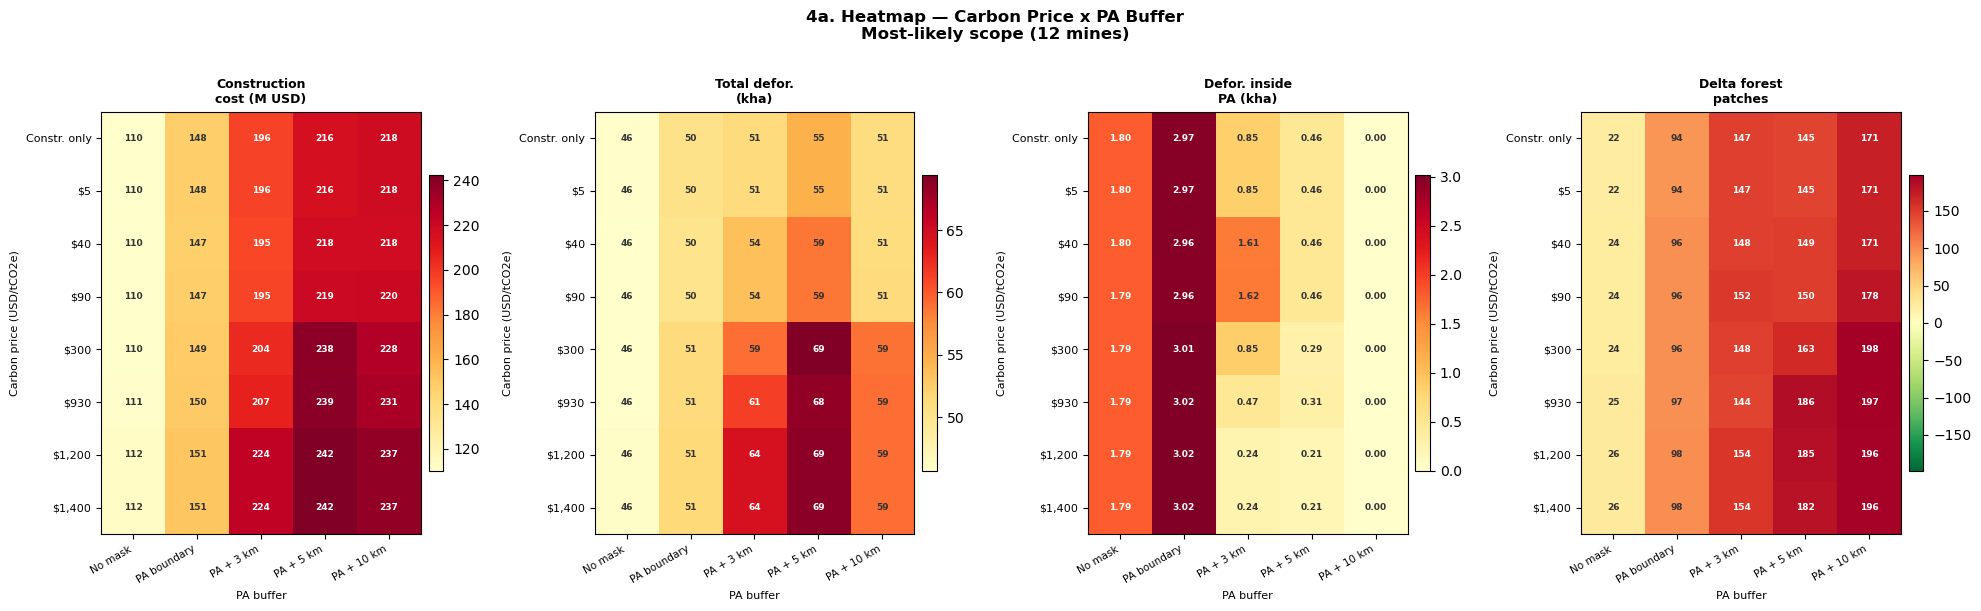

C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index='friction', columns='mask', values=col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index='friction', columns='mask', values=col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1142466738.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_t

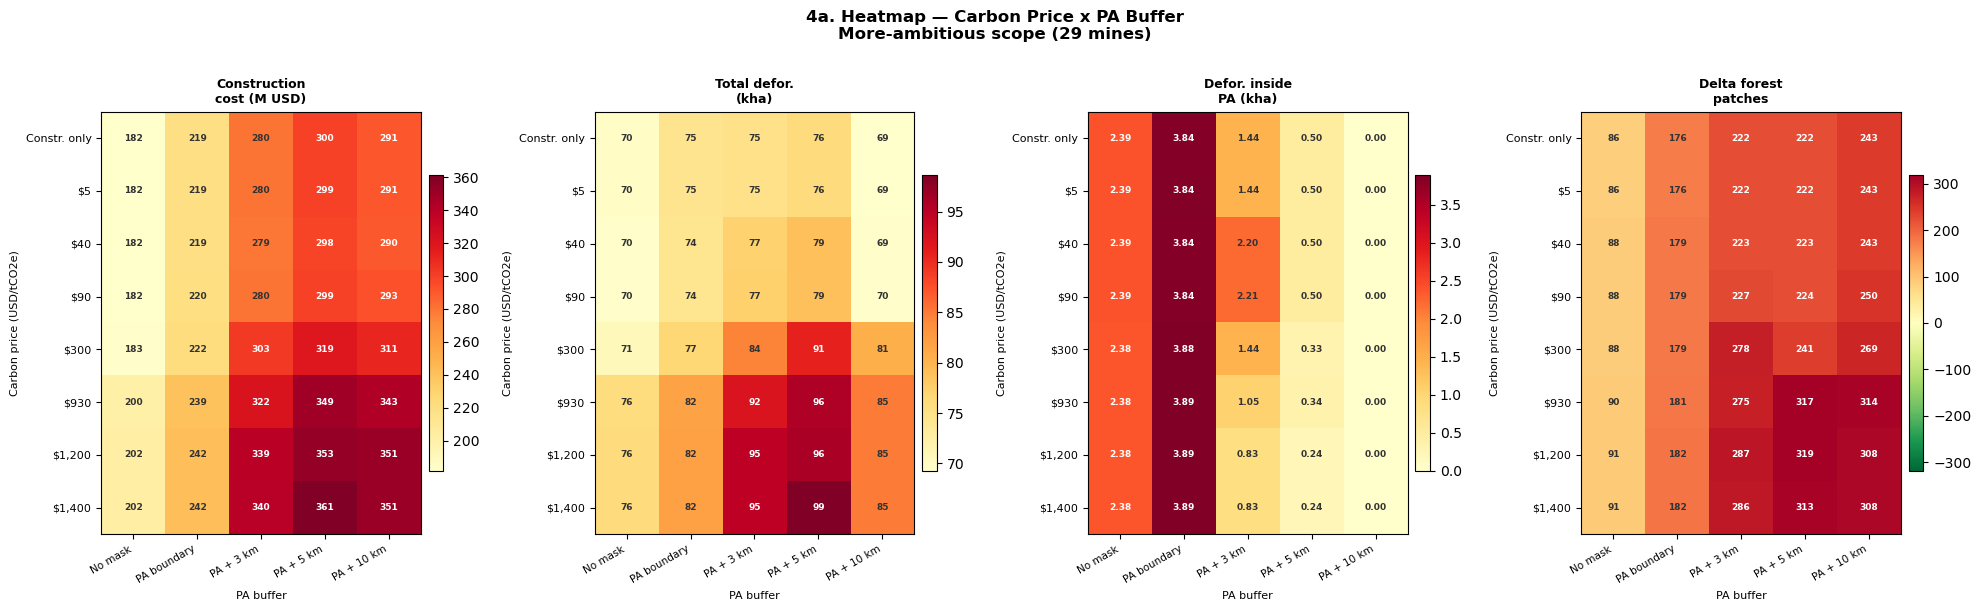

In [22]:
# ── Heatmap: carbon price × PA buffer for key metrics ─────────────────────────
HEATMAP_METRICS = [
    ('construction_cost_musd', 'Construction\ncost (M USD)', 'YlOrRd',   False),
    ('defor_action_kha',       'Total defor.\n(kha)',        'YlOrRd',   False),
    ('defor_inside_pa_kha',    'Defor. inside\nPA (kha)',    'YlOrRd',   False),
    ('frag_delta_n_patches',   'Delta forest\npatches',      'RdYlGn_r', True),
]
FRICTION_ROW_LABELS = [FRICTION_LABELS[f].replace('\n', ' ') for f in FRICTION_ORDER]

for mining in MINING_ORDER:
    sub = data[data['mining'] == mining]
    fig, axes = plt.subplots(1, len(HEATMAP_METRICS), figsize=(5 * len(HEATMAP_METRICS), 6))
    fig.suptitle(f'4a. Heatmap — Carbon Price x PA Buffer\n{MINING_LABELS[mining]}',
                 fontsize=12, fontweight='bold', y=1.01)

    for ax, (col, title, cmap, diverging) in zip(axes, HEATMAP_METRICS):
        matrix = (
            sub.pivot_table(index='friction', columns='mask', values=col, aggfunc='first')
            .reindex(index=FRICTION_ORDER, columns=MASK_ORDER)
        )
        vals = matrix.values.astype(float)
        if diverging:
            vmax = np.nanmax(np.abs(vals))
            norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        else:
            norm = mcolors.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))

        im = ax.imshow(vals, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
        for r in range(vals.shape[0]):
            for c in range(vals.shape[1]):
                v = vals[r, c]
                if not np.isnan(v):
                    bright = (im.cmap(im.norm(v))[0] * 0.299 +
                              im.cmap(im.norm(v))[1] * 0.587 +
                              im.cmap(im.norm(v))[2] * 0.114)
                    tc = 'white' if bright < 0.55 else '#333333'
                    fmt = f'{v:.0f}' if abs(v) >= 10 else f'{v:.2f}'
                    ax.text(c, r, fmt, ha='center', va='center',
                            fontsize=6.5, color=tc, fontweight='bold')
        ax.set_xticks(range(len(MASK_ORDER)))
        ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER],
                           rotation=30, ha='right', fontsize=7.5)
        ax.set_yticks(range(len(FRICTION_ORDER)))
        ax.set_yticklabels(FRICTION_ROW_LABELS, fontsize=8)
        ax.set_xlabel('PA buffer', fontsize=8)
        ax.set_ylabel('Carbon price (USD/tCO2e)', fontsize=8)
        ax.set_title(title, fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig4a_heatmap_{mining}.png', dpi=150, bbox_inches='tight')
    plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  int_df.pivot_table(index='friction', columns='mask', values=int_col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  int_df.pivot_table(index='friction', columns='mask', values=int_col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

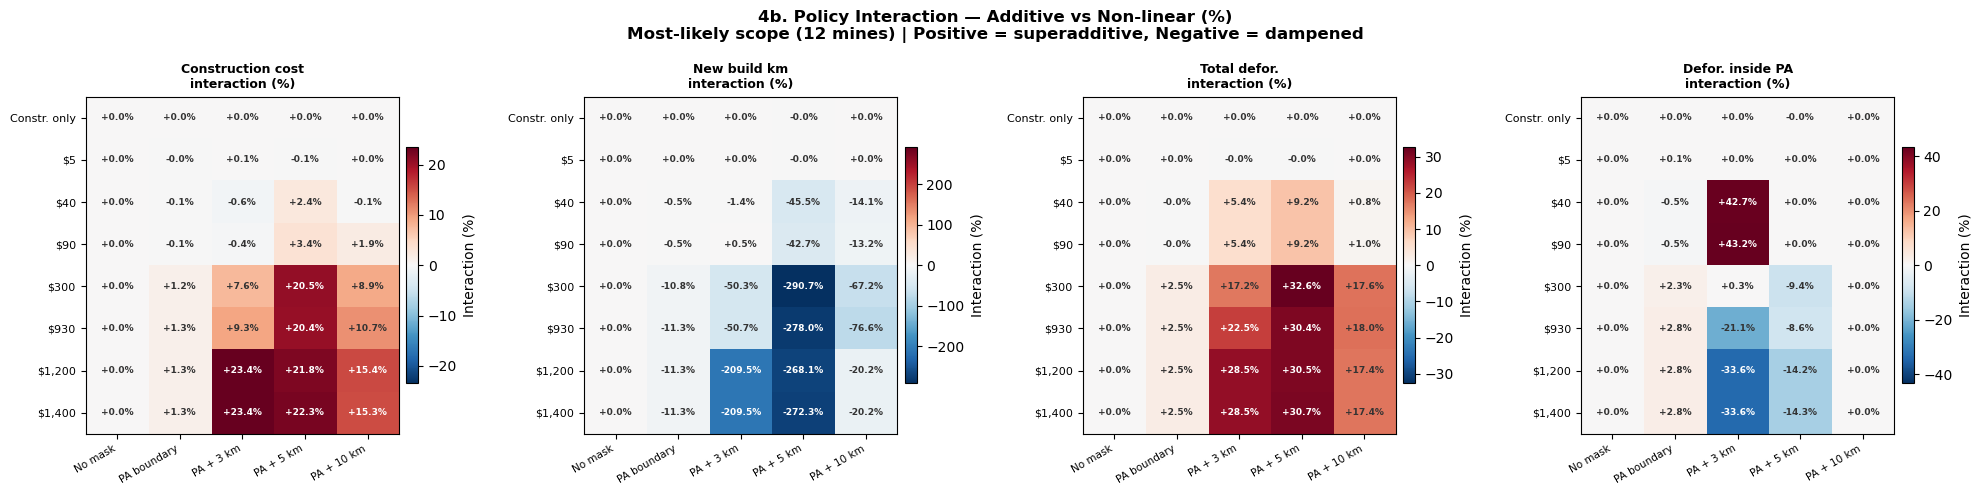

C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  int_df.pivot_table(index='friction', columns='mask', values=int_col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  int_df.pivot_table(index='friction', columns='mask', values=int_col, aggfunc='first')
C:\Users\Move\AppData\Local\Temp\ipykernel_22540\1309010749.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

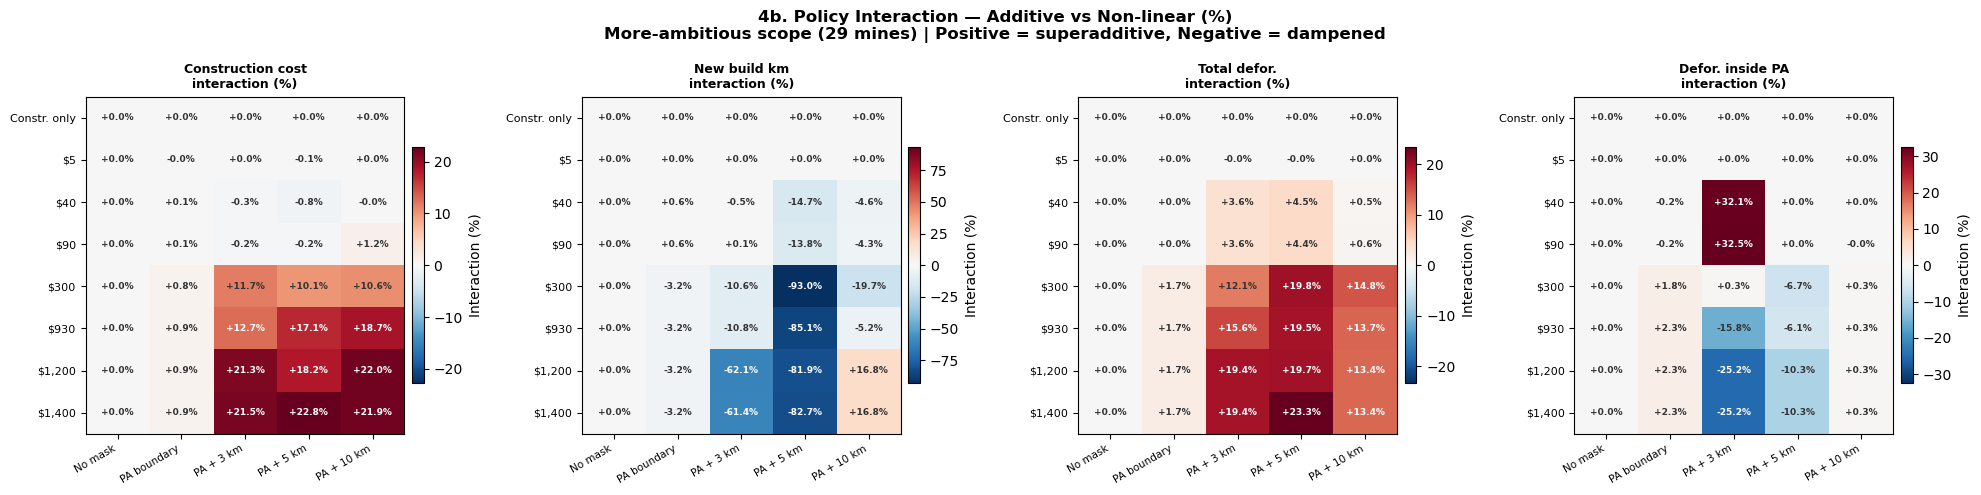

In [23]:
# ── Interaction analysis: additive vs non-linear ──────────────────────────────
# Positive interaction % = policies amplify each other (superadditive)
# Negative interaction % = policies dampen each other (subadditive)

INT_METRICS = [
    ('construction_cost_musd', 'Construction cost\ninteraction (%)'),
    ('to_be_built_km',         'New build km\ninteraction (%)'),
    ('defor_action_kha',       'Total defor.\ninteraction (%)'),
    ('defor_inside_pa_kha',    'Defor. inside PA\ninteraction (%)'),
]

for mining in MINING_ORDER:
    sub = data[data['mining'] == mining]

    # Baseline: construction_only, no_mask
    B_row = sub[(sub['friction'] == 'construction_only') & (sub['mask'] == 'no_mask')]

    int_data = []
    for friction in FRICTION_ORDER:
        for mask in MASK_ORDER:
            row = sub[(sub['friction'] == friction) & (sub['mask'] == mask)]
            if row.empty or B_row.empty:
                continue
            rec = {'friction': friction, 'mask': mask}
            for col, _ in INT_METRICS:
                B      = float(B_row[col].values[0])
                dPA    = float(sub[(sub['friction'] == 'construction_only') &
                                    (sub['mask'] == mask)][col].values[0]) - B
                dC     = float(sub[(sub['friction'] == friction) &
                                    (sub['mask'] == 'no_mask')][col].values[0]) - B
                actual = float(row[col].values[0])
                additive = B + dPA + dC
                denom = abs(B) if abs(B) > 1e-9 else 1.0
                rec[col + '_int'] = (actual - additive) / denom * 100
            int_data.append(rec)

    int_df = pd.DataFrame(int_data)
    int_df['friction'] = pd.Categorical(int_df['friction'], FRICTION_ORDER, ordered=True)
    int_df['mask']     = pd.Categorical(int_df['mask'],     MASK_ORDER,     ordered=True)

    fig, axes = plt.subplots(1, len(INT_METRICS), figsize=(5 * len(INT_METRICS), 5))
    fig.suptitle(f'4b. Policy Interaction — Additive vs Non-linear (%)\n'
                 f'{MINING_LABELS[mining]} | Positive = superadditive, Negative = dampened',
                 fontsize=12, fontweight='bold')

    for ax, (col, title) in zip(axes, INT_METRICS):
        int_col = col + '_int'
        matrix  = (
            int_df.pivot_table(index='friction', columns='mask', values=int_col, aggfunc='first')
            .reindex(index=FRICTION_ORDER, columns=MASK_ORDER)
        ).values.astype(float)

        vmax = max(np.nanmax(np.abs(matrix)), 1.0)
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', norm=norm,
                         interpolation='nearest')

        for r in range(matrix.shape[0]):
            for c in range(matrix.shape[1]):
                v = matrix[r, c]
                if not np.isnan(v):
                    bright = (im.cmap(im.norm(v))[0] * 0.299 +
                              im.cmap(im.norm(v))[1] * 0.587 +
                              im.cmap(im.norm(v))[2] * 0.114)
                    tc = 'white' if bright < 0.55 else '#333333'
                    ax.text(c, r, f'{v:+.1f}%', ha='center', va='center',
                            fontsize=6.5, color=tc, fontweight='bold')

        ax.set_xticks(range(len(MASK_ORDER)))
        ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER],
                           rotation=30, ha='right', fontsize=7.5)
        ax.set_yticks(range(len(FRICTION_ORDER)))
        ax.set_yticklabels(FRICTION_ROW_LABELS, fontsize=8)
        ax.set_title(title, fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label='Interaction (%)')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig4b_interaction_{mining}.png', dpi=150, bbox_inches='tight')
    plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_22540\534979672.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


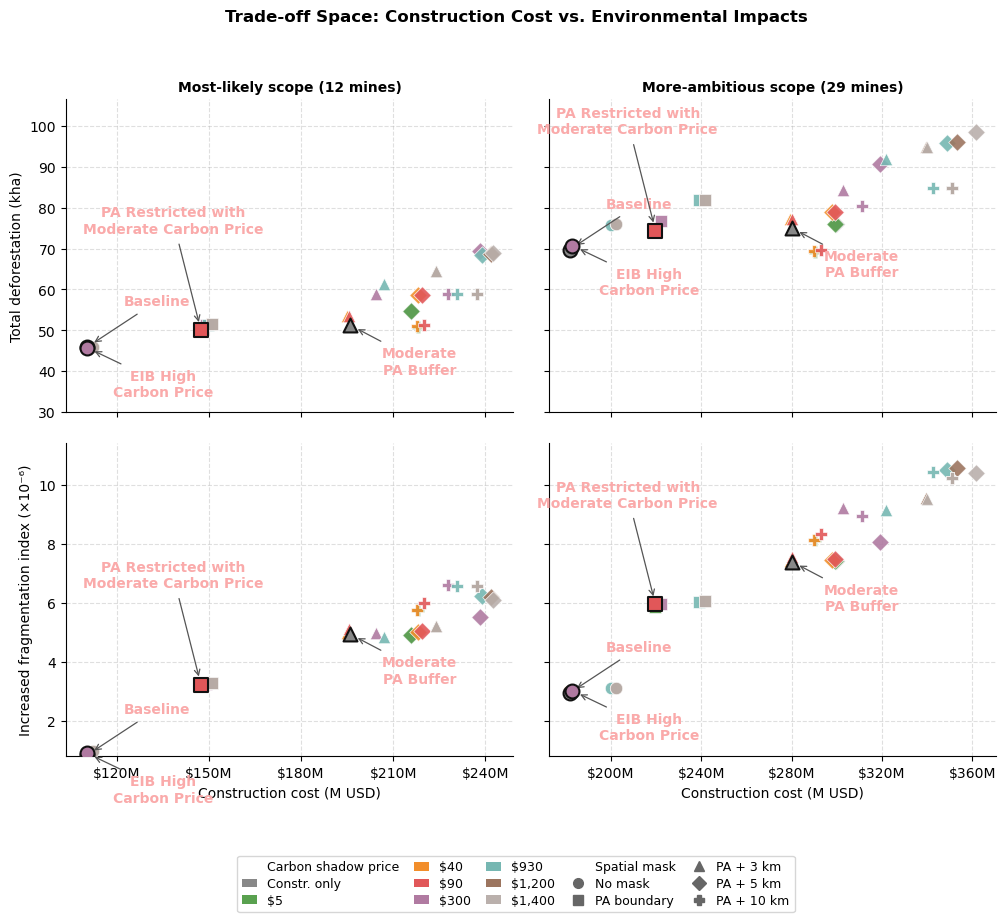

In [24]:
# ── Trade-off space: 2×2 (mining scope × metric) ────────────────────────────
# Rows: deforestation / fragmentation index.
# Cols: Late-stage / Late+Early-stage.
# Color = carbon shadow price; shape = spatial mask.

def is_pareto_efficient(x, y):
    n = len(x); is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if is_eff[i]:
            dom = (x >= x[i]) & (y >= y[i]) & ((x > x[i]) | (y > y[i]))
            dom[i] = False; is_eff[dom] = False
    return is_eff

XCOL   = 'construction_cost_musd'
METRICS = [
    ('defor_action_kha', 'Total deforestation (kha)'),
    ('delta_fi_e6',      'Increased fragmentation index (×10⁻⁶)'),
]

MASK_MKR = {
    'no_mask':                 'o',
    'protected_areas':         's',
    'protected_areas_buf3km':  '^',
    'protected_areas_buf5km':  'D',
    'protected_areas_buf10km': 'P',
}

# Distinct qualitative colors for 8 friction levels
FRICTION_COLORS_Q = {
    'construction_only':          '#888888',
    'carbon_low':                 '#59a14f',
    'carbon_central':             '#f28e2b',
    'carbon_high':                '#e15759',
    'carbon_300':                 '#b07aa1',
    'carbon_930':                 '#76b7b2',
    'carbon_1200':                '#9c755f',
    'carbon_1400':                '#bab0ac',
}

KEY_SCENARIOS = [
    ('no_mask',                'construction_only', 'Baseline',               ( 50,  30)),
    ('protected_areas_buf3km', 'construction_only', 'Moderate\nPA Buffer',   ( 50, -35)),
    ('no_mask',                'carbon_300',        'EIB High\nCarbon Price', ( 55, -35)),
    ('protected_areas',        'carbon_high',       'PA Restricted with\nModerate Carbon Price', (-20,  70)),
]

fig, axes = plt.subplots(
    2, 2, figsize=(12, 9),
    sharex='col', sharey='row',
    gridspec_kw={'wspace': 0.08, 'hspace': 0.1},
)
fig.suptitle('Trade-off Space: Construction Cost vs. Environmental Impacts',
             fontsize=12, fontweight='bold')

for col, mining in enumerate(MINING_ORDER):
    sub = data[data['mining'] == mining].copy()

    for row_idx, (ycol, ylabel) in enumerate(METRICS):
        ax = axes[row_idx, col]

        for _, r in sub.iterrows():
            ax.scatter(r[XCOL], r[ycol],
                       color=FRICTION_COLORS_Q[r['friction']],
                       marker=MASK_MKR[r['mask']], s=80,
                       alpha=0.9, edgecolors='white', linewidths=0.5, zorder=3)

        for _mask, _fric, _label, _offset in KEY_SCENARIOS:
            _r = sub[(sub['mask'] == _mask) & (sub['friction'] == _fric)]
            if _r.empty:
                continue
            _x, _y = _r[XCOL].values[0], _r[ycol].values[0]
            ax.scatter(_x, _y, s=100,
                       color=FRICTION_COLORS_Q[_fric], marker=MASK_MKR[_mask],
                       edgecolors='#111', linewidths=1.5, zorder=8)
            ax.annotate(_label, xy=(_x, _y), xytext=_offset,
                        textcoords='offset points', fontsize=10,
                        fontweight='bold', color='#faaaaa', ha='center',
                        arrowprops=dict(arrowstyle='->', color='#555',
                                        lw=0.9, shrinkA=4, shrinkB=6))

        if row_idx == 0:
            ax.set_title(MINING_LABELS[mining], fontsize=10, fontweight='bold')
        if row_idx == len(METRICS) - 1:
            ax.set_xlabel('Construction cost (M USD)', fontsize=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(True, linestyle='--', alpha=0.4)

# Shared y limits per row
for row_idx, (ycol, _) in enumerate(METRICS):
    _y = data[data['mining'].isin(MINING_ORDER)][ycol]
    _ymin = 30 if ycol == 'defor_action_kha' else (_y.min() * 1.1 if _y.min() < 0 else max(_y.min() * 0.95, 0))
    _ymax = _y.max() * 1.08
    for ax in axes[row_idx]:
        ax.set_ylim(_ymin, _ymax)

# Combined legend at bottom (3-row × 5-col)
fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS_Q[f],
                               label=FRICTION_LABELS[f].replace('\n', ' '))
                for f in FRICTION_ORDER]
mask_handles = [mlines.Line2D([], [], color='#666', marker=MASK_MKR[m],
                              linestyle='none', markersize=7, label=MASK_LABELS[m])
                for m in MASK_ORDER]
_fric_title = [mpatches.Patch(color='none', label='Carbon shadow price')]
_mask_title = [mpatches.Patch(color='none', label='Spatial mask')]
fig.legend(handles=_fric_title + fric_handles + _mask_title + mask_handles,
           loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=5, fontsize=9, frameon=True, labelspacing=0.3,
           handlelength=1.2, columnspacing=1.2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(FIGURES_DIR / 'fig4c_tradeoff_space.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Move\AppData\Local\Temp\ipykernel_22540\4162703566.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


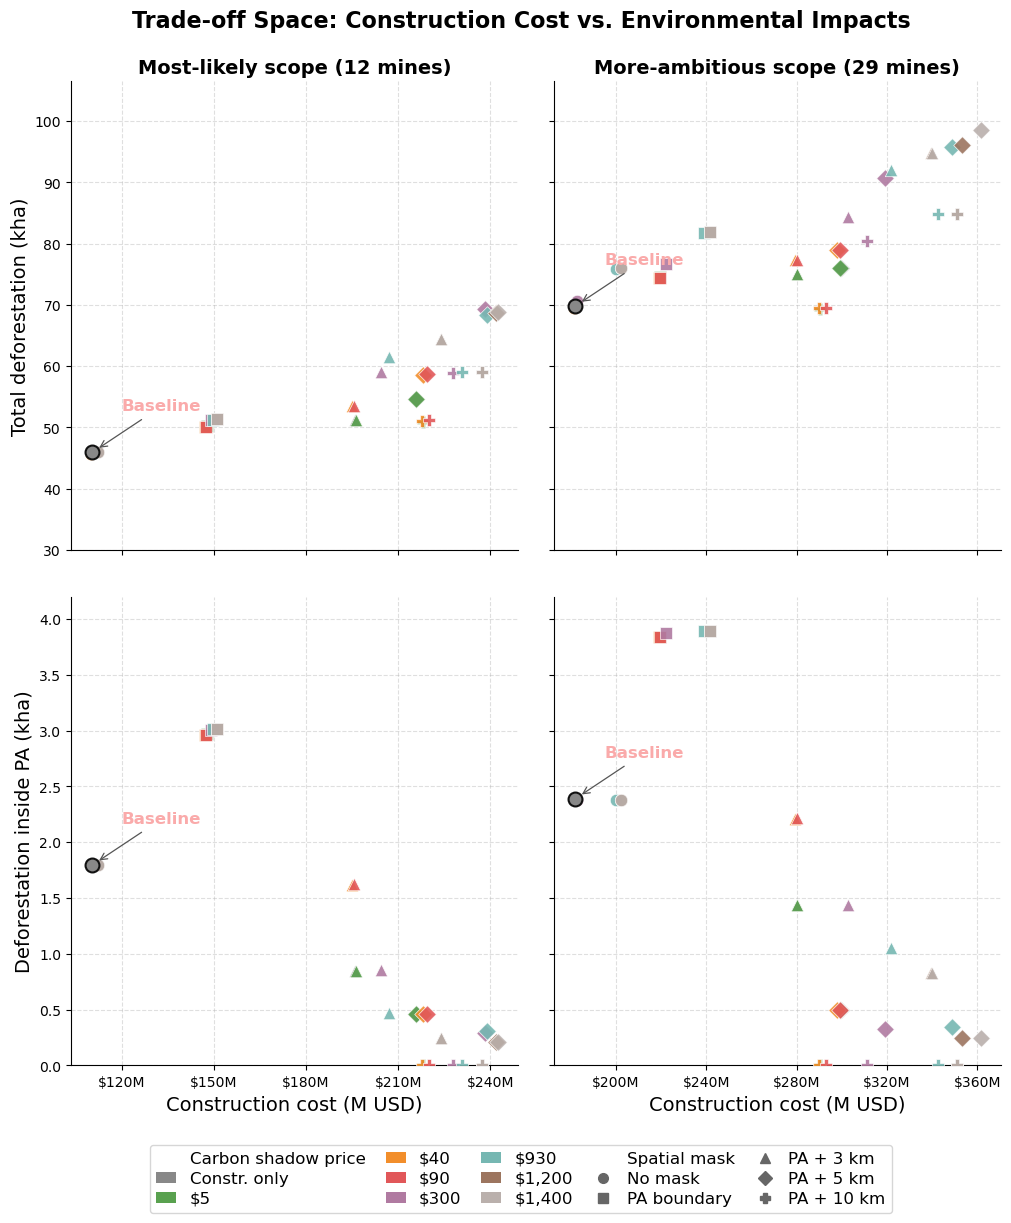

In [25]:
# ── Trade-off space: 2×2 (mining scope × metric) ────────────────────────────
# Rows: deforestation / fragmentation index.
# Cols: Late-stage / Late+Early-stage.
# Color = carbon shadow price; shape = spatial mask.

def is_pareto_efficient(x, y):
    n = len(x); is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if is_eff[i]:
            dom = (x >= x[i]) & (y >= y[i]) & ((x > x[i]) | (y > y[i]))
            dom[i] = False; is_eff[dom] = False
    return is_eff

XCOL   = 'construction_cost_musd'
METRICS = [
    ('defor_action_kha',    'Total deforestation (kha)'),
    ('defor_inside_pa_kha', 'Deforestation inside PA (kha)'),
]

MASK_MKR = {
    'no_mask':                 'o',
    'protected_areas':         's',
    'protected_areas_buf3km':  '^',
    'protected_areas_buf5km':  'D',
    'protected_areas_buf10km': 'P',
}

# Distinct qualitative colors for 8 friction levels
FRICTION_COLORS_Q = {
    'construction_only':          '#888888',
    'carbon_low':                 '#59a14f',
    'carbon_central':             '#f28e2b',
    'carbon_high':                '#e15759',
    'carbon_300':                 '#b07aa1',
    'carbon_930':                 '#76b7b2',
    'carbon_1200':                '#9c755f',
    'carbon_1400':                '#bab0ac',
}

KEY_SCENARIOS = [
    ('no_mask',                'construction_only', 'Baseline',               ( 50,  30)),
    # ('protected_areas_buf3km', 'construction_only', 'Moderate\nPA Buffer',   (-60, -35)),
    # ('no_mask',                'carbon_300',        'EIB High\nCarbon Price', ( 55, -35)),
    # ('protected_areas',        'carbon_high',       'PA Restricted with\nModerate Carbon Price', (-20,  70)),
]

fig, axes = plt.subplots(
    2, 2, figsize=(12, 12),
    sharex='col', sharey='row',
    gridspec_kw={'wspace': 0.08, 'hspace': 0.1},
)
fig.suptitle('Trade-off Space: Construction Cost vs. Environmental Impacts',
             fontsize=16, fontweight='bold')

for col, mining in enumerate(MINING_ORDER):
    sub = data[data['mining'] == mining].copy()

    for row_idx, (ycol, ylabel) in enumerate(METRICS):
        ax = axes[row_idx, col]

        for _, r in sub.iterrows():
            ax.scatter(r[XCOL], r[ycol],
                       color=FRICTION_COLORS_Q[r['friction']],
                       marker=MASK_MKR[r['mask']], s=80,
                       alpha=0.9, edgecolors='white', linewidths=0.5, zorder=3)

        for _mask, _fric, _label, _offset in KEY_SCENARIOS:
            _r = sub[(sub['mask'] == _mask) & (sub['friction'] == _fric)]
            if _r.empty:
                continue
            _x, _y = _r[XCOL].values[0], _r[ycol].values[0]
            ax.scatter(_x, _y, s=100,
                       color=FRICTION_COLORS_Q[_fric], marker=MASK_MKR[_mask],
                       edgecolors='#111', linewidths=1.5, zorder=8)
            ax.annotate(_label, xy=(_x, _y), xytext=_offset,
                        textcoords='offset points', fontsize=12,
                        fontweight='bold', color='#faaaaa', ha='center',
                        arrowprops=dict(arrowstyle='->', color='#555',
                                        lw=0.9, shrinkA=4, shrinkB=6))

        if row_idx == 0:
            ax.set_title(MINING_LABELS[mining], fontsize=14, fontweight='bold')
        if row_idx == len(METRICS) - 1:
            ax.set_xlabel('Construction cost (M USD)', fontsize=14)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(True, linestyle='--', alpha=0.4)

# Shared y limits per row
for row_idx, (ycol, _) in enumerate(METRICS):
    _y = data[data['mining'].isin(MINING_ORDER)][ycol]
    _ymin = 30 if ycol == 'defor_action_kha' else max(_y.min() * 0.9, 0)
    _ymax = _y.max() * 1.08
    for ax in axes[row_idx]:
        ax.set_ylim(_ymin, _ymax)

# Combined legend at bottom (3-row × 5-col)
fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS_Q[f],
                               label=FRICTION_LABELS[f].replace('\n', ' '))
                for f in FRICTION_ORDER]
mask_handles = [mlines.Line2D([], [], color='#666', marker=MASK_MKR[m],
                              linestyle='none', markersize=7, label=MASK_LABELS[m])
                for m in MASK_ORDER]
_fric_title = [mpatches.Patch(color='none', label='Carbon shadow price')]
_mask_title = [mpatches.Patch(color='none', label='Spatial mask')]
fig.legend(handles=_fric_title + fric_handles + _mask_title + mask_handles,
           loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=5, fontsize=12, frameon=True, labelspacing=0.3,
           handlelength=1.2, columnspacing=1.2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1, top=0.92)
plt.savefig(FIGURES_DIR / 'fig4c_tradeoff_space_pa_defor.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# (merged into s4-pareto — see 2×2 combined cell above)

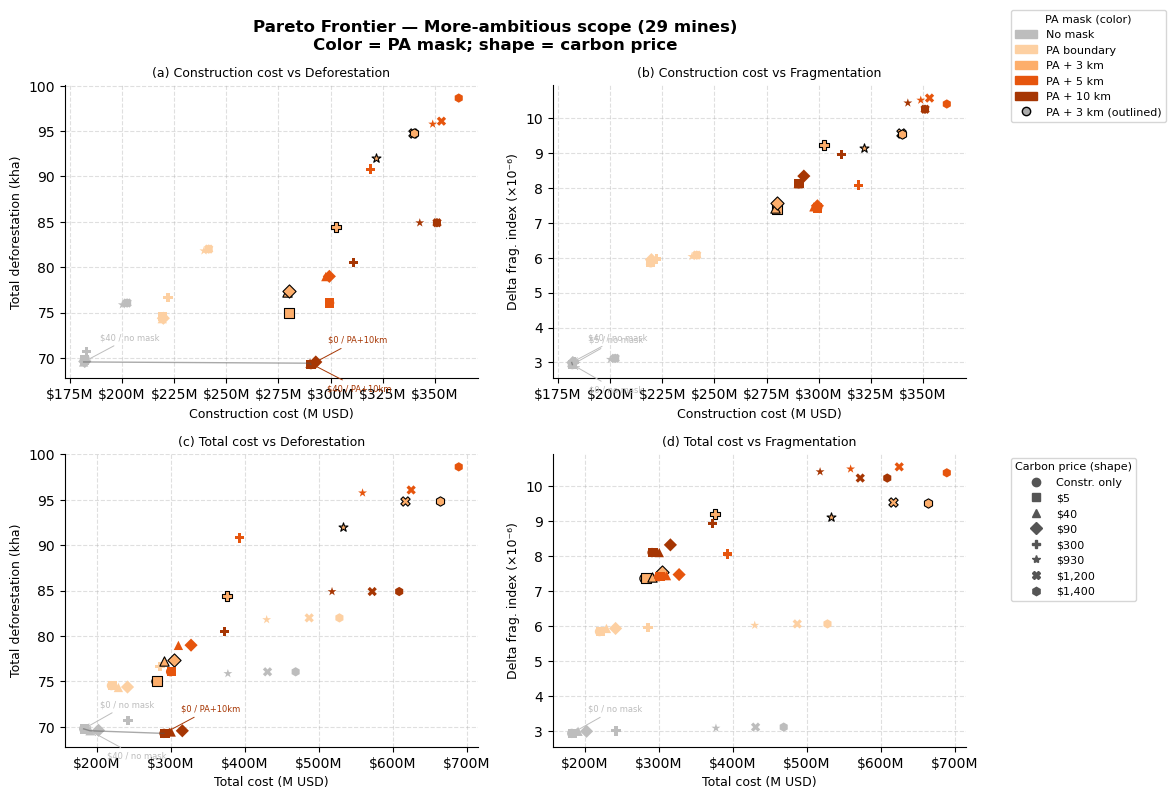


── construction_cost_musd vs defor_action_kha (late_and_early_stage) ──
  3 Pareto-efficient out of 40
         friction                    mask  construction_cost_musd  defor_action_kha
   carbon_central                 no_mask              181.574464          69.55573
   carbon_central protected_areas_buf10km              290.124736          69.41916
construction_only protected_areas_buf10km              290.535376          69.26517

── construction_cost_musd vs delta_fi_e6 (late_and_early_stage) ──
  3 Pareto-efficient out of 40
         friction    mask  construction_cost_musd  delta_fi_e6
   carbon_central no_mask              181.574464         3.00
construction_only no_mask              181.895712         2.94
       carbon_low no_mask              181.895712         2.94

── total_cost_musd vs defor_action_kha (late_and_early_stage) ──
  3 Pareto-efficient out of 40
         friction                    mask  total_cost_musd  defor_action_kha
construction_only                 n

In [27]:
# ── Pareto frontier: late+early-stage only — color = PA mask ─────────────────────────
# Drops late-stage scope so color channel is free for spatial restriction.
# Color = PA mask; shape = carbon price.  2x2: construction cost (top) / total cost (bottom).

FOCAL   = 'late_and_early_stage'
sub_all = data[data['mining'] == FOCAL].copy()

FRIC_SHORT_P = {
    'construction_only': '$0',
    'carbon_low':        '$5',
    'carbon_central':    '$40',
    'carbon_high':       '$90',
    'carbon_300':        '$300',
    'carbon_930':        '$930',
    'carbon_1200':       '$1.2k',
    'carbon_1400':       '$1.4k',
}
FRICTION_MARKERS_P2 = {
    'construction_only': 'o',
    'carbon_low':        's',
    'carbon_central':    '^',
    'carbon_high':       'D',
    'carbon_300':        'P',
    'carbon_930':        '*',
    'carbon_1200':       'X',
    'carbon_1400':       'h',
}
MASK_SHORT_P = {
    'no_mask':                 'no mask',
    'protected_areas':         'PA',
    'protected_areas_buf3km':  'PA+3km',
    'protected_areas_buf5km':  'PA+5km',
    'protected_areas_buf10km': 'PA+10km',
}

PANELS2 = [
    ('construction_cost_musd', 'defor_action_kha',
     'Construction cost (M USD)', 'Total deforestation (kha)'),
    ('construction_cost_musd', 'delta_fi_e6',
     'Construction cost (M USD)', 'Delta frag. index (×10⁻⁶)'),
    ('total_cost_musd',        'defor_action_kha',
     'Total cost (M USD)',        'Total deforestation (kha)'),
    ('total_cost_musd',        'delta_fi_e6',
     'Total cost (M USD)',        'Delta frag. index (×10⁻⁶)'),
]
PANEL_TITLES2 = [
    '(a) Construction cost vs Deforestation',
    '(b) Construction cost vs Fragmentation',
    '(c) Total cost vs Deforestation',
    '(d) Total cost vs Fragmentation',
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
fig.suptitle(
    f'Pareto Frontier — {MINING_LABELS[FOCAL]}\nColor = PA mask; shape = carbon price',
    fontsize=12, fontweight='bold'
)

for ax, (xcol, ycol, xlabel, ylabel), ptitle in zip(axes, PANELS2, PANEL_TITLES2):
    ax.set_title(ptitle, fontsize=9)

    eff = is_pareto_efficient(sub_all[xcol].values, sub_all[ycol].values)
    sub_all['pareto'] = eff

    # All scenarios
    for mask in MASK_ORDER:
        col = MASK_COLORS[mask]
        for friction in FRICTION_ORDER:
            mkr = FRICTION_MARKERS_P2[friction]
            row = sub_all[(sub_all['mask'] == mask) & (sub_all['friction'] == friction)]
            if row.empty:
                continue
            ax.scatter(row[xcol], row[ycol],
                       color=col, marker=mkr,
                       s=45,
                       alpha=1.0,
                       edgecolors='black' if mask == 'protected_areas_buf3km' else 'none',
                       linewidths=0.8,
                       zorder=3)

    # Pareto frontier line (gray, connects all efficient points)
    eff_rows = sub_all[sub_all['pareto']].sort_values(xcol)
    ax.plot(eff_rows[xcol], eff_rows[ycol],
            color='#555555', linewidth=1.0, linestyle='-', zorder=3, alpha=0.5)

    # Arrow annotations on Pareto points
    for k, (_, row) in enumerate(eff_rows.iterrows()):
        label = f"{FRIC_SHORT_P[row['friction']]} / {MASK_SHORT_P[row['mask']]}"
        dy = 16 if k % 2 == 0 else -20
        ax.annotate(
            label,
            xy=(row[xcol], row[ycol]),
            xytext=(12, dy),
            textcoords='offset points',
            fontsize=6,
            color=MASK_COLORS[row['mask']],
            arrowprops=dict(arrowstyle='->', color=MASK_COLORS[row['mask']], lw=0.7),
            zorder=5,
        )

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', alpha=0.4)

# Legends
mask_handles = [
    mpatches.Patch(color=MASK_COLORS[m], label=MASK_LABELS[m])
    for m in MASK_ORDER
]
friction_handles = [
    mlines.Line2D([], [], color='#555555', marker=FRICTION_MARKERS_P2[f],
                  markersize=6, linestyle='None',
                  label=FRICTION_LABELS[f].replace('\n', ' '))
    for f in FRICTION_ORDER
]
pa3km_handle = mlines.Line2D([], [], color='#aaaaaa', marker='o', markersize=6,
                              linestyle='None',
                              markeredgecolor='black', markerfacecolor='#aaaaaa',
                              label='PA + 3 km (outlined)')

fig.legend(handles=mask_handles + [pa3km_handle], title='PA mask (color)',
           title_fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0),
           fontsize=8, frameon=True)
fig.legend(handles=friction_handles, title='Carbon price (shape)',
           title_fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 0.44),
           fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4d_pareto_mask.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
for xcol, ycol, *_ in PANELS2:
    print(f'\n── {xcol} vs {ycol} ({FOCAL}) ──')
    eff = is_pareto_efficient(sub_all[xcol].values, sub_all[ycol].values)
    print(f'  {eff.sum()} Pareto-efficient out of {len(sub_all)}')
    eff_rows = sub_all[eff].sort_values(xcol)
    print(eff_rows[['friction', 'mask', xcol, ycol]].to_string(index=False))


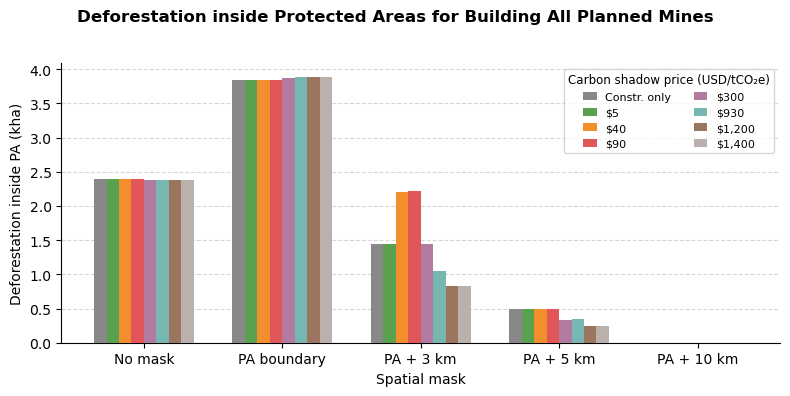

In [28]:
# ── Deforestation inside PA by spatial mask and carbon price ─────────────────
FOCAL = 'late_and_early_stage'
focal_sub = data[data['mining'] == FOCAL].copy()

n_masks   = len(MASK_ORDER)
n_fx      = len(FRICTION_ORDER)
bar_width = 0.09
x_pos     = np.arange(n_masks)
offsets   = np.linspace(-(n_fx - 1) / 2, (n_fx - 1) / 2, n_fx) * bar_width

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(
    'Deforestation inside Protected Areas for Building All Planned Mines\n',
    fontsize=12, fontweight='bold'
)

for j, friction in enumerate(FRICTION_ORDER):
    sub  = focal_sub[focal_sub['friction'] == friction]
    vals = [
        sub[sub['mask'] == m]['defor_inside_pa_kha'].values[0]
        if len(sub[sub['mask'] == m]) > 0 else 0.0
        for m in MASK_ORDER
    ]
    lbl = FRICTION_LABELS[friction].replace('\n', ' ')
    ax.bar(x_pos + offsets[j], vals, width=bar_width,
           color=FRICTION_COLORS_Q[friction], label=lbl, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=10)
ax.set_xlabel('Spatial mask', fontsize=10)
ax.set_ylabel('Deforestation inside PA (kha)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(
    title='Carbon shadow price (USD/tCO₂e)',
    fontsize=8, title_fontsize=8.5, frameon=True,
    loc='upper right', ncol=2, handlelength=1.2
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4d_defor_pa_by_mask_carbon.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Project-Level Hotspots: Mine Sensitivity

National averages can mask large heterogeneity at the project level. Here we identify:
- Which **mines** are highly sensitive to PA buffers or carbon pricing
- Which **commodities** face the greatest risk of route restriction or cost escalation
- Which mines are stable across scenario choices (policy-robust)

Sensitivity is measured as the percentage cost increase from the baseline scenario (construction-only, no mask) to the high-policy scenario of interest.

In [29]:
# ── Load per-mine data ─────────────────────────────────────────────────────────
action_wide  = pd.read_csv(PER_MINE_DIR / 'per_mine_action_needed.csv',    index_col='mine_id')
cost_wide    = pd.read_csv(PER_MINE_DIR / 'per_mine_cost_usd.csv',         index_col='mine_id')
total_km_w   = pd.read_csv(PER_MINE_DIR / 'per_mine_total_length_km.csv',  index_col='mine_id')
direct_wide  = pd.read_csv(PER_MINE_DIR / 'per_mine_defor_direct_ha.csv',  index_col='mine_id')
total_d_wide = pd.read_csv(PER_MINE_DIR / 'per_mine_defor_total_ha.csv',   index_col='mine_id')

mine_names     = action_wide['mine_name']
MINE_IDS       = action_wide.index.tolist()
scenario_cols  = [c for c in action_wide.columns if c != 'mine_name']

mines_ref          = pd.read_csv(MINES_FP)
mine_commodity_map = mines_ref.set_index('ID')['PRIMARY_COMMODITY'].to_dict()
mine_stage_map     = mines_ref.set_index('ID')['DEV_STAGE_AGGREGATED_SNL'].to_dict()

def commodity_color(mid):
    return COMMODITY_COLORS.get(mine_commodity_map.get(mid, ''), '#aaaaaa')

def commodity_legend_handles():
    return [mpatches.Patch(facecolor=COMMODITY_COLORS[c], label=c.title())
            for c in COMMODITY_ORDER if c in COMMODITY_COLORS]

def melt_wide(df, value_name):
    d = df.drop(columns='mine_name').reset_index()
    return d.melt(id_vars='mine_id', var_name='scenario', value_name=value_name)

def parse_scenarios(df):
    def _parse(stem):
        mining, rest = stem.split('__kribi__')
        rest   = rest.replace('__ds1', '')
        tokens = rest.split('__')
        return mining, '__'.join(tokens[:-1]), tokens[-1]
    parsed = df['scenario'].apply(_parse)
    df[['mining','friction','mask']] = pd.DataFrame(parsed.tolist(), index=df.index)
    df['friction'] = pd.Categorical(df['friction'], FRICTION_ORDER, ordered=True)
    df['mask']     = pd.Categorical(df['mask'],     MASK_ORDER,     ordered=True)
    df['mining']   = pd.Categorical(df['mining'],   MINING_ORDER,   ordered=True)
    return df

long = melt_wide(action_wide,  'action')
long = long.merge(melt_wide(cost_wide,    'cost_usd'),    on=['mine_id','scenario'])
long = long.merge(melt_wide(total_km_w,   'km_total'),    on=['mine_id','scenario'])
long = long.merge(melt_wide(direct_wide,  'defor_direct'),on=['mine_id','scenario'])
long = long.merge(melt_wide(total_d_wide, 'defor_total'), on=['mine_id','scenario'])
long = parse_scenarios(long)
long['mine_name'] = long['mine_id'].map(mine_names)
long['commodity'] = long['mine_id'].map(mine_commodity_map)
long['stage']     = long['mine_id'].map(mine_stage_map)
long['cost_musd'] = pd.to_numeric(long['cost_usd'], errors='coerce') / 1e6
for c in ['km_total','defor_direct','defor_total']:
    long[c] = pd.to_numeric(long[c], errors='coerce')
long = long.sort_values(['mining','friction','mask','mine_id']).reset_index(drop=True)

print(f'Long table: {len(long):,} rows')
print('Action counts:', long['action'].value_counts().to_dict())

Long table: 2,320 rows
Action counts: {'upgrade': 1274, 'out_of_scope': 680, 'build': 238, 'no_action': 128}


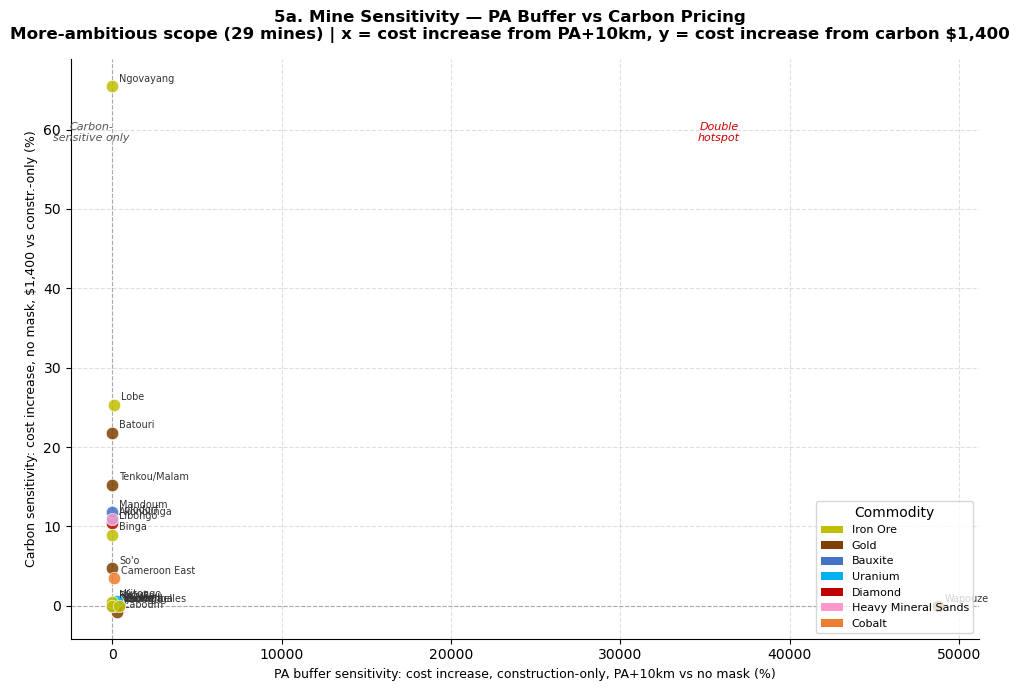

,Mine,Commodity,Baseline cost (M$),PA sensitivity (%),Carbon sensitivity (%)
16,Wapouze,gold,$0.1M,+48723.4%,+0.0%
28,Sanaga,iron ore,$2.4M,+414.3%,+0.0%
18,Bibemi,gold,$9.7M,+373.7%,+0.1%
8,Laboum,gold,$6.1M,+309.2%,-0.8%
23,Kitongo,uranium,$9.1M,+296.8%,+0.5%
21,Cameroon East,cobalt,$8.8M,+95.1%,+3.5%
24,Lobe,iron ore,$4.6M,+83.7%,+25.3%
9,Les Mamelles,iron ore,$4.0M,+53.6%,+0.0%
0,Akonolinga,iron ore,$1.4M,+29.2%,+0.0%
5,Djoum III,iron ore,$3.9M,+10.1%,+0.0%


In [30]:
# ── Mine sensitivity: PA buffer sensitivity vs carbon price sensitivity ────────
# For late_and_early_stage scope:
#   PA sensitivity = pct cost increase (construction_only: PA+10km vs no_mask)
#   Carbon sensitivity = pct cost increase (no_mask: carbon_1400 vs construction_only)
#
# Mines in the upper-right are "double hotspots" sensitive to both policies.
# Mines at the origin are policy-robust (no cost increase from either policy).

focal_mining = 'late_and_early_stage'

def get_cost(mining, friction, mask):
    rows = long[
        (long['mining']   == mining) &
        (long['friction'] == friction) &
        (long['mask']     == mask) &
        (long['action'].isin(['upgrade', 'build']))
    ].set_index('mine_id')['cost_musd']
    return rows

base_cost    = get_cost(focal_mining, 'construction_only', 'no_mask')
pa_cost      = get_cost(focal_mining, 'construction_only', 'protected_areas_buf10km')
carbon_cost  = get_cost(focal_mining, 'carbon_1400',       'no_mask')

sens_records = []
for mid in MINE_IDS:
    b  = base_cost.get(mid,   np.nan)
    p  = pa_cost.get(mid,     np.nan)
    c  = carbon_cost.get(mid, np.nan)
    if pd.isna(b) or b < 1e-6:
        pa_sens     = 0.0
        carbon_sens = 0.0
    else:
        pa_sens     = (p - b) / b * 100 if not pd.isna(p) else 0.0
        carbon_sens = (c - b) / b * 100 if not pd.isna(c) else 0.0
    sens_records.append({
        'mine_id':     mid,
        'mine_name':   mine_names.get(mid, mid),
        'commodity':   mine_commodity_map.get(mid, 'unknown'),
        'baseline_cost_musd': b if not pd.isna(b) else 0.0,
        'pa_sensitivity_pct':     pa_sens,
        'carbon_sensitivity_pct': carbon_sens,
        'pa_inaccessible': (not pd.isna(b) and b >= 1e-6 and pd.isna(p)),
    })

sens_df = pd.DataFrame(sens_records)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle(f'5a. Mine Sensitivity — PA Buffer vs Carbon Pricing\n'
             f'{MINING_LABELS[focal_mining]} | x = cost increase from PA+10km, y = cost increase from carbon $1,400',
             fontsize=12, fontweight='bold')

for _, row in sens_df.iterrows():
    color = COMMODITY_COLORS.get(row['commodity'], '#aaaaaa')
    ax.scatter(row['pa_sensitivity_pct'], row['carbon_sensitivity_pct'],
               color=color, s=80, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
    if abs(row['pa_sensitivity_pct']) > 2 or abs(row['carbon_sensitivity_pct']) > 2:
        ax.annotate(row['mine_name'],
                    (row['pa_sensitivity_pct'], row['carbon_sensitivity_pct']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7, color='#333333')

ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xlabel('PA buffer sensitivity: cost increase, construction-only, PA+10km vs no mask (%)', fontsize=9)
ax.set_ylabel('Carbon sensitivity: cost increase, no mask, $1,400 vs constr.-only (%)', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.4)

# Quadrant labels
xr = ax.get_xlim(); yr = ax.get_ylim()
ax.text(xr[1]*0.7, yr[1]*0.85, 'Double\nhotspot', fontsize=8, color='#cc0000',
        style='italic', ha='center')
ax.text(xr[0]*0.5 if xr[0] < 0 else xr[1]*0.05, yr[1]*0.85, 'Carbon-\nsensitive only',
        fontsize=8, color='#555555', style='italic', ha='center')

ax.legend(handles=commodity_legend_handles(), title='Commodity', fontsize=8,
          frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(PM_FIGURES_DIR / 'fig5a_mine_sensitivity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

display(sens_df.sort_values('pa_sensitivity_pct', ascending=False)
        [['mine_name','commodity','baseline_cost_musd','pa_sensitivity_pct','carbon_sensitivity_pct']]
        .rename(columns={'mine_name':'Mine','commodity':'Commodity',
                         'baseline_cost_musd':'Baseline cost (M$)',
                         'pa_sensitivity_pct':'PA sensitivity (%)',
                         'carbon_sensitivity_pct':'Carbon sensitivity (%)'})
        .style.format({'Baseline cost (M$)':'${:.1f}M',
                       'PA sensitivity (%)':'{:+.1f}%',
                       'Carbon sensitivity (%)':'{:+.1f}%'}))

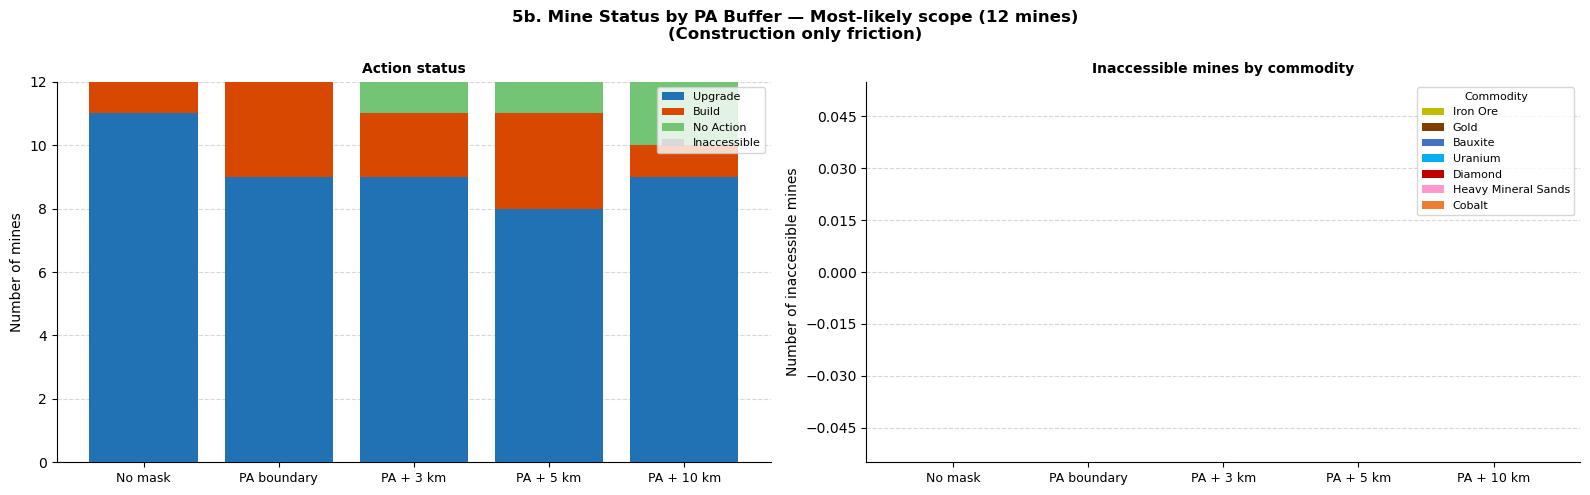

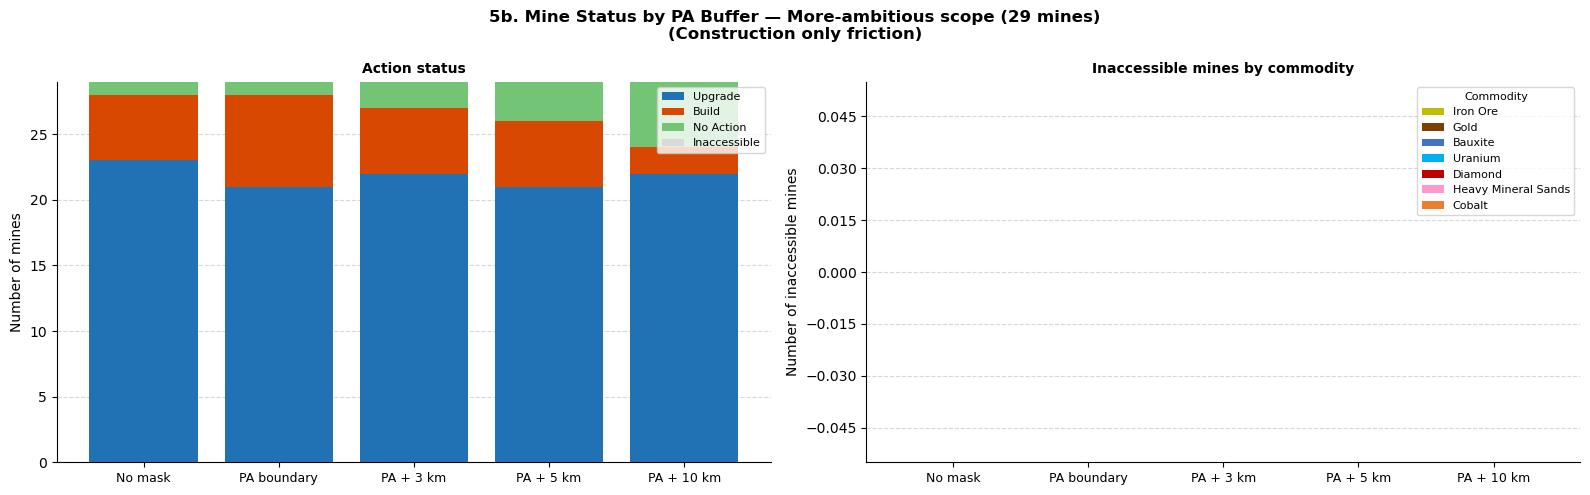

In [31]:
# ── Inaccessible and blocked mines by commodity as PA buffer grows ─────────────
# Uses construction_only friction to isolate the PA masking effect.
# 'inaccessible' = mine cannot reach port under this scenario.
# 'out_of_scope' = mine not in this mining scope (shown but not counted as blocked).

STATUS_COLORS = {
    'upgrade':      '#2171b5',
    'build':        '#d94801',
    'no_action':    '#74c476',
    'inaccessible': '#d9d9d9',
}

for focal_mining in MINING_ORDER:
    # Filter: construction_only friction only, relevant mining scope
    acc_sub = long[
        (long['mining']   == focal_mining) &
        (long['friction'] == 'construction_only')
    ].copy()
    # Replace out_of_scope with NaN to focus on in-scope mines
    acc_sub = acc_sub[acc_sub['action'] != 'out_of_scope']

    # Count action status by commodity × mask
    counts = (
        acc_sub.groupby(['commodity','mask','action'], observed=True)
        .size().reset_index(name='n')
    )
    counts['mask'] = pd.Categorical(counts['mask'], MASK_ORDER, ordered=True)

    # Build stacked bar: x = mask, colors = commodity, show inaccessible count per commodity
    inac_by_comm = (
        acc_sub[acc_sub['action'] == 'inaccessible']
        .groupby(['commodity','mask'], observed=True).size().reset_index(name='n')
    )
    inac_by_comm['mask'] = pd.Categorical(inac_by_comm['mask'], MASK_ORDER, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'5b. Mine Status by PA Buffer — {MINING_LABELS[focal_mining]}\n'
                 f'(Construction only friction)',
                 fontsize=12, fontweight='bold')

    # Left: stacked bar of action status × mask (all in-scope mines)
    ax = axes[0]
    status_order = ['upgrade', 'build', 'no_action', 'inaccessible']
    x_pos_m      = np.arange(len(MASK_ORDER))
    bottoms      = np.zeros(len(MASK_ORDER))
    for status in status_order:
        vals = []
        for mask in MASK_ORDER:
            n = counts[(counts['mask'] == mask) & (counts['action'] == status)]['n'].sum()
            vals.append(n)
        ax.bar(x_pos_m, vals, bottom=bottoms, color=STATUS_COLORS.get(status, '#cccccc'),
               label=status.replace('_', ' ').title(), zorder=3)
        bottoms += np.array(vals)
    ax.set_xticks(x_pos_m)
    ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=9)
    ax.set_ylabel('Number of mines', fontsize=10)
    ax.set_title('Action status', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, frameon=True, loc='upper right')

    # Right: stacked bar of INACCESSIBLE mines by commodity × mask
    ax2 = axes[1]
    bottoms2 = np.zeros(len(MASK_ORDER))
    for comm in COMMODITY_ORDER:
        vals2 = []
        for mask in MASK_ORDER:
            n = inac_by_comm[
                (inac_by_comm['commodity'] == comm) &
                (inac_by_comm['mask'] == mask)
            ]['n'].sum()
            vals2.append(n)
        ax2.bar(x_pos_m, vals2, bottom=bottoms2,
                color=COMMODITY_COLORS.get(comm, '#aaaaaa'),
                label=comm.title(), zorder=3)
        bottoms2 += np.array(vals2)
    ax2.set_xticks(x_pos_m)
    ax2.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=9)
    ax2.set_ylabel('Number of inaccessible mines', fontsize=10)
    ax2.set_title('Inaccessible mines by commodity', fontsize=10, fontweight='bold')
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_axisbelow(True)
    ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(handles=commodity_legend_handles(), fontsize=8,
               title='Commodity', title_fontsize=8, frameon=True)

    plt.tight_layout()
    plt.savefig(PM_FIGURES_DIR / f'fig5b_inaccessible_by_commodity_{focal_mining}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

### How mine-level cost sensitivities are calculated

Each mine receives two sensitivity scores, both expressed as a **percentage cost increase** relative to the same baseline scenario.

**Baseline** (shared by both metrics):
> Construction-cost-only friction layer (`construction_only`), no spatial restriction (`no_mask`).
> Only road segments classified as `upgrade` or `build` are included; mines with no viable route (`inaccessible`) or zero baseline cost are assigned 0 %.

---

#### 1. PA buffer cost sensitivity (%)

Measures how much the total road cost rises when mines must be accessed without crossing within 10 km of any protected area.

$$
\text{PA sensitivity}_i = \frac{\text{cost}(\text{PA+10 km},\,\text{constr. only})_i - \text{cost}(\text{no mask},\,\text{constr. only})_i}{\text{cost}(\text{no mask},\,\text{constr. only})_i} \times 100
$$

A high value indicates that the optimal route passes through or very close to a protected area, so the 10 km exclusion buffer forces a significantly longer or more expensive detour.

---

#### 2. Carbon price cost sensitivity (%)

Measures how much the total road cost rises when a carbon shadow price of USD 1,400/tCO₂e is added to the friction surface (no spatial restriction applied).

$$
\text{Carbon sensitivity}_i = \frac{\text{cost}(\text{no mask},\,\$1{,}400/\text{tCO}_2\text{e})_i - \text{cost}(\text{no mask},\,\text{constr. only})_i}{\text{cost}(\text{no mask},\,\text{constr. only})_i} \times 100
$$

A high value indicates that the route passes through high-carbon forest — the shadow price inflates the accounting cost even if the physical alignment does not change.

---

**Note:** Both metrics use the most extreme policy lever in their respective dimension (PA + 10 km buffer; USD 1,400/tCO₂e carbon price) to maximise contrast between low- and high-sensitivity mines.

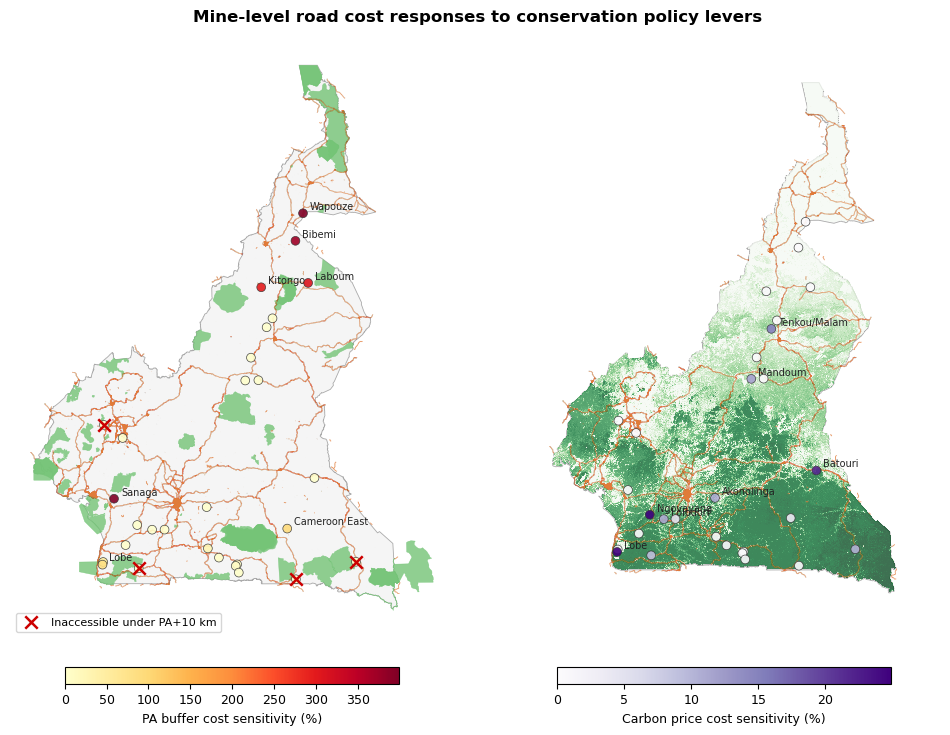

In [42]:
# ── Mine sensitivity map: cost-increase factor ────────────────────────────────
# Mines colored by their PA sensitivity (% cost increase under PA+10km vs no_mask,
# construction_only). Left: PA polygons. Right: 2024 tree cover clipped to Cameroon.

TREECOVER_FP = Path('../data/output/processed-hansen-treecover/cameroon_treecover2024_30m.tif')
with rasterio.open(TREECOVER_FP) as _src:
    _ds    = 15
    _out_h = _src.height // _ds
    _out_w = _src.width  // _ds
    _arr   = _src.read(1, out_shape=(_out_h, _out_w),
                       resampling=RioResampling.average).astype(float)
    _bnd   = _src.bounds
    _out_tfm = tfm_from_bounds(_bnd.left, _bnd.bottom, _bnd.right, _bnd.top, _out_w, _out_h)

_cmr_mask = rio_rasterize(
    [(geom.__geo_interface__, 1) for geom in adm0.to_crs('EPSG:4326').geometry],
    out_shape=(_out_h, _out_w),
    transform=_out_tfm,
    fill=0, dtype='uint8',
)
_tc_extent = [_bnd.left, _bnd.right, _bnd.bottom, _bnd.top]
_tc_arr    = np.where(_cmr_mask == 1, _arr, np.nan)

mines_geo = mines_ref[mines_ref['ID'].isin(MINE_IDS)].copy()

# Merge sensitivity values
mines_geo = mines_geo.merge(
    sens_df[['mine_id','pa_sensitivity_pct','carbon_sensitivity_pct','baseline_cost_musd','pa_inaccessible']],
    left_on='ID', right_on='mine_id', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
fig.suptitle('Mine-level road cost responses to conservation policy levers',
             fontsize=12, fontweight='bold')

for ax, (col, label, cmap_name) in zip(axes, [
    ('pa_sensitivity_pct',     'PA buffer cost sensitivity (%)',    'YlOrRd'),
    ('carbon_sensitivity_pct', 'Carbon price cost sensitivity (%)', 'Purples'),
]):
    adm0.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.6)

    if col == 'pa_sensitivity_pct':
        pa_core.plot(ax=ax, color='#74c476', edgecolor='#74c476', linewidth=0.3, alpha=0.8, zorder=2)
    else:
        ax.imshow(_tc_arr, extent=_tc_extent, cmap='Greens', vmin=0, vmax=100,
                  origin='upper', alpha=0.75, zorder=2, interpolation='nearest')

    paved_rds.plot(ax=ax, color='#e07b39', linewidth=0.6, zorder=3, alpha=0.8)

    vals  = mines_geo[col].fillna(0).clip(lower=0)
    norm  = mcolors.Normalize(vmin=0, vmax=vals.quantile(0.95) + 1)
    cmap  = plt.get_cmap(cmap_name)
    colors_mine = [cmap(norm(v)) for v in vals]

    ax.scatter(
        mines_geo['LONGITUDE'], mines_geo['LATITUDE'],
        c=colors_mine, s=40,
        edgecolors='#333333', linewidths=0.5,
        zorder=4, alpha=0.9,
    )

    for _, row in mines_geo.iterrows():
        if row[col] > vals.quantile(0.75):
            ax.annotate(row['PROP_NAME'],
                        (row['LONGITUDE'], row['LATITUDE']),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=7, color='#222222')

    # Overlay x marker for mines inaccessible under PA+10km (PA panel only)
    if col == 'pa_sensitivity_pct' and 'pa_inaccessible' in mines_geo.columns:
        _inac = mines_geo[mines_geo['pa_inaccessible'] == True]
        if not _inac.empty:
            ax.scatter(
                _inac['LONGITUDE'], _inac['LATITUDE'],
                marker='x', s=80, color='#cc0000', linewidths=1.8,
                zorder=5, label='Inaccessible under PA+10 km',
            )
            ax.legend(fontsize=8, loc='lower left', frameon=True)

    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', location='bottom', shrink=0.7, pad=0.04)
    cbar.set_label(label, fontsize=9)
    cbar.ax.tick_params(labelsize=9)

    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig(PM_FIGURES_DIR / 'fig5c_mine_sensitivity_map.png', dpi=150, bbox_inches='tight')
plt.show()

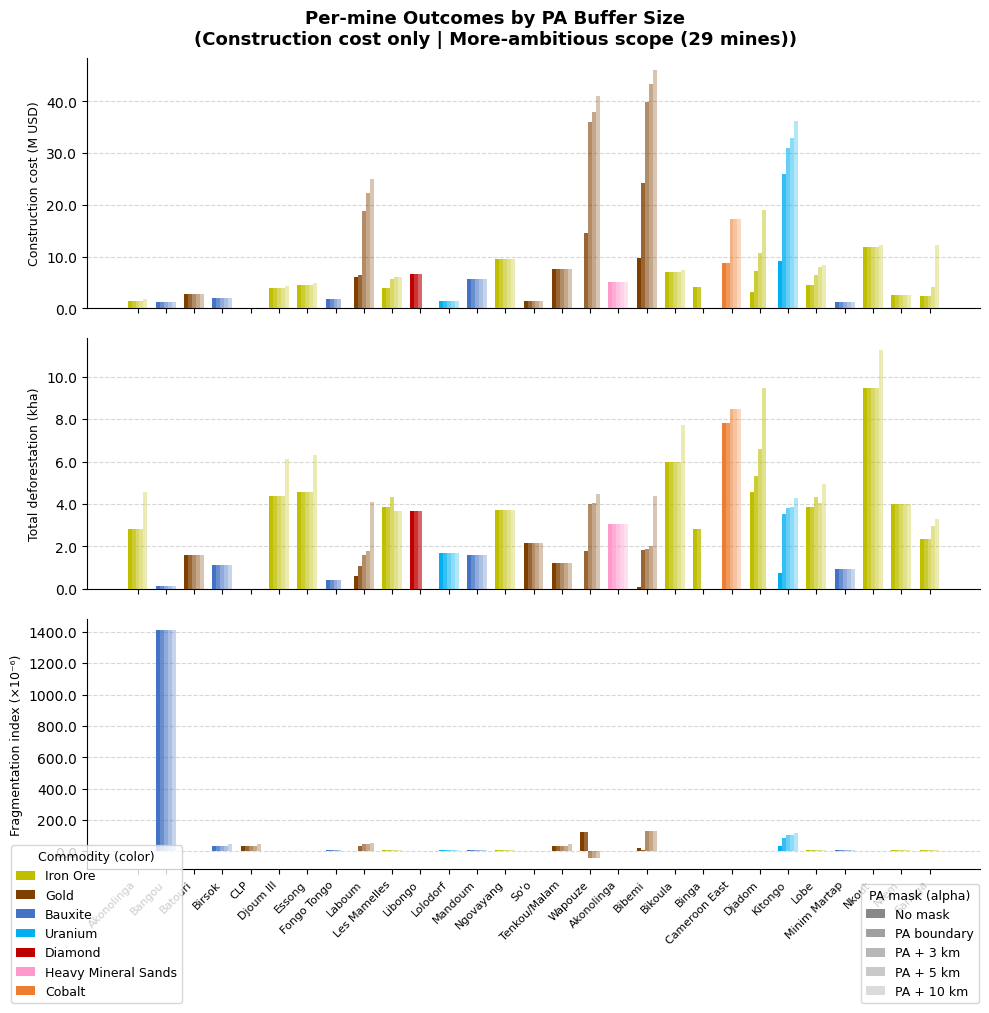

In [33]:
# ── Per-mine: cost / deforestation / fragmentation index by PA buffer ──────────
# Construction-only friction, late+early-stage.  Each grouped bar set = one mine.
# Bar colors = PA buffer level (MASK_COLORS).

FOCAL_MINING = 'late_and_early_stage'
FOCAL_FX     = 'construction_only'

# Scenario column stubs for the 5 PA masks
PA_STEMS = {
    m: f'{FOCAL_MINING}__kribi__{FOCAL_FX}__{m}__ds1'
    for m in MASK_ORDER
}

# Load wide tables and pull only the 5 construction_only columns
cost_w  = pd.read_csv(PER_MINE_DIR / 'per_mine_cost_usd.csv',          index_col='mine_id')
defor_w = pd.read_csv(PER_MINE_DIR / 'per_mine_defor_total_ha.csv',     index_col='mine_id')
frag_w  = pd.read_csv(PER_MINE_DIR / 'per_mine_fragmentation_index.csv',index_col='mine_id')

def extract(wide, stems):
    available = {m: s for m, s in stems.items() if s in wide.columns}
    df = wide[[v for v in available.values()]].copy()
    df.columns = list(available.keys())
    return df.apply(pd.to_numeric, errors='coerce')

cost_pa  = extract(cost_w,  PA_STEMS) / 1e6   # → M USD
defor_pa = extract(defor_w, PA_STEMS) / 1e3   # → kha
frag_pa  = extract(frag_w,  PA_STEMS) * 1e6   # → ×10⁻⁶

# Mine display order (preserve s5-load order) and names
mine_order = [m for m in MINE_IDS if m in cost_pa.index]
mine_labels = [mine_names.get(m, m) for m in mine_order]

cost_pa  = cost_pa.loc[mine_order]
defor_pa = defor_pa.loc[mine_order]
frag_pa  = frag_pa.loc[mine_order]

MASK_ALPHA = {
    'no_mask':                 1.00,
    'protected_areas':         0.80,
    'protected_areas_buf3km':  0.60,
    'protected_areas_buf5km':  0.45,
    'protected_areas_buf10km': 0.30,
}

# ── Plot ───────────────────────────────────────────────────────────────────────
n_mines   = len(mine_order)
n_masks   = len(MASK_ORDER)
bar_width = 0.14
x_pos     = np.arange(n_mines)
offsets   = np.linspace(-(n_masks - 1) / 2, (n_masks - 1) / 2, n_masks) * bar_width

PANEL_CFG = [
    (cost_pa,  'Construction cost (M USD)', 'Cost per mine by PA buffer'),
    (defor_pa, 'Total deforestation (kha)', 'Deforestation per mine by PA buffer'),
    (frag_pa,  'Fragmentation index (×10⁻⁶)', 'Fragmentation index per mine by PA buffer'),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle(
    f'Per-mine Outcomes by PA Buffer Size\n'
    f'(Construction cost only | {MINING_LABELS[FOCAL_MINING]})',
    fontsize=13, fontweight='bold',
)

for ax, (df, ylabel, title) in zip(axes, PANEL_CFG):
    for mask, offset in zip(MASK_ORDER, offsets):
        if mask not in df.columns:
            continue
        vals = df[mask].values.astype(float)
        bar_colors = [COMMODITY_COLORS.get(mine_commodity_map.get(mid, ''), '#aaaaaa')
                      for mid in mine_order]
        ax.bar(x_pos + offset, np.nan_to_num(vals, nan=0.0),
               width=bar_width,
               color=bar_colors, alpha=MASK_ALPHA[mask],
               edgecolor='none', zorder=3)

    # ax.set_title(title, fontsize=10, pad=4)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'${v:.0f}M' if 'USD' in ylabel else f'{v:.1f}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# x-axis mine names on bottom subplot only (sharex)
axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(mine_labels, rotation=45, ha='right', fontsize=8)

# Two legends: commodity (color) + PA mask (alpha)
comm_handles = commodity_legend_handles()
mask_handles = [mpatches.Patch(facecolor='#888888', alpha=MASK_ALPHA[m],
                               label=MASK_LABELS[m]) for m in MASK_ORDER]
fig.legend(handles=comm_handles, title='Commodity (color)', title_fontsize=9,
           fontsize=9, frameon=True,
           loc='lower left', bbox_to_anchor=(0.01, -0.02),
           ncol=1, handlelength=1.5)
fig.legend(handles=mask_handles, title='PA mask (alpha)', title_fontsize=9,
           fontsize=9, frameon=True,
           loc='lower right', bbox_to_anchor=(0.99, -0.02),
           ncol=1, handlelength=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, hspace=0.12)
plt.savefig(PM_FIGURES_DIR / 'fig5d_permine_pa_buffer.png', dpi=150, bbox_inches='tight')
plt.show()


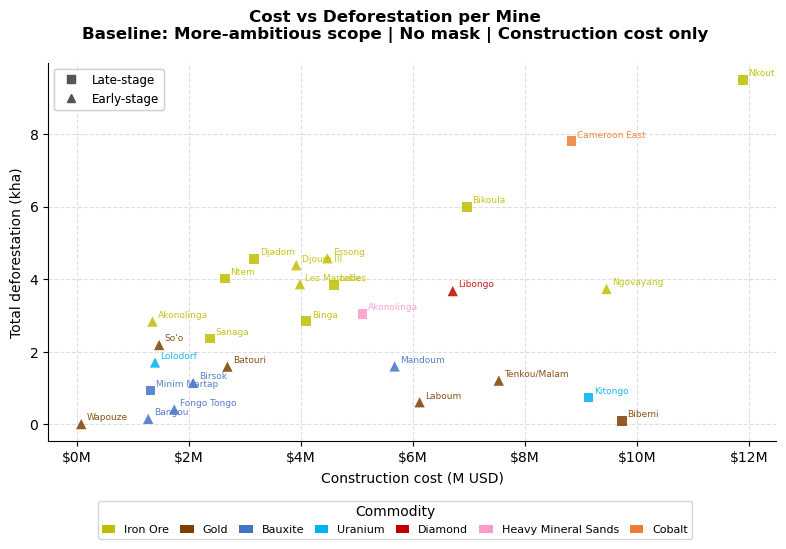

In [34]:
# ── Per-mine tradeoff: construction cost vs deforestation (baseline) ──────────
# Baseline: late+early stage, no mask, construction cost only.
# Color = commodity; shape = action type (upgrade vs new build).

td_base = long[
    (long['mining']   == 'late_and_early_stage') &
    (long['mask']     == 'no_mask') &
    (long['friction'] == 'construction_only') &
    (long['action'].isin(['upgrade', 'build']))
].copy()

STAGE_MARKER = {'Late-stage': 's', 'Early-stage': '^'}
STAGE_SIZE   = {'Late-stage': 50,  'Early-stage': 55}

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(
    'Cost vs Deforestation per Mine\n'
    'Baseline: More-ambitious scope | No mask | Construction cost only',
    fontsize=12, fontweight='bold'
)

for mid in td_base['mine_id'].unique():
    row   = td_base[td_base['mine_id'] == mid].iloc[0]
    color = COMMODITY_COLORS.get(mine_commodity_map.get(mid, ''), '#aaaaaa')
    stage = mine_stage_map.get(mid, 'Early-stage')
    mkr   = STAGE_MARKER.get(stage, '^')
    sz    = STAGE_SIZE.get(stage, 50)
    ax.scatter(row['cost_musd'], row['defor_total'] / 1000,
               color=color, marker=mkr, s=sz,
               alpha=0.85, edgecolors='none', zorder=3)
    ax.annotate(row['mine_name'],
                xy=(row['cost_musd'], row['defor_total'] / 1000),
                xytext=(4, 3), textcoords='offset points',
                fontsize=6.5, color=color, alpha=0.9)

ax.set_xlabel('Construction cost (M USD)', fontsize=10)
ax.set_ylabel('Total deforestation (kha)', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.4)

stage_handles = [
    mlines.Line2D([], [], color='#555555', marker='s', linestyle='None',
                  markersize=6, label='Late-stage'),
    mlines.Line2D([], [], color='#555555', marker='^', linestyle='None',
                  markersize=6, label='Early-stage'),
]
leg1 = ax.legend(handles=stage_handles, fontsize=8.5, loc='upper left', frameon=True)
ax.add_artist(leg1)
fig.legend(handles=commodity_legend_handles(), title='Commodity', fontsize=8,
           frameon=True, loc='lower center', bbox_to_anchor=(0.5, -0.09),
           ncol=20, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.savefig(PM_FIGURES_DIR / 'fig5e_permine_tradeoff_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


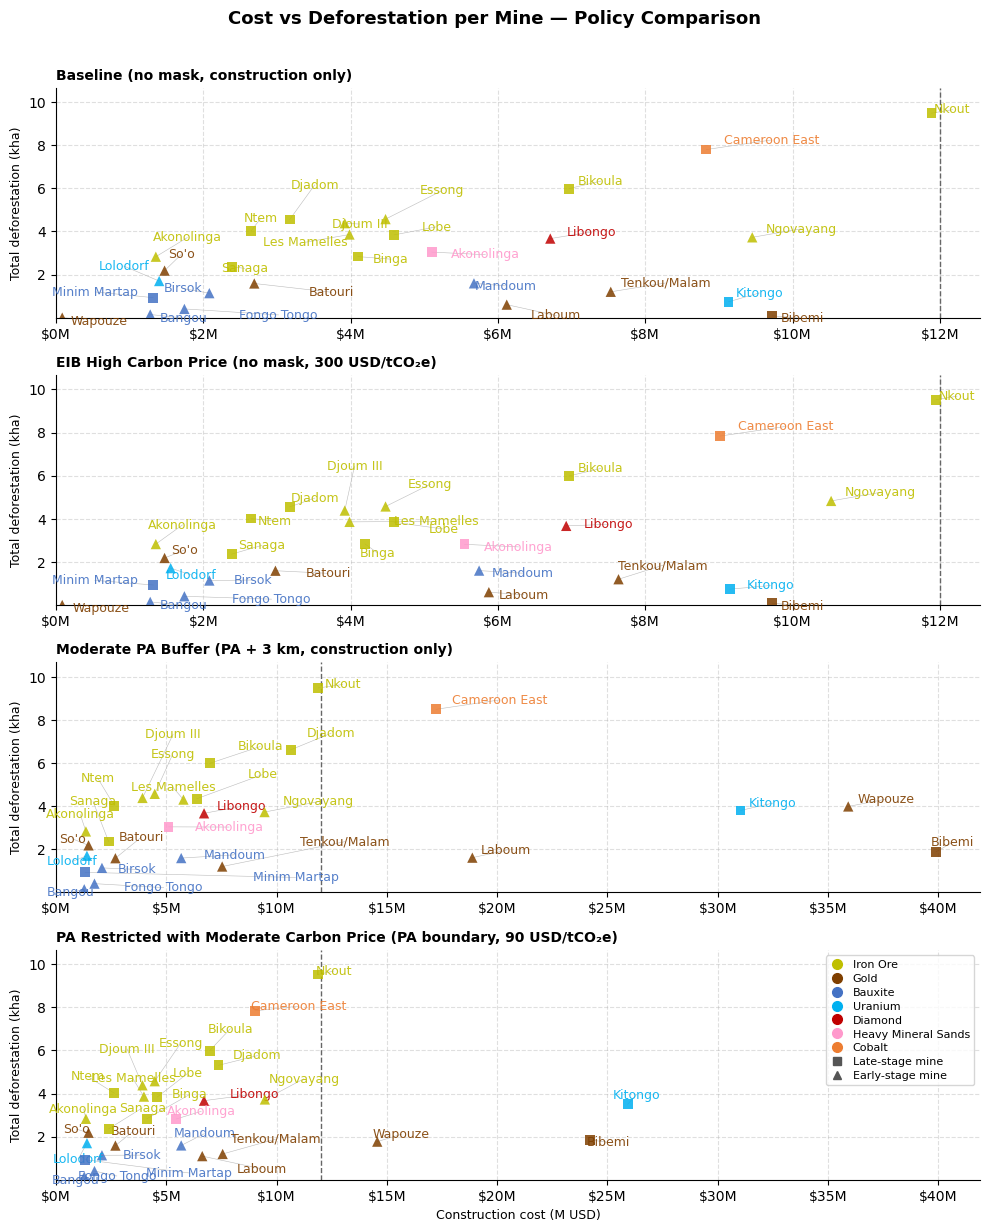

In [35]:
# ── Per-mine tradeoff: 4 scenarios (baseline / PA+3km / high carbon / PA+carbon90) ──
# Row 1: Baseline             — no mask,              construction only
# Row 2: EIB high carbon      — no mask,              carbon $300/tCO2e
# Row 3: Moderate PA buf      — PA + 3 km buffer,     construction only
# Row 4: PA + moderate carbon — PA boundary,          carbon $90/tCO2e

PANEL_SCENARIOS = [
    ('no_mask',                'construction_only', 'Baseline (no mask, construction only)'),
    ('no_mask',                'carbon_300',        'EIB High Carbon Price (no mask, 300 USD/tCO₂e)'),
    ('protected_areas_buf3km', 'construction_only', 'Moderate PA Buffer (PA + 3 km, construction only)'),
    ('protected_areas',        'carbon_high',       'PA Restricted with Moderate Carbon Price (PA boundary, 90 USD/tCO₂e)'),
]

from adjustText import adjust_text

# x limits: no-mask panels share one range; both PA panels share another
_td_nm = long[
    (long['mining']   == 'late_and_early_stage') &
    (long['mask']     == 'no_mask') &
    (long['friction'].isin(['construction_only', 'carbon_300'])) &
    (long['action'].isin(['upgrade', 'build']))
]
_td_pa = long[
    (long['mining']   == 'late_and_early_stage') &
    (long['mask'].isin(['protected_areas_buf3km', 'protected_areas'])) &
    (long['friction'].isin(['construction_only', 'carbon_high'])) &
    (long['action'].isin(['upgrade', 'build']))
]
# Y limits from all 4 displayed scenarios
_td_all4 = long[
    (long['mining'] == 'late_and_early_stage') &
    (
        ((long['mask'] == 'no_mask') & (long['friction'].isin(['construction_only', 'carbon_300']))) |
        ((long['mask'] == 'protected_areas_buf3km') & (long['friction'] == 'construction_only')) |
        ((long['mask'] == 'protected_areas') & (long['friction'] == 'carbon_high'))
    ) &
    (long['action'].isin(['upgrade', 'build']))
]
X_NM_MAX  = _td_nm['cost_musd'].max() * 1.05
X_NM_MIN  = 0
X_PA_MAX  = _td_pa['cost_musd'].max() * 1.05   # shared by both PA panels (3 & 4)
X_PA_MIN  = 0
Y_MAX4    = (_td_all4['defor_total'] / 1000).max() * 1.12
Y_MIN4    = max((_td_all4['defor_total'] / 1000).min() * 0.95, 0)

fig, axes = plt.subplots(4, 1, figsize=(10, 13))
fig.suptitle('Cost vs Deforestation per Mine — Policy Comparison',
             fontsize=13, fontweight='bold')

for ax, (mask, friction, panel_title) in zip(axes, PANEL_SCENARIOS):
    td = long[
        (long['mining']   == 'late_and_early_stage') &
        (long['mask']     == mask) &
        (long['friction'] == friction) &
        (long['action'].isin(['upgrade', 'build']))
    ].copy()

    ax.set_title(panel_title, fontsize=10, fontweight='bold', loc='left')

    _texts = []
    _pts   = []
    for mid in td['mine_id'].unique():
        row   = td[td['mine_id'] == mid].iloc[0]
        color = COMMODITY_COLORS.get(mine_commodity_map.get(mid, ''), '#aaaaaa')
        stage = mine_stage_map.get(mid, 'Early-stage')
        mkr   = STAGE_MARKER.get(stage, '^')
        sz    = STAGE_SIZE.get(stage, 50)
        px, py = row['cost_musd'], row['defor_total'] / 1000
        ax.scatter(px, py, color=color, marker=mkr, s=sz,
                   alpha=0.85, edgecolors='none', zorder=3)
        _texts.append(ax.text(px, py, row['mine_name'],
                              fontsize=9, color=color, alpha=0.9))
        _pts.append((px, py, color))
    adjust_text(_texts, ax=ax,
                expand=(1.1, 1.3),
                force_text=(0.3, 0.5),
                force_points=(0.2, 0.3))
    for txt, (px, py, color) in zip(_texts, _pts):
        tx, ty = txt.get_position()
        if (tx - px)**2 + (ty - py)**2 > 1e-6:
            ax.plot([px, tx], [py, ty], color='#bbbbbb', lw=0.4, zorder=1)

    ax.set_xlabel('Construction cost (M USD)' if ax is axes[-1] else '', fontsize=9)
    ax.set_ylabel('Total deforestation (kha)', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: '\$' + f'{v:.0f}' + 'M'))
    ax.set_xlim(X_NM_MIN, X_NM_MAX) if mask == 'no_mask' else ax.set_xlim(X_PA_MIN, X_PA_MAX)
    ax.set_ylim(Y_MIN4, Y_MAX4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axvline(12, color='#666666', linestyle='--', linewidth=1.0, zorder=2)

# Combined legend: commodity colors + stage shapes — scatter-style (Line2D not Patch)
comm_legend = [
    mlines.Line2D([], [], color=COMMODITY_COLORS[c], marker='o', linestyle='None',
                  markersize=7, label=c.title())
    for c in COMMODITY_ORDER if c in COMMODITY_COLORS
]
stage_legend = [
    mlines.Line2D([], [], color='#555555', marker='s', linestyle='None',
                  markersize=6, label='Late-stage mine'),
    mlines.Line2D([], [], color='#555555', marker='^', linestyle='None',
                  markersize=6, label='Early-stage mine'),
]
axes[3].legend(handles=comm_legend + stage_legend, fontsize=8, loc='upper right',
               frameon=True, handlelength=1.2, labelspacing=0.35, ncol=1)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, top=0.92, hspace=0.25)
plt.savefig(PM_FIGURES_DIR / 'fig5f_permine_tradeoff_4scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# ── Per-mine tradeoff: all friction × mask combinations ─────────────────────
# One figure per (mask, friction) combo showing all mines.
# Color = commodity; shape = development stage. Saved without display.

TRADEOFF_DIR = Path(r'D:\GitHub\_epa_thesis\strategic-road-planning\result-analysis\per-mine-trade-offs')
TRADEOFF_DIR.mkdir(exist_ok=True)

# Global x range for consistent axes across all plots
_td_all = long[
    (long['mining'] == 'late_and_early_stage') &
    (long['action'].isin(['upgrade', 'build']))
]
X_MAX = _td_all['cost_musd'].max() * 1.05
X_MIN = max(_td_all['cost_musd'].min() * 0.95, 0)
Y_MAX = (_td_all['defor_total'] / 1000).max() * 1.05
Y_MIN = max((_td_all['defor_total'] / 1000).min() * 0.95, 0)

for mask in MASK_ORDER:
    for friction in FRICTION_ORDER:
        td = long[
            (long['mining']   == 'late_and_early_stage') &
            (long['mask']     == mask) &
            (long['friction'] == friction) &
            (long['action'].isin(['upgrade', 'build']))
        ].copy()
        if td.empty:
            continue

        mask_label = MASK_LABELS[mask]
        fric_label = FRICTION_LABELS.get(friction, friction).replace('\n', ' ')

        fig, ax = plt.subplots(figsize=(12, 5))
        fig.suptitle(
            'Cost vs Deforestation per Mine\n'
            f'More-ambitious scope  |  {mask_label}  |  {fric_label}',
            fontsize=10, fontweight='bold'
        )

        for mid in td['mine_id'].unique():
            row   = td[td['mine_id'] == mid].iloc[0]
            color = COMMODITY_COLORS.get(mine_commodity_map.get(mid, ''), '#aaaaaa')
            stage = mine_stage_map.get(mid, 'Early-stage')
            mkr   = STAGE_MARKER.get(stage, '^')
            sz    = STAGE_SIZE.get(stage, 50)
            ax.scatter(row['cost_musd'], row['defor_total'] / 1000,
                       color=color, marker=mkr, s=sz,
                       alpha=0.85, edgecolors='none', zorder=3)
            ax.annotate(row['mine_name'],
                        xy=(row['cost_musd'], row['defor_total'] / 1000),
                        xytext=(4, 3), textcoords='offset points',
                        fontsize=6.5, color=color, alpha=0.9)

        ax.set_xlabel('Construction cost (M USD)', fontsize=10)
        ax.set_ylabel('Total deforestation (kha)', fontsize=10)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)

        leg1 = ax.legend(handles=stage_handles, fontsize=8.5, loc='upper left', frameon=True)
        ax.add_artist(leg1)
        fig.legend(handles=commodity_legend_handles(), title='Commodity', fontsize=8,
                   frameon=True, loc='lower center', bbox_to_anchor=(0.5, -0.09),
                   ncol=20, handlelength=1.2, columnspacing=1.0)

        plt.tight_layout()
        _fric_fname = friction.replace('carbon_low', 'carbon_5')\
                               .replace('carbon_central', 'carbon_40')\
                               .replace('carbon_high', 'carbon_90')
        fname = f'tradeoff__{mask}__{_fric_fname}.png'
        plt.savefig(TRADEOFF_DIR / fname, dpi=150, bbox_inches='tight')
        plt.close()

print(f'Saved {len(MASK_ORDER) * len(FRICTION_ORDER)} tradeoff plots to {TRADEOFF_DIR}')


Saved 40 tradeoff plots to D:\GitHub\_epa_thesis\strategic-road-planning\result-analysis\per-mine-trade-offs


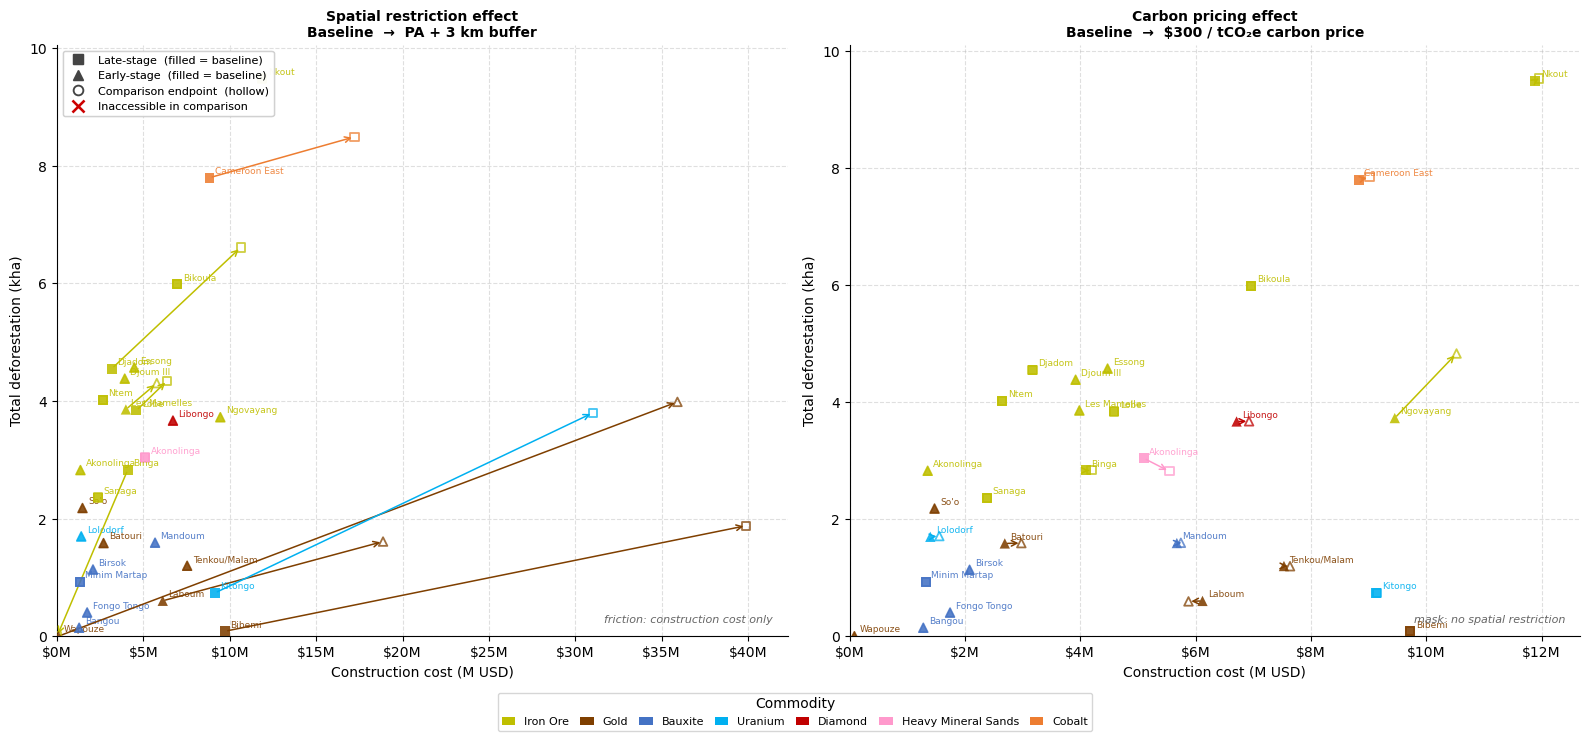

Saved: fig_movement_spatial_vs_carbon.png


In [37]:
# ── Movement visualization: per-mine tradeoff shift across scenarios ──────────
# Two side-by-side scatters. Each mine is an arrow from its baseline position
# (construction only, no mask) to a comparison scenario endpoint.
#   Left:  baseline → PA + 3 km buffer      (spatial restriction effect)
#   Right: baseline → $300 / tCO₂e          (carbon pricing null result)
#
# ● / ▲ filled  = baseline position (no mask, construction cost only)
# ○ / △ hollow  = comparison scenario endpoint
#   →           = direction of change
# ×  red        = mine becomes inaccessible in comparison scenario

def _sc(friction, mask):
    """Single-scenario slice of long, indexed by mine_id."""
    return long[
        (long['mining']   == 'late_and_early_stage') &
        (long['friction'] == friction) &
        (long['mask']     == mask)
    ].set_index('mine_id')

_base = _sc('construction_only', 'no_mask')
_pa3  = _sc('construction_only', 'protected_areas_buf3km')
_c300 = _sc('carbon_300',        'no_mask')


def _group_bounds(sc1, sc2):
    """Axis limits from the union of two scenario views."""
    xs = pd.concat([sc1['cost_musd'], sc2['cost_musd']]).dropna()
    ys = pd.concat([sc1['defor_total'], sc2['defor_total']]).dropna() / 1000
    return xs.max() * 1.06, ys.max() * 1.06

_XMAX_L, _YMAX_L = _group_bounds(_base, _pa3)   # left:  baseline + PA+3km
_XMAX_R, _YMAX_R = _group_bounds(_base, _c300)   # right: baseline + carbon_300


def _draw_mv(ax, base_sc, comp_sc, title, footnote, xmax, ymax):
    """Draw baseline (filled) + comparison endpoint (hollow) + arrows on ax."""
    active = base_sc[base_sc['action'].isin(['upgrade', 'build'])]

    for mid, row_b in active.iterrows():
        color = commodity_color(mid)
        stage = mine_stage_map.get(mid, 'Early-stage')
        mkr   = STAGE_MARKER.get(stage, '^')
        sz    = STAGE_SIZE.get(stage, 50)
        x0    = row_b['cost_musd']
        y0    = row_b['defor_total'] / 1000
        if pd.isna(x0) or pd.isna(y0):
            continue

        # -- Comparison scenario -----------------------------------------------
        if mid in comp_sc.index:
            row_c    = comp_sc.loc[mid]
            action_c = row_c['action']

            if action_c == 'inaccessible':
                ax.scatter(x0, y0, s=sz * 1.6, marker='x',
                           color='#cc0000', linewidths=1.8, zorder=6)
            elif action_c in ('upgrade', 'build', 'no_action'):
                x1 = row_c['cost_musd']
                y1 = row_c['defor_total'] / 1000
                if pd.notna(x1) and pd.notna(y1):
                    ax.scatter(x1, y1, s=sz * 0.7, marker=mkr,
                               facecolors='none', edgecolors=color,
                               linewidths=1.3, alpha=0.75, zorder=3)
                    dx_norm = abs(x1 - x0) / xmax
                    dy_norm = abs(y1 - y0) / ymax
                    if math.hypot(dx_norm, dy_norm) > 0.004:
                        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                                    arrowprops=dict(
                                        arrowstyle='->', color=color,
                                        lw=1.1, mutation_scale=10,
                                    ))

        # -- Baseline dot (filled, drawn last so it sits on top) ---------------
        ax.scatter(x0, y0, s=sz, marker=mkr, color=color,
                   alpha=0.88, edgecolors='none', zorder=4)
        ax.annotate(row_b['mine_name'],
                    xy=(x0, y0), xytext=(4, 3), textcoords='offset points',
                    fontsize=6.5, color=color, alpha=0.9)

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel('Construction cost (M USD)', fontsize=10)
    ax.set_ylabel('Total deforestation (kha)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.text(0.98, 0.02, footnote, transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', color='#666', style='italic')


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_draw_mv(axes[0], _base, _pa3,
         'Spatial restriction effect\nBaseline  →  PA + 3 km buffer',
         'friction: construction cost only',
         xmax=_XMAX_L, ymax=_YMAX_L)
_draw_mv(axes[1], _base, _c300,
         'Carbon pricing effect\nBaseline  →  $300 / tCO₂e carbon price',
         'mask: no spatial restriction',
         xmax=_XMAX_R, ymax=_YMAX_R)

# ── Legends ───────────────────────────────────────────────────────────────────
_mv_handles = [
    mlines.Line2D([], [], marker='s', color='#444', linestyle='none',
                  markersize=7, label='Late-stage  (filled = baseline)'),
    mlines.Line2D([], [], marker='^', color='#444', linestyle='none',
                  markersize=7, label='Early-stage  (filled = baseline)'),
    mlines.Line2D([], [], marker='o', color='#444', linestyle='none',
                  markersize=7, mfc='none', mew=1.3, label='Comparison endpoint  (hollow)'),
    mlines.Line2D([], [], marker='x', color='#cc0000', linestyle='none',
                  markersize=8, markeredgewidth=1.8, label='Inaccessible in comparison'),
]
leg1 = axes[0].legend(handles=_mv_handles, fontsize=8, loc='upper left', frameon=True)
axes[0].add_artist(leg1)

fig.legend(handles=commodity_legend_handles(), title='Commodity', fontsize=8,
           frameon=True, loc='lower center', bbox_to_anchor=(0.5, -0.06),
           ncol=7, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.savefig(PM_FIGURES_DIR / 'fig_movement_spatial_vs_carbon.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_movement_spatial_vs_carbon.png')


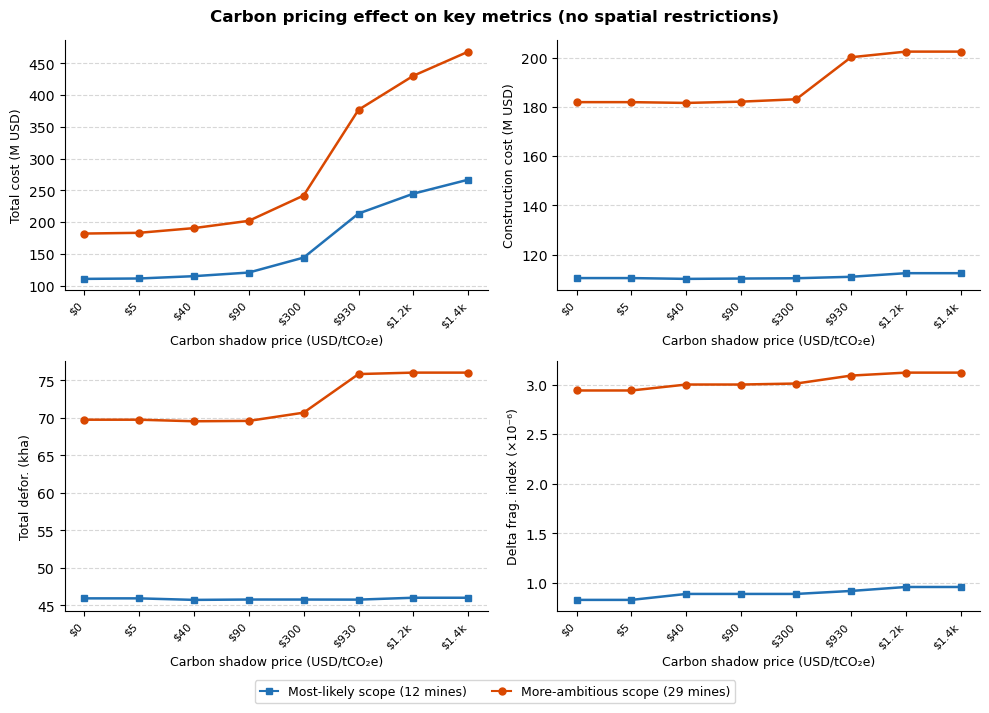

In [38]:
# ── No-mask: 4 metrics vs carbon shadow price ─────────────────────────────────
# Lines = mining scope; x = carbon price. Shows how carbon pricing affects
# total vs. construction cost, deforestation, and fragmentation without any
# spatial restrictions.

df_nm = data[data['mask'] == 'no_mask'].copy()

MINING_COLORS_NM = {
    'late_stage':           '#2171b5',
    'late_and_early_stage': '#d94801',
}
MINING_MARKERS_NM = {
    'late_stage':           's',
    'late_and_early_stage': 'o',
}

METRICS_NM = [
    ('total_cost_musd',        'Total cost (M USD)'),
    ('construction_cost_musd', 'Construction cost (M USD)'),
    ('defor_action_kha',       'Total defor. (kha)'),
    ('delta_fi_e6',            'Delta frag. index (×10⁻⁶)'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Carbon pricing effect on key metrics (no spatial restrictions)',
             fontsize=12, fontweight='bold')

for ax, (col, ylabel) in zip(axes.flatten(), METRICS_NM):
    for mining in MINING_ORDER:
        sub = df_nm[df_nm['mining'] == mining].sort_values('friction_x')
        ax.plot(sub['friction_x'], sub[col],
                color=MINING_COLORS_NM[mining],
                marker=MINING_MARKERS_NM[mining],
                markersize=5, linewidth=1.8, label=MINING_LABELS[mining])
    ax.set_xticks(FX)
    ax.set_xticklabels(['$0', '$5', '$40', '$90', '$300', '$930', '$1.2k', '$1.4k'],
                       fontsize=8, rotation=45, ha='right')
    ax.set_xlabel('Carbon shadow price (USD/tCO₂e)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

handles = [mlines.Line2D([], [], color=MINING_COLORS_NM[m],
                          marker=MINING_MARKERS_NM[m], markersize=5,
                          label=MINING_LABELS[m]) for m in MINING_ORDER]
fig.legend(handles=handles, fontsize=9, frameon=True,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=2, handlelength=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(FIGURES_DIR / 'fig5b_no_mask_carbon_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

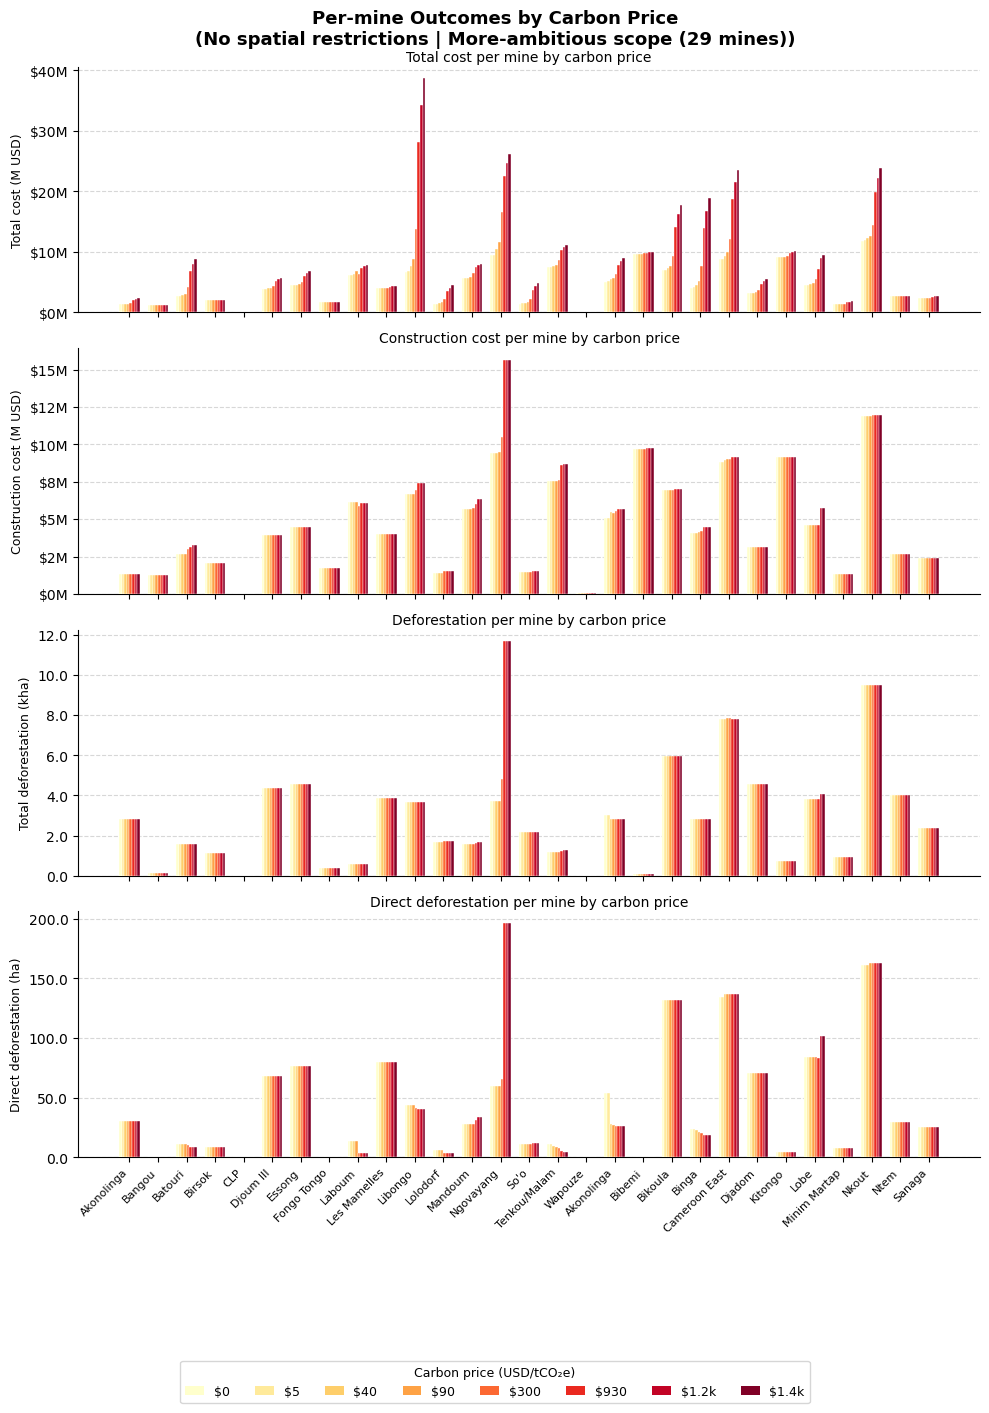

In [39]:
# ── No-mask: per-mine outcomes by carbon price (bar chart) ────────────────────
# Mirrors s5-permine-pa but x-axis = carbon price per mine instead of PA buffer.
# Late+early scope, no mask.  Bar color = carbon price level.

total_cost_w = pd.read_csv(PER_MINE_DIR / 'per_mine_total_cost_usd.csv', index_col='mine_id')

SCOPE_NM = 'late_and_early_stage'
NM_STEMS = {f: f'{SCOPE_NM}__kribi__{f}__no_mask__ds1' for f in FRICTION_ORDER}

def extract_nm(wide, stems):
    avail = {f: s for f, s in stems.items() if s in wide.columns}
    df = wide[[v for v in avail.values()]].copy()
    df.columns = list(avail.keys())
    return df.apply(pd.to_numeric, errors='coerce')

total_cost_nm = extract_nm(total_cost_w, NM_STEMS) / 1e6   # → M USD
defor_nm      = extract_nm(total_d_wide, NM_STEMS) / 1e3   # → kha
defor_dir_nm  = extract_nm(direct_wide,  NM_STEMS)          # ha

mine_order_nm  = [m for m in MINE_IDS if m in total_cost_nm.index]
mine_labels_nm = [mine_names.get(m, m) for m in mine_order_nm]
total_cost_nm  = total_cost_nm.loc[mine_order_nm]
defor_nm       = defor_nm.loc[mine_order_nm]
defor_dir_nm   = defor_dir_nm.loc[mine_order_nm]

# Colors: sequential YlOrRd (low carbon = light, high = dark)
_cmap = plt.cm.YlOrRd
FRICTION_COLORS_NM = {
    f: _cmap(i / (len(FRICTION_ORDER) - 1))
    for i, f in enumerate(FRICTION_ORDER)
}
FRICTION_LABELS_NM = {
    'construction_only': '$0',
    'carbon_low':        '$5',
    'carbon_central':    '$40',
    'carbon_high':       '$90',
    'carbon_300':        '$300',
    'carbon_930':        '$930',
    'carbon_1200':       '$1.2k',
    'carbon_1400':       '$1.4k',
}

n_mines  = len(mine_order_nm)
n_frict  = len(FRICTION_ORDER)
bar_w    = 0.09
x_pos    = np.arange(n_mines)
offsets  = np.linspace(-(n_frict - 1) / 2, (n_frict - 1) / 2, n_frict) * bar_w

const_cost_nm = extract_nm(cost_wide, NM_STEMS) / 1e6   # -> M USD
const_cost_nm = const_cost_nm.loc[mine_order_nm]

PANEL_CFG_NM = [
    (total_cost_nm, 'Total cost (M USD)',        'Total cost per mine by carbon price'),
    (const_cost_nm, 'Construction cost (M USD)', 'Construction cost per mine by carbon price'),
    (defor_nm,      'Total deforestation (kha)',  'Deforestation per mine by carbon price'),
    (defor_dir_nm,  'Direct deforestation (ha)',  'Direct deforestation per mine by carbon price'),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
fig.suptitle(
    f'Per-mine Outcomes by Carbon Price\n'
    f'(No spatial restrictions | {MINING_LABELS[SCOPE_NM]})',
    fontsize=13, fontweight='bold',
)

for ax, (df, ylabel, title) in zip(axes, PANEL_CFG_NM):
    for friction, offset in zip(FRICTION_ORDER, offsets):
        if friction not in df.columns:
            continue
        vals = df[friction].values.astype(float)
        ax.bar(x_pos + offset, np.nan_to_num(vals, nan=0.0),
               width=bar_w,
               color=FRICTION_COLORS_NM[friction], edgecolor='white',
               linewidth=0.3, zorder=3, label=FRICTION_LABELS_NM[friction])

    ax.set_title(title, fontsize=10, pad=4)
    ax.set_ylabel(ylabel, fontsize=9)
    _yl = ylabel
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _, yl=_yl: f'${v:.0f}M' if 'USD' in yl else f'{v:.1f}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(mine_labels_nm, rotation=45, ha='right', fontsize=8)

handles = [mpatches.Patch(facecolor=FRICTION_COLORS_NM[f],
                           label=FRICTION_LABELS_NM[f])
           for f in FRICTION_ORDER]
fig.legend(handles=handles, title='Carbon price (USD/tCO\u2082e)', title_fontsize=9,
           fontsize=9, frameon=True,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=8, handlelength=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.savefig(FIGURES_DIR / 'fig5c_permine_carbon_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
# # ── Per-mine heatmap: construction cost & deforestation ───────────────────────
# # For each mine: 2-panel heatmap, rows = carbon price, cols = spatial restriction.
# # Left = construction cost (M USD);  right = total deforestation (ha).
# # Saves one PNG per mine; also displays inline.

# HEATMAP_DIR = PM_FIGURES_DIR / 'per_mine_heatmaps'
# HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

# SCOPE_HM       = 'late_and_early_stage'
# FX_TICK_LABELS = ['$0', '$5', '$40', '$90', '$300', '$930', '$1.2k', '$1.4k']

# def build_hm_matrix(df, mine_id, scale=1.0):
#     mat = np.full((len(FRICTION_ORDER), len(MASK_ORDER)), np.nan)
#     for i, f in enumerate(FRICTION_ORDER):
#         for j, m in enumerate(MASK_ORDER):
#             stem = f'{SCOPE_HM}__kribi__{f}__{m}__ds1'
#             if stem in df.columns and mine_id in df.index:
#                 v = df.loc[mine_id, stem]
#                 if pd.notna(v):
#                     mat[i, j] = float(v) / scale
#     return mat

# def annotate_hm(ax, im, mat):
#     for r in range(mat.shape[0]):
#         for cc in range(mat.shape[1]):
#             v = mat[r, cc]
#             if np.isnan(v):
#                 continue
#             rgba = im.cmap(im.norm(v))
#             bright = rgba[0]*0.299 + rgba[1]*0.587 + rgba[2]*0.114
#             tc = 'white' if bright < 0.55 else '#333333'
#             fmt = f'{v:.1f}' if abs(v) < 100 else f'{v:.0f}'
#             ax.text(cc, r, fmt, ha='center', va='center',
#                     fontsize=6.5, color=tc, fontweight='bold')

# n_saved = 0
# for mine_id in MINE_IDS:
#     cost_mat  = build_hm_matrix(cost_wide,    mine_id, scale=1e6)
#     defor_mat = build_hm_matrix(total_d_wide, mine_id, scale=1.0)
#     if np.all(np.isnan(cost_mat)):
#         continue

#     mine_label = mine_names.get(mine_id, mine_id)
#     fig, axes  = plt.subplots(1, 2, figsize=(10, 4))
#     fig.suptitle(f'{mine_label}  ({mine_id})', fontsize=11, fontweight='bold')

#     PANELS_HM = [
#         (axes[0], cost_mat,  'Construction cost (M USD)', 'YlOrRd'),
#         (axes[1], defor_mat, 'Total deforestation (ha)',  'YlOrRd'),
#     ]
#     for ax, mat, title, cmap in PANELS_HM:
#         norm = mcolors.Normalize(vmin=np.nanmin(mat), vmax=np.nanmax(mat))
#         im   = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm,
#                          interpolation='nearest')
#         annotate_hm(ax, im, mat)

#         ax.set_xticks(range(len(MASK_ORDER)))
#         ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER],
#                            rotation=30, ha='right', fontsize=7.5)
#         ax.set_yticks(range(len(FRICTION_ORDER)))
#         ax.set_yticklabels(FX_TICK_LABELS, fontsize=8)
#         ax.set_xlabel('Spatial restriction', fontsize=8)
#         ax.set_ylabel('Carbon price (USD/tCO\u2082e)', fontsize=8)
#         ax.set_title(title, fontsize=9, fontweight='bold')
#         plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

#     plt.tight_layout()
#     plt.savefig(HEATMAP_DIR / f'{mine_id}_heatmap.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     plt.close()
#     n_saved += 1

# print(f'Saved {n_saved} heatmaps to {HEATMAP_DIR}')


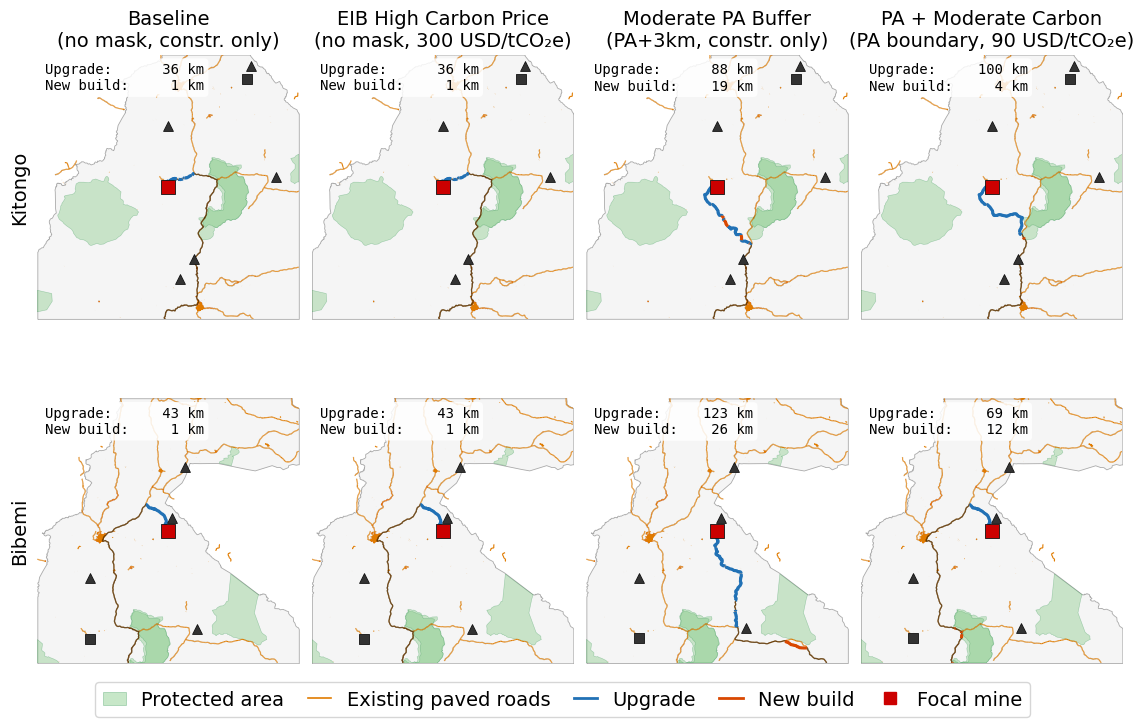

In [41]:
# ── Zoom-in route comparison — focal mines × 4 key scenarios ────────────────
# Rows = mines in FOCAL_MINES; Cols = 4 policy scenarios.

ZOOM_SCENARIOS = [
    ('no_mask',                'construction_only', 'Baseline\n(no mask, constr. only)'),
    ('no_mask',                'carbon_300',        'EIB High Carbon Price\n(no mask, 300 USD/tCO₂e)'),
    ('protected_areas_buf3km', 'construction_only', 'Moderate PA Buffer\n(PA+3km, constr. only)'),
    ('protected_areas',        'carbon_high',       'PA + Moderate Carbon\n(PA boundary, 90 USD/tCO₂e)'),
]

FOCAL_MINES  = ['Kitongo', 'Bibemi']   # ← edit this list
ZOOM_MINING  = 'late_and_early_stage'
zoom_pad     = 1.2   # degrees around each mine centroid

# Build mine_id lookup from action roads mine_name column
_id_lookup = {}
_ref_act = gpd.read_file(
    RESULTS_DIR / 'late_and_early_stage__kribi__construction_only__no_mask__ds1__action_roads.gpkg'
)
_id_lookup = _ref_act[['mine_id','mine_name']].drop_duplicates()\
                  .set_index('mine_name')['mine_id'].to_dict()

n_mines = len(FOCAL_MINES)
n_scen  = len(ZOOM_SCENARIOS)
fig, axes = plt.subplots(
    n_mines, n_scen,
    figsize=(3.5 * n_scen, 4 * n_mines),
    gridspec_kw={'wspace': 0.05, 'hspace': 0.00},
    squeeze=False,
)
# fig.suptitle('Route Comparison',
#              fontsize=18, fontweight='bold')

for row, mine_name in enumerate(FOCAL_MINES):
    mine_row = mines_all[mines_all['PROP_NAME'] == mine_name].iloc[0]
    focal_id = _id_lookup.get(mine_name)
    zx0 = mine_row['LONGITUDE'] - zoom_pad
    zx1 = mine_row['LONGITUDE'] + zoom_pad
    zy0 = mine_row['LATITUDE']  - zoom_pad
    zy1 = mine_row['LATITUDE']  + zoom_pad

    # Clip background layers once per mine
    _adm0_c = adm0.clip_by_rect(zx0, zy0, zx1, zy1)
    _pa_c   = pa_core.clip_by_rect(zx0, zy0, zx1, zy1)
    _rds_c  = paved_rds.clip_by_rect(zx0, zy0, zx1, zy1)
    _mz = mines_all[
        mines_all['LONGITUDE'].between(zx0, zx1) &
        mines_all['LATITUDE'].between(zy0, zy1)
    ]

    for col, (mask, fric, title) in enumerate(ZOOM_SCENARIOS):
        ax = axes[row, col]
        stem   = f'{ZOOM_MINING}__kribi__{fric}__{mask}__ds1'
        act_fp = RESULTS_DIR / f'{stem}__action_roads.gpkg'

        # Background
        if not _adm0_c.empty:
            _adm0_c.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa',
                         linewidth=0.6, zorder=0)
        if not _pa_c.empty:
            _pa_c.plot(ax=ax, color='#74c476', alpha=0.35,
                       edgecolor='#238b45', linewidth=0.4, zorder=1)
        if not _rds_c.empty:
            _rds_c.plot(ax=ax, color='#e07b00', linewidth=0.8, zorder=2)

        # Generated route for focal mine only (black)
        _pth_fp = PATHS_FINAL_DIR / f'{stem}.gpkg'
        if _pth_fp.exists() and focal_id:
            _pth_all = gpd.read_file(_pth_fp)
            if 'mine_id' in _pth_all.columns:
                _pth_all = _pth_all[_pth_all['mine_id'] == focal_id]
            _pth_c = _pth_all.clip_by_rect(zx0, zy0, zx1, zy1)
            if not _pth_c.empty:
                _pth_c.plot(ax=ax, color='#000000', linewidth=0.9,
                            alpha=0.5, zorder=4)

        # Action roads filtered to focal mine
        if act_fp.exists() and focal_id:
            act = gpd.read_file(act_fp)
            act = act[act['mine_id'] == focal_id]
            upgrades_z   = act[act['action_needed'] == 'upgrade']
            new_builds_z = act[act['action_needed'] == 'build']
            if not upgrades_z.empty:
                upgrades_z.plot(ax=ax, color='#2171b5', linewidth=2.2, zorder=5)
            if not new_builds_z.empty:
                new_builds_z.plot(ax=ax, color='#d94801', linewidth=2.2, zorder=5)

        # km labels — top-left of each subplot
        _upg_km = upgrades_z.to_crs('EPSG:32632').length.sum() / 1000 \
            if act_fp.exists() and focal_id and not upgrades_z.empty else 0
        _bld_km = new_builds_z.to_crs('EPSG:32632').length.sum() / 1000 \
            if act_fp.exists() and focal_id and not new_builds_z.empty else 0
        _km_txt = f'Upgrade:   {_upg_km:5.0f} km\nNew build: {_bld_km:5.0f} km'
        ax.text(
            0.03, 0.97, _km_txt,
            transform=ax.transAxes, va='top', ha='left',
            fontsize=10, family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.85, edgecolor='none'),
            zorder=10,
        )

        # Mines in zoom area
        for _, m in _mz.iterrows():
            _mk  = 's' if m['DEV_STAGE_AGGREGATED_SNL'] == 'Late-stage' else '^'
            _col = '#cc0000' if m['PROP_NAME'] == mine_name else '#333333'
            _sz  = 110 if m['PROP_NAME'] == mine_name else 50
            ax.scatter(m['LONGITUDE'], m['LATITUDE'], marker=_mk,
                       s=_sz, color=_col,
                       edgecolors='#111111', linewidths=0.6, zorder=6)

        ax.set_xlim(zx0, zx1)
        ax.set_ylim(zy0, zy1)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Column title on top row only; row label on left col only
        if row == 0:
            ax.set_title(title, fontsize=14, )
        if col == 0:
            ax.set_ylabel(mine_name, fontsize=14, labelpad=6)

# Shared legend below
_leg = [
    mpatches.Patch(facecolor='#74c476', alpha=0.4, edgecolor='#238b45',
                   linewidth=0.5, label='Protected area'),
    mlines.Line2D([], [], color='#e07b00', linewidth=1.2, label='Existing paved roads'),
    mlines.Line2D([], [], color='#2171b5', linewidth=2.0, label='Upgrade'),
    mlines.Line2D([], [], color='#d94801', linewidth=2.0, label='New build'),
    mlines.Line2D([], [], color='#cc0000', marker='s', markersize=8,
                  linestyle='None', label='Focal mine'),
    # mlines.Line2D([], [], color='#333333', marker='s', markersize=7,
    #               linestyle='None', label='Other mine'),
]
fig.legend(handles=_leg, loc='lower center', bbox_to_anchor=(0.5, 0.05),
           ncol=6, fontsize=14, frameon=True,
           handlelength=1.2, columnspacing=1.2)

plt.subplots_adjust(bottom=0.08, top=0.94)
_fname = 'fig_zoom__' + '_'.join(FOCAL_MINES).replace(' ', '-') + '.png'
plt.savefig(FIGURES_DIR / _fname, dpi=150, bbox_inches='tight')
plt.show()
